# 사출성형 공정 기반 EDA와 파생변수 탐색
**질문:** 불량은 정상과 비교할 때 충전·사출 공통·보압 전환·보압 관련 관측값에서 어떻게 다른가?

CN7과 RG3를 분리한다. 원본 보존, 정확 입력 패턴 관점, 문서 근거와 추론의 분리를 원칙으로 한다. 예측 모델 및 pseudo-labeling은 수행하지 않는다. 그래프는 폰트 호환성을 위해 영문, 해석은 한국어로 제공한다. 아래 첫 코드 셀의 두 경로를 수정하면 ZIP 또는 CSV 폴더에서 재실행할 수 있다.

필요 패키지: `numpy pandas scipy matplotlib seaborn pymupdf ipython` (Jupyter 실행에는 `ipykernel` 추가). 예: `%pip install numpy pandas scipy matplotlib seaborn pymupdf ipykernel`. 패키지 설치는 분석 셀에서 자동 수행하지 않는다. 원본 4개 CSV는 ZIP에서 읽으며 노트북에 원시 데이터를 재저장하지 않는다.

박사님 의견: 정상과 비정상의 레코드가 동일한 경우 정상 레코드 삭제 -> 보수적으로 설정

In [1]:
import os

print(os.getcwd())
os.chdir("..")
print(os.getcwd())

c:\workspace\26KAMP\EDA
c:\workspace\26KAMP


In [2]:
from pathlib import Path
DATA_PATH = Path("./data/origin/")
GUIDE_PATH = Path("./data/origin//04. Guidebook_Molding-압축됨.pdf")
SEED = 20260922
REPEATS = 12  # 계산 예산: 6회와 12회 요약을 비교하며 수렴을 확정하지 않는다.
IQR_COEFFICIENTS = [1.5, 3.0, 4.5]  # 탐색 민감도 범위; 규격/불량 판정값이 아니다.


In [3]:
import io, zipfile, hashlib, platform, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fitz
from scipy.stats import ks_2samp, spearmanr, skew
from scipy.spatial.distance import cdist
from IPython.display import display, Markdown, Image


rng = np.random.default_rng(SEED)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 16)
plt.rcParams.update({'font.family':'DejaVu Sans','figure.dpi':110})
COLORS = {0:'#2471A3', 1:'#D35400'}
display(pd.DataFrame({'package':['python','numpy','pandas','scipy','matplotlib','seaborn','PyMuPDF'],
'version':[platform.python_version()]+[importlib.metadata.version(x) for x in ['numpy','pandas','scipy','matplotlib','seaborn','PyMuPDF']]}))
def say(s): display(Markdown(s))
def ecdf(ax, values, label, color):
    a=np.sort(pd.Series(values).dropna().to_numpy()); ax.step(a,np.arange(1,len(a)+1)/max(len(a),1),where='post',label=f'{label} (n={len(a)})',color=color)
def finish(ax,title,x,y):
    ax.set(title=title,xlabel=x,ylabel=y); ax.legend(fontsize=7)

def safe_corr(a,b):
    a=np.asarray(a);b=np.asarray(b)
    return float(spearmanr(a,b).statistic) if np.unique(a).size>1 and np.unique(b).size>1 else np.nan
def finite_median(a):
    a=np.asarray(a,float);a=a[np.isfinite(a)]
    return float(np.median(a)) if len(a) else np.nan


,package,version
0,python,3.12.7
1,numpy,2.5.3
2,pandas,3.0.6
3,scipy,1.18.1
4,matplotlib,3.11.2
5,seaborn,0.13.2
6,PyMuPDF,1.28.2


## 1. 가이드북 확인과 관측 범위
**방법·근거:** PDF의 물리 페이지와 인쇄 쪽수는 다르다. 이 파일에서는 물리 페이지=인쇄 쪽수+1이다. 아래에서 해당 페이지의 본문과 코드 이미지를 직접 출력한다. 다른 PDF로 교체할 경우 페이지 대응을 확인해야 한다. 공정 존재가 해당 공정을 완전히 관측한다는 뜻은 아니다.

**가이드북 인쇄 5쪽 (PDF 6쪽)**

1. 분석 개요
1.1 분석 배경
1) 공정(설비) 정의 및 특징
● 사출성형 정의
- 사출성형이란 플라스틱 성형법 중의 한 방법으로서, 열가소성 수지를 가열해서 유동 
상태로 되었을 때 금형의 공동부(Cavity, 이하 ‘캐비티‘)에 가압 주입하여 금형 내에서 
냉각시킴으로써, 금형의 공동부에 상당하는 성형품을 만드는 방법이다.
● 사출성형 특징
① 성형 사이클이 짧고, 성형 능률이 좋다. (대량 생산 가능) 
② 광범위한 수지의 성형 (열가소성 수지, 열경화성 수지) 
③ 자동제어화가 가능하다. 
④ 현재 대형 성형품의 성형 가능하다. 
⑤ 정밀도가 높아 복잡한 모양 가능하다.
● 사출성형 원리
[그림 1] 살균기 데이터 스크린샷
- 사출성형 과정은 크게 구분하여 충전 단계, 가압 단계, 보압 단계의 3단계로 나눌 수 
있다. 
「사출성형기 AI 데이터셋」 분석실습 가이드북
05
분석 실습
2



**가이드북 인쇄 6쪽 (PDF 7쪽)**

「사출성형기 AI 데이터셋」 분석실습 가이드북
06
① 충전 단계 (Filling Phase)
◦ 사출기의 스크류가 전진함에 따라 처음에는 금형의 캐비티 내로 수지가 유입된다. 
이 단계를 충전 단계라고 하며 수지가 금형의 캐비티에 채워질 때까지 지속된다. 
② 가압 단계 (Pressurisation Phase)
◦ 스크류가 더욱 전진하여 금형의 캐비티에 압력이 가해지는 단계를 가압 단계라고 
한다. 캐비티가 충전되면 속도는 감소되며 계속 천천히 전진한다. 이것은 수지가 압
축성의 재료이기 때문이며, 이로써 충전 단계에서 수지를 추가로 15%만큼 더 캐비
티 내로 밀어 넣을 수 있다. 수지의 압축성은 노즐을 막은 후 스크류를 전진시키면 
확인할 수 있다. 스크류는 압력이 가해질 때 앞으로 신속히 전진하지만, 압력을 제
거하면 스프링 백(Spring Back) 현상으로 인해 뒤로 밀려난다. 
③ 보압 단계 (Compensating Phase)
◦ 가압 단계 이후에도 스크류는 완전히 정지하지 않고 한동안 천천히 계속해서 전진
한다. 일반적으로 수지는 용융 상태에서 고체 상태로 될 때 약 25%의 체적 변화가 
생긴다. 이와 같은 현상은 심한 요철이 생긴다. 이때 캐비티와 성형품의 체적 차이
는 상기의 체적 변화 때문이다. 이 단계를 보압 단계라고 하며 상기와 같은 체적 차
이를 보상하기 위한 것이다. 성형품의 체적 변화는 일반적으로 25%인데 비하여, 압
축 단계에서는 15%만을 압축하므로 항상 보압 단계가 필요하다.
- 아래의 8단계를 사출성형 공정 1사이클이라고 하는데, [그림 2]는 1사이클 시간 동안 
이루어지는 과정을 도식적으로 표현한 것이다. 열가소성 수지의 비결정성 수지와 결정
성 수지를 게이트 온도와 사출압력으로 표시했다. 
① ‌재료에 흡입된 수분을 제거하기 위해 재료를 1차 건조시킨 다음 사출성형기에 부착된 재
료 받이실인 ‘호퍼’에 채워지고, 사출기의 실린더 내에 있는 사출스크루의 회전에 의해 원
재료는 호퍼의 밑 부분에 있는 것부터 

**가이드북 인쇄 7쪽 (PDF 8쪽)**

...

**가이드북 인쇄 20쪽 (PDF 21쪽)**

「사출성형기 AI 데이터셋」 분석실습 가이드북
20
- 2차 가공 데이터는 본 데이터셋에서는 4가지가 제공이 된다. 1차 가공데이터 중, 전
처리를 통하여, 실제 분석을 진행하는 제품 2개(자동차 사이드 몰딩, 2가지 제품 : 
cn7, rg3)에 대하여 각각 labeled_data 및 unlabeled_data를 csv 파일 형태로 가공
한 데이터이다.
< 지도 학습용 >
◦ 불량 선별 여부 포함 데이터 (labeled): supervised_label_cn7.csv
< 준지도 학습용 >
◦ 불량 선별 여부 포함 데이터 (labeled): moldset_labeled_cn7.csv
◦ 불량 선별 여부 포함 데이터 (labeled): moldset_labeled_rg3.csv
◦ 불량 선별 여부 불포함 데이터 (unlabeled): moldset_unlabeled_cn7.csv
◦ 불량 선별 여부 불포함 데이터 (unlabeled): moldset_unlabeled_rg3.csv
● 데이터 속성정의 표
Attributes name
Description
Unit
PassOrFail*
사출되는 각 물품마다 검수자가 양품 선별을 하여 붙이는 레이블 값 
-
Injection_Time
고압+사출시간(고압(사출압) : 재료를 금형에 유입시킬때의 압력), 사출시간 
: 재료를 금형에 유입시키는데 소요되는 시간) 
Sec (초)
Filling_Time
충진시간으로 사출기에서 금형으로 내용물이 주입되는 시간
Sec (초)
Plasticizing_Time
계량시간으로 재료를 스크류에 1번 생산할 만큼 용융되어 저장되는 시간
Sec (초)
Cycle_Time
1번의 제품생산에 소요되는 생산시간
Sec (초)
Clamp_Close_Time
제품이 생산되고 난후 열려있는 금형을 사출기가 닫아주고 빈틈이 없이 고
정축과 이동축을 꽉 잡아주는데 걸리는 시간
Sec (초)
Cushion_Position
보압(사출압의 다음으로 가해지는 압력(금형내부압력을 조절하여 과충전을 
방

**가이드북 인쇄 21쪽 (PDF 22쪽)**

「사출성형기 AI 데이터셋」 분석실습 가이드북
21
Attributes name
Description
Unit
Barrel_Temperature_1
계량 및 사출시 수지가 일정하게 용융(녹임)을 유지하기위해 온도가 일정해
야한다
섭씨 (°C)
Barrel_Temperature_2
섭씨 (°C)
Barrel_Temperature_3
섭씨 (°C)
Barrel_Temperature_4
섭씨 (°C)
Barrel_Temperature_5
섭씨 (°C)
Barrel_Temperature_6
섭씨 (°C)
Hopper_Temperature
재료주입구의 온도(충분히 건조시켜주며 재료가 용융되는시간을 절약시켜
주기위해 온도가 높아야한다)
섭씨 (°C)
Mold_Temperature_3
재료주입구의 온도(충분히 건조시켜주며 재료가 용융되는시간을 절약시켜
주기위해 온도가 높아야한다)
섭씨 (°C)
Mold_Temperature_4
섭씨 (°C)
* PassorFail은 불량여부 선별이된 데이터 에서만 확인할 수 있다.
파일 이름: ‘supervised_label_cn7.csv’, ‘moldset_labeled.cn7.csv’, ‘moldset_labeled_rg3.csv’.
● 기술 통계 (준지도학습의 1차가공 데이터 활용) 
1) moldset_labeled.csv (불량여부 클래스가 있는 데이터)
구 분
개 수
평 균
표준편차
최소값
중간값
최대값
최빈값
Injection_Time
2607
5.71 
4.24 
1.05 
9.52 
13.39 
1.06 
 Filling_Time
2607
2.86 
1.76 
0.93 
4.41 
8.27 
0.94 
 Plasticizing_Time
2607
15.14 
2.03 
12.80 
16.78 
21.10 
12.90 
 Cycle_Time
2607
60.54 
1.13 
58.96 
59.58 
62.36 
61.78 
 Clamp_Close_Time
2607
6.98 
0.16 
6.79 
7.12 
7.18 
7.12 


**가이드북 인쇄 43쪽: 코드/표 이미지 원문**

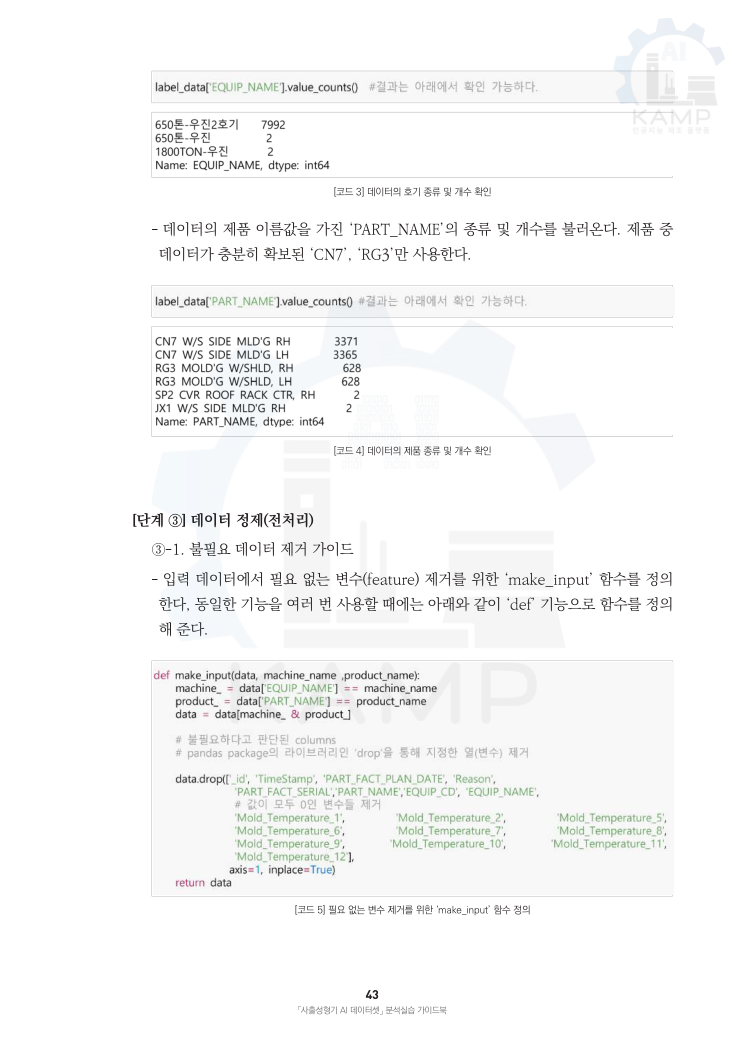

**가이드북 인쇄 62쪽: 코드/표 이미지 원문**

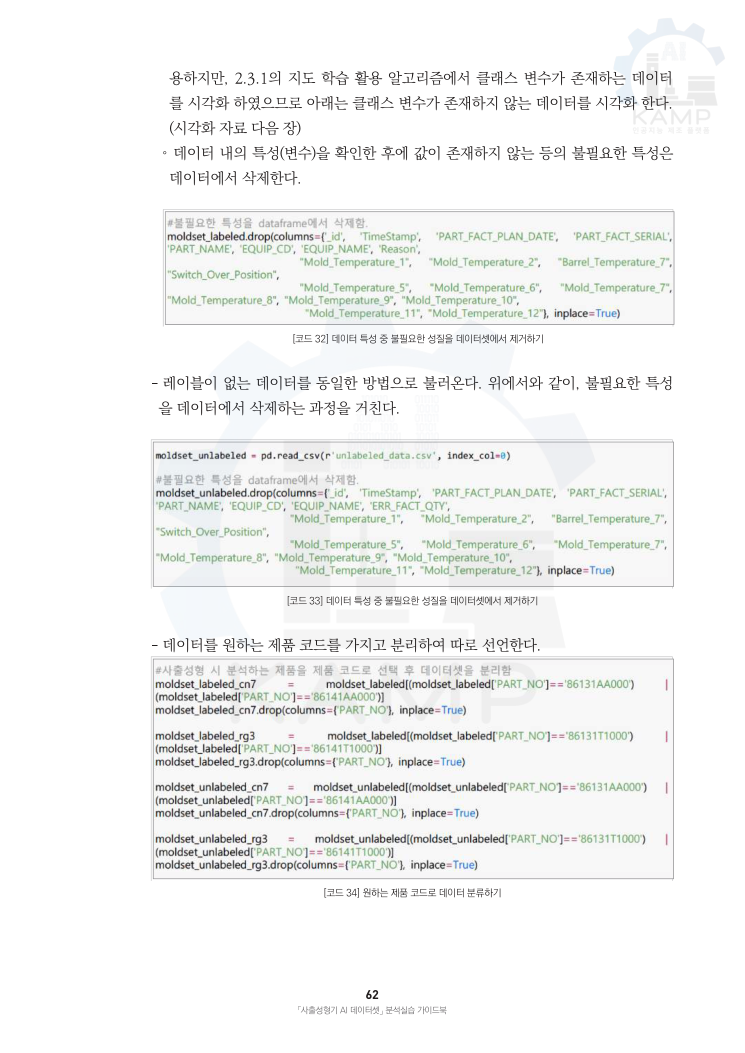

**가이드북 인쇄 69쪽: 코드/표 이미지 원문**

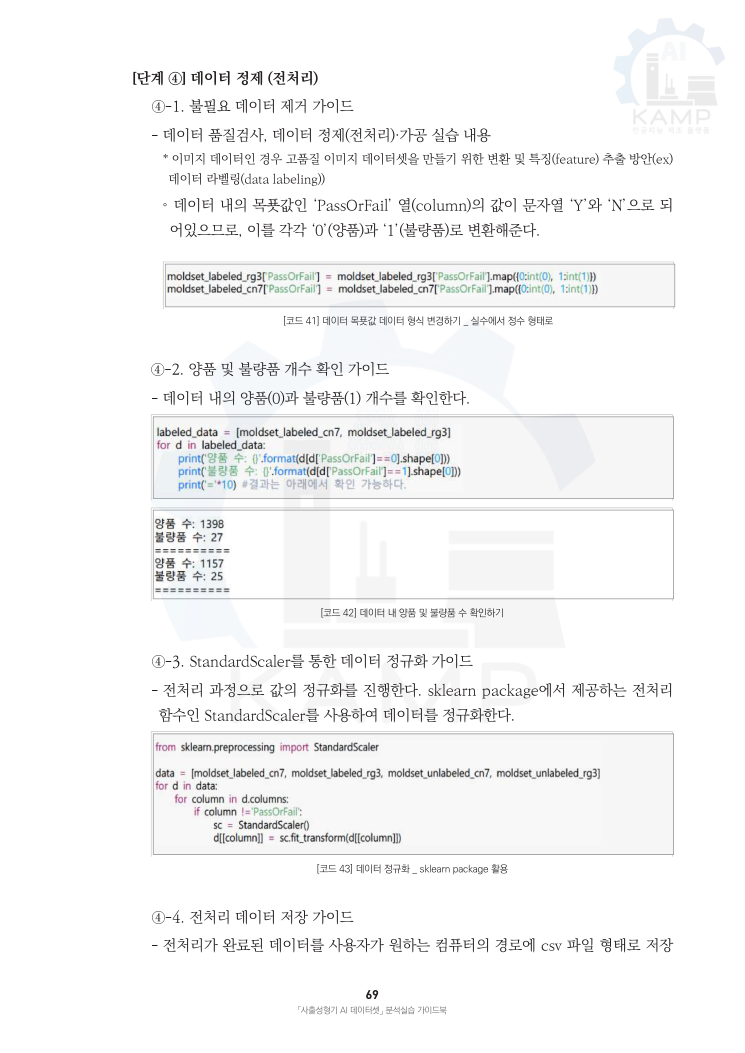

In [4]:
if not GUIDE_PATH.is_file(): raise FileNotFoundError(f'가이드북 없음: {GUIDE_PATH}')
guide=fitz.open(GUIDE_PATH)
for printed in [5,6,7,20,21]:
    say(f'**가이드북 인쇄 {printed}쪽 (PDF {printed+1}쪽)**')
    print(guide[printed].get_text()[:14000])
for printed in [43,62,69]:
    say(f'**가이드북 인쇄 {printed}쪽: 코드/표 이미지 원문**')
    display(Image(data=guide[printed].get_pixmap(matrix=fitz.Matrix(1.25,1.25)).tobytes('png')))


In [5]:
FEATURES = ['Injection_Time','Filling_Time','Plasticizing_Time','Cycle_Time','Clamp_Close_Time','Cushion_Position','Plasticizing_Position','Clamp_Open_Position','Max_Injection_Speed','Max_Screw_RPM','Average_Screw_RPM','Max_Injection_Pressure','Max_Switch_Over_Pressure','Max_Back_Pressure','Average_Back_Pressure']+[f'Barrel_Temperature_{i}' for i in range(1,7)]+['Hopper_Temperature','Mold_Temperature_3','Mold_Temperature_4']

GROUPS = {'Filling':['Filling_Time','Max_Injection_Speed'], 'Injection shared':['Injection_Time','Max_Injection_Pressure'], 'Switch':['Max_Switch_Over_Pressure'], 'Cushion':['Cushion_Position'], 'Plasticizing':['Plasticizing_Time','Plasticizing_Position','Max_Back_Pressure','Average_Back_Pressure']}

THERMAL=[f'Barrel_Temperature_{i}' for i in range(1,7)]+['Hopper_Temperature']

defs=['고압+사출시간','충전시간','1회 생산량 수지의 용융·계량시간','제품 생산 사이클 시간','금형 닫힘 시간','보압을 하기 위한 스크류 위치','계량 완료 스크류 위치','금형 열림 위치','금형 내 수지 최대 유입속도','사출을 위한 스크류 최대속도','사출을 위한 스크류 평균속도','금형으로 주입하는 수지 최대압력','사출에서 보압 전환 압력','계량 중 스크류 후퇴 저항 최대압력','계량 중 스크류 후퇴 저항 평균압력']+['계량·사출 중 수지 용융 유지 온도']*6+['재료 투입구 온도','재료 투입구 온도로 기재됨','재료 투입구 온도로 기재됨']
units=['s']*5+['mm']*3+['mm/s']*3+['MPa']*4+['°C']*9
dictionary=[]
for c,d,u in zip(FEATURES,defs,units):
    g=next((g for g,cs in GROUPS.items() if c in cs), '열적 조건' if c in THERMAL else '의미 확인 필요' if 'RPM' in c or 'Mold_Temperature' in c else '전체 생산시간' if c=='Cycle_Time' else '금형 닫힘' if c=='Clamp_Close_Time' else '금형 열림')
    dictionary.append([c,d,u,g,20 if FEATURES.index(c)<15 else 21,'이름·설명·단위 불일치' if 'RPM' in c else '금형 이름과 투입구 설명 불일치' if 'Mold_Temperature' in c else '정의 요약; 원문은 위 페이지 확인','파일별 표준화 척도(원시 단위 아님)'])
variable_dictionary=pd.DataFrame(dictionary,columns=['컬럼','가이드북 정의 요약','원래 단위','분석 구분','인쇄 쪽수','미확인 사항','현재 척도'])
display(variable_dictionary)
say('충전 → 가압 → 보압 순서로 해석한다. Injection_Time과 Max_Injection_Pressure는 사출 공통 지표이며 가압 전용 측정값이 아니다. Cushion_Position은 보압 관련 위치다. 전환압력과 쿠션만으로 보압 시간·압력 유지 전체를 측정할 수 없다. RPM과 금형 온도는 확정적인 단계 증거로 사용하지 않는다. 69쪽 코드는 0=정상, 1=불량 및 파일별·컬럼별 StandardScaler 적용을 보여준다.')


,컬럼,가이드북 정의 요약,원래 단위,분석 구분,인쇄 쪽수,미확인 사항,현재 척도
0,Injection_Time,고압+사출시간,s,Injection shared,20,정의 요약; 원문은 위 페이지 확인,파일별 표준화 척도(원시 단위 아님)
1,Filling_Time,충전시간,s,Filling,20,정의 요약; 원문은 위 페이지 확인,파일별 표준화 척도(원시 단위 아님)
2,Plasticizing_Time,1회 생산량 수지의 용융·계량시간,s,Plasticizing,20,정의 요약; 원문은 위 페이지 확인,파일별 표준화 척도(원시 단위 아님)
3,Cycle_Time,제품 생산 사이클 시간,s,전체 생산시간,20,정의 요약; 원문은 위 페이지 확인,파일별 표준화 척도(원시 단위 아님)
4,Clamp_Close_Time,금형 닫힘 시간,s,금형 닫힘,20,정의 요약; 원문은 위 페이지 확인,파일별 표준화 척도(원시 단위 아님)
5,Cushion_Position,보압을 하기 위한 스크류 위치,mm,Cushion,20,정의 요약; 원문은 위 페이지 확인,파일별 표준화 척도(원시 단위 아님)
6,Plasticizing_Position,계량 완료 스크류 위치,mm,Plasticizing,20,정의 요약; 원문은 위 페이지 확인,파일별 표준화 척도(원시 단위 아님)
7,Clamp_Open_Position,금형 열림 위치,mm,금형 열림,20,정의 요약; 원문은 위 페이지 확인,파일별 표준화 척도(원시 단위 아님)
8,Max_Injection_Speed,금형 내 수지 최대 유입속도,mm/s,Filling,20,정의 요약; 원문은 위 페이지 확인,파일별 표준화 척도(원시 단위 아님)
9,Max_Screw_RPM,사출을 위한 스크류 최대속도,mm/s,의미 확인 필요,20,이름·설명·단위 불일치,파일별 표준화 척도(원시 단위 아님)


충전 → 가압 → 보압 순서로 해석한다. Injection_Time과 Max_Injection_Pressure는 사출 공통 지표이며 가압 전용 측정값이 아니다. Cushion_Position은 보압 관련 위치다. 전환압력과 쿠션만으로 보압 시간·압력 유지 전체를 측정할 수 없다. RPM과 금형 온도는 확정적인 단계 증거로 사용하지 않는다. 69쪽 코드는 0=정상, 1=불량 및 파일별·컬럼별 StandardScaler 적용을 보여준다.

## 2. 입력 검증·원본 보존·데이터 구조
**방법·근거:** 파일명으로 검색하며 중복 파일명은 임의 선택하지 않는다. 공정값은 반올림 없이 정확 비교한다. source_id는 출처일 뿐 시간이나 생산 사이클이 아니다. 결측/무한대가 발견되면 자동 대치하지 않고 진단 후 중단한다.

In [6]:
NAMES=[f'moldset_{kind}_{p}.csv' for kind in ['labeled','unlabeled'] for p in ['cn7','rg3']]
raw={}; data={}
if not DATA_PATH.exists(): raise FileNotFoundError(f'데이터 없음: {DATA_PATH}')
for name in NAMES:
    if DATA_PATH.is_dir():
        matches=list(DATA_PATH.rglob(name))
        if len(matches)!=1: raise ValueError(f'{name}: 발견 {len(matches)}개; 정확히 하나 필요')
        payload=matches[0].read_bytes()
    else:
        with zipfile.ZipFile(DATA_PATH) as z:
            matches=[x for x in z.namelist() if Path(x).name==name]
            if len(matches)!=1: raise ValueError(f'{name}: ZIP 안 발견 {len(matches)}개')
            payload=z.read(matches[0])
    df=pd.read_csv(io.BytesIO(payload)); raw[name]=df.copy(deep=True)
    required=FEATURES+(['PassOrFail'] if '_labeled_' in name else [])
    missing=set(required)-set(df)
    if missing: raise ValueError(f'{name}: 필수 컬럼 누락 {sorted(missing)}')
    if 'Unnamed: 0' not in df: raise ValueError(f'{name}: 원본 ID 컬럼 없음')
    df=df.rename(columns={'Unnamed: 0':'source_id'}).copy()
    df['product']=name.split('_')[-1].split('.')[0].upper(); df['source_file']=name; df['record_order']=np.arange(len(df))
    if 'PassOrFail' in df and not set(df.PassOrFail.unique())<={0,1}: raise ValueError('0/1 이외 라벨')
    data[name]=df
quality=[]
for name,d in data.items():
    a=d[FEATURES]
    quality.append([name,len(d),len(raw[name].columns),a.isna().sum().sum(),np.isinf(a.to_numpy()).sum(),list(a.columns[a.nunique()==1]),hashlib.sha256(raw[name].to_csv(index=False).encode()).hexdigest()])
display(pd.DataFrame(quality,columns=['파일','행','원본 열','결측','무한대','상수열','내용 SHA256']))
display(pd.concat({name:d[FEATURES].agg(['count','nunique']).T.assign(dtype=d[FEATURES].dtypes.astype(str)) for name,d in data.items()},names=['파일','변수']))
assert all(q[3]==0 and q[4]==0 for q in quality),'비유한값 처리 방침을 먼저 결정해야 함'
L={p:data[f'moldset_labeled_{p.lower()}.csv'].copy() for p in ['CN7','RG3']}
U={p:data[f'moldset_unlabeled_{p.lower()}.csv'].copy() for p in L}
PAT={}; NORMAL={}; BAD={}
for p,d in L.items():
    d['pattern_id']=pd.MultiIndex.from_frame(d[FEATURES]).factorize(sort=False)[0]
    PAT[p]=d.groupby('pattern_id').PassOrFail.agg(rows='size',bad='sum'); PAT[p]['normal']=PAT[p].rows-PAT[p].bad
    PAT[p]['type']=np.select([PAT[p].bad.eq(0),PAT[p].normal.eq(0)],['normal only','defect only'],default='conflicting')
    NORMAL[p]=d[d.PassOrFail.eq(0)].drop_duplicates(FEATURES); BAD[p]=d[d.PassOrFail.eq(1)].drop_duplicates(FEATURES)
    say(f'**{p}: 행 기준 {len(d)}개, 정상 {(d.PassOrFail==0).sum()}개, 불량 {d.PassOrFail.sum()}개 ({d.PassOrFail.mean():.2%}); 공정 패턴 {len(PAT[p])}개**')
    display(PAT[p].groupby('type').agg(patterns=('rows','size'),rows=('rows','sum'),normal=('normal','sum'),bad=('bad','sum')))
    display(pd.DataFrame({'중복 정의':['ID 제외·라벨 포함','ID·라벨 제외'], '중복 초과 행':[d.duplicated(FEATURES+['PassOrFail']).sum(),d.duplicated(FEATURES).sum()]}))
for p,d in U.items():
    say(f'{p} 비라벨: 전체 공정값 고유 패턴 {len(d.drop_duplicates(FEATURES)):,}, 중복 초과 행 {d.duplicated(FEATURES).sum():,}.')


,파일,행,원본 열,결측,무한대,상수열,내용 SHA256
0,moldset_labeled_cn7.csv,1211,26,0,0,[Clamp_Open_Position],abfffbad596d808d93af7fd658b1d4976c52393be76cb8...
1,moldset_labeled_rg3.csv,1182,26,0,0,[Clamp_Open_Position],5cf92602ff18bc3c77d250120244f7ccb9b38233c35e88...
2,moldset_unlabeled_cn7.csv,35239,25,0,0,[],25eeca5de9867eb2bb013639ec62645b2b5ef1cf4ea2f8...
3,moldset_unlabeled_rg3.csv,35941,25,0,0,[],e86061a8506437c7db2be5a71c3d994b508073bda7ddd3...


count  nunique    dtype
파일                        변수                                               
moldset_labeled_cn7.csv   Injection_Time             1211       15  float64
                          Filling_Time               1211       14  float64
                          Plasticizing_Time          1211       34  float64
                          Cycle_Time                 1211       13  float64
                          Clamp_Close_Time           1211        3  float64
                          Cushion_Position           1211        5  float64
                          Plasticizing_Position      1211       13  float64
                          Clamp_Open_Position        1211        1  float64
                          Max_Injection_Speed        1211       20  float64
                          Max_Screw_RPM              1211        8  float64
                          Average_Screw_RPM          1211        7  float64
                          Max_Injection_Pressure     1211        8  float64
                          Max_Switch_Over_Pressure   1211       17  float64
                          Max_Back_Pressure          1211       25  float64
                          Average_Back_Pressure      1211       15  float64
                          Barrel_Temperature_1       1211       25  float64
                          Barrel_Temperature_2       1211       24  float64
                          Barrel_Temperature_3       1211       19  float64
                          Barrel_Temperature_4       1211       36  float64
                          Barrel_Temperature_5       1211       22  float64
                          Barrel_Temperature_6       1211       13  float64
                          Hopper_Temperature         1211       47  float64
                          Mold_Temperature_3         1211       39  float64
                          Mold_Temperature_4         1211       41  float64
moldset_labeled_rg3.csv   Injection_Time             1182        3  float64
                          Filling_Time               1182        2  float64
                          Plasticizing_Time          1182       27  float64
                          Cycle_Time                 1182       10  float64
                          Clamp_Close_Time           1182        3  float64
                          Cushion_Position           1182        7  float64
                          Plasticizing_Position      1182        8  float64
                          Clamp_Open_Position        1182        1  float64
                          Max_Injection_Speed        1182        7  float64
                          Max_Screw_RPM              1182        4  float64
                          Average_Screw_RPM          1182        4  float64
                          Max_Injection_Pressure     1182       10  float64
                          Max_Switch_Over_Pressure   1182       17  float64
                          Max_Back_Pressure          1182       16  float64
                          Average_Back_Pressure      1182       21  float64
                          Barrel_Temperature_1       1182       25  float64
                          Barrel_Temperature_2       1182       22  float64
                          Barrel_Temperature_3       1182       17  float64
                          Barrel_Temperature_4       1182       30  float64
                          Barrel_Temperature_5       1182       21  float64
                          Barrel_Temperature_6       1182       12  float64
                          Hopper_Temperature         1182       52  float64
                          Mold_Temperature_3         1182       26  float64
                          Mold_Temperature_4         1182       29  float64
moldset_unlabeled_cn7.csv Injection_Time            35239      115  float64
                          Filling_Time              35239      124  float64
                          Plasticizing_Time         35239      307  float64
                        

**CN7: 행 기준 1211개, 정상 1194개, 불량 17개 (1.40%); 공정 패턴 606개**

,patterns,rows,normal,bad
type,,,,
conflicting,11,22,11,11
defect only,3,6,0,6
normal only,592,1183,1183,0


,중복 정의,중복 초과 행
0,ID 제외·라벨 포함,594
1,ID·라벨 제외,605


**RG3: 행 기준 1182개, 정상 1157개, 불량 25개 (2.12%); 공정 패턴 591개**

,patterns,rows,normal,bad
type,,,,
conflicting,25,50,25,25
normal only,566,1132,1132,0


,중복 정의,중복 초과 행
0,ID 제외·라벨 포함,566
1,ID·라벨 제외,591


CN7 비라벨: 전체 공정값 고유 패턴 28,771, 중복 초과 행 6,468.

RG3 비라벨: 전체 공정값 고유 패턴 29,707, 중복 초과 행 6,234.

,product,pattern_id,normal_source_id,bad_source_id,ID_gap,row_gap
0,CN7,24,48,47,1,1
1,CN7,40,79,80,1,1
2,CN7,48,96,95,1,1
3,CN7,50,100,99,1,1
4,CN7,51,102,101,1,1
5,CN7,52,104,103,1,1
6,CN7,53,106,105,1,1
7,CN7,54,108,107,1,1
8,CN7,55,110,109,1,1
9,CN7,56,112,111,1,1


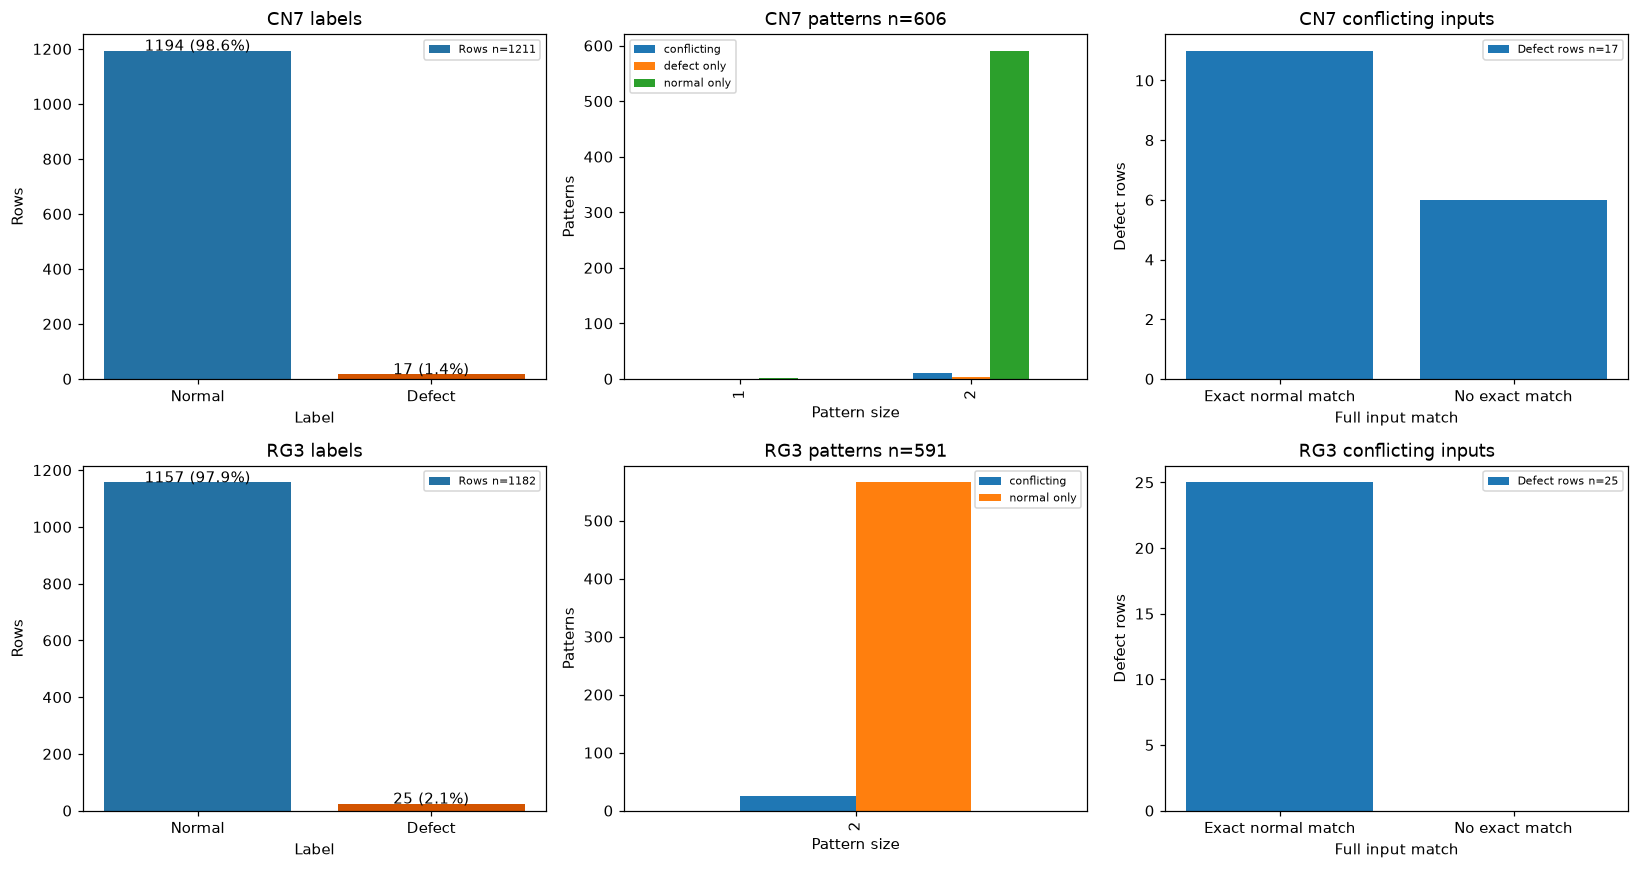

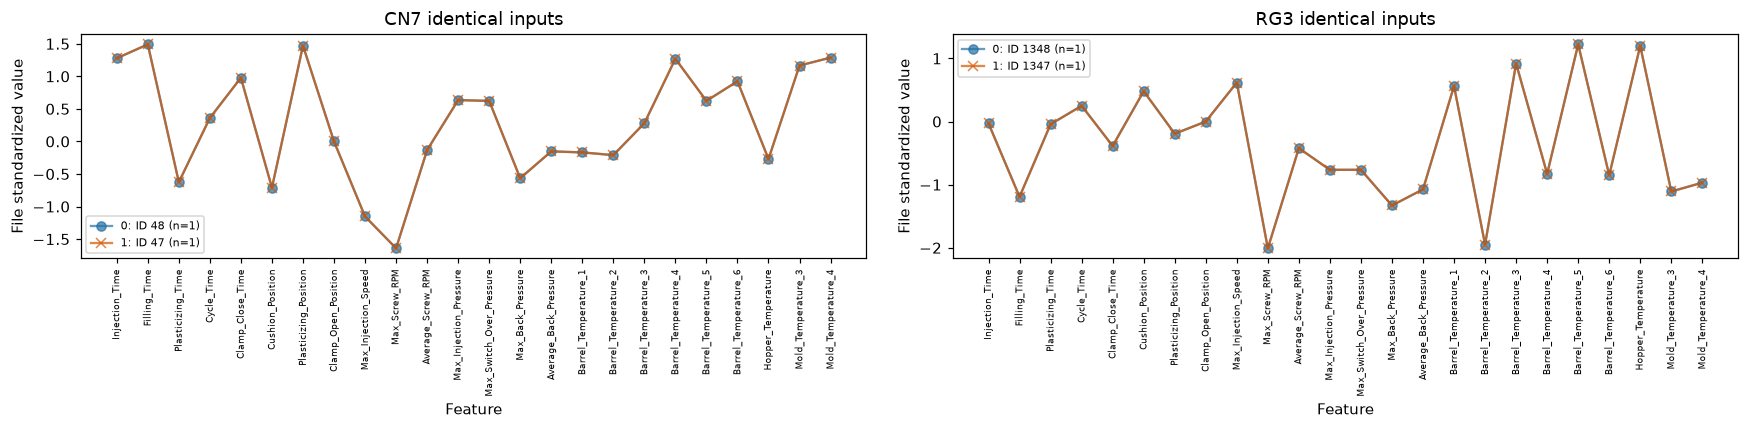

행 기준은 기록 빈도, 고유 패턴 기준은 서로 다른 입력 조합을 나타낸다. 상충 패턴은 정상·불량 고유집합 양쪽에 포함되므로 두 집합 크기의 합은 전체 고유 패턴 수와 다를 수 있다. 라벨 수정·중복 삭제는 원본에 적용하지 않는다. ID 간격 1은 동일 사이클이나 좌우 제품 대응의 증거가 아니다.

In [7]:
conflict_pairs=[]
for p,d in L.items():
    for pid,g in d.groupby('pattern_id'):
        for _,b in g[g.PassOrFail.eq(1)].iterrows():
            for _,a in g[g.PassOrFail.eq(0)].iterrows():
                conflict_pairs.append([p,pid,a.source_id,b.source_id,abs(b.source_id-a.source_id),abs(b.record_order-a.record_order)])
conflict_pairs=pd.DataFrame(conflict_pairs,columns=['product','pattern_id','normal_source_id','bad_source_id','ID_gap','row_gap'])
display(conflict_pairs)
fig,axs=plt.subplots(2,3,figsize=(15,8))
for i,(p,d) in enumerate(L.items()):
    counts=d.PassOrFail.value_counts().reindex([0,1],fill_value=0)
    axs[i,0].bar(['Normal','Defect'],counts,color=list(COLORS.values()),label=f'Rows n={len(d)}')
    for j,c in enumerate(counts): axs[i,0].text(j,c,f'{c} ({c/len(d):.1%})',ha='center')
    finish(axs[i,0],p+' labels','Label','Rows')
    PAT[p].groupby(['rows','type']).size().unstack(fill_value=0).plot.bar(ax=axs[i,1]);finish(axs[i,1],f'{p} patterns n={len(PAT[p])}','Pattern size','Patterns')
    b=d[d.PassOrFail.eq(1)]; shared=b.pattern_id.isin(NORMAL[p].pattern_id)
    axs[i,2].bar(['Exact normal match','No exact match'],[shared.sum(),(~shared).sum()],label=f'Defect rows n={len(b)}')
    finish(axs[i,2],p+' conflicting inputs','Full input match','Defect rows')
plt.tight_layout();plt.show()
fig,axs=plt.subplots(1,2,figsize=(16,4))
for ax,p in zip(axs,L):
    pair=conflict_pairs[conflict_pairs['product'].eq(p)].iloc[0]; d=L[p]
    for label,id_ in [(0,pair.normal_source_id),(1,pair.bad_source_id)]:
        row=d[d.source_id.eq(id_)].iloc[0]
        ax.plot(range(len(FEATURES)),row[FEATURES].astype(float),marker='o' if label==0 else 'x',label=f'{label}: ID {id_} (n=1)',color=COLORS[label],alpha=.7)
    ax.set_xticks(range(len(FEATURES)),FEATURES,rotation=90,fontsize=6);finish(ax,p+' identical inputs','Feature','File standardized value')
plt.tight_layout();plt.show()
say('행 기준은 기록 빈도, 고유 패턴 기준은 서로 다른 입력 조합을 나타낸다. 상충 패턴은 정상·불량 고유집합 양쪽에 포함되므로 두 집합 크기의 합은 전체 고유 패턴 수와 다를 수 있다. 라벨 수정·중복 삭제는 원본에 적용하지 않는다. ID 간격 1은 동일 사이클이나 좌우 제품 대응의 증거가 아니다.')


## 3. 기본 분포와 극단값
**방법·설정:** 분위수는 분포 요약이며 판정값이 아니다. 행/라벨별 고유 입력 두 관점을 비교한다. IQR 계수 1.5는 관행적 박스플롯 기준, 3은 이전 분석 재현, 4.5는 더 느슨한 탐색 범위다. 어느 것도 제조 규격이 아니다. 0-IQR은 비상수 이산열에서도 발생하므로 별도 표기한다. 봉우리 수는 히스토그램 분할에 민감하여 자동 확정하지 않는다.

**CN7 정상 행 분포 진단**

,nunique,skew,IQR,constant,IQR_zero_nonconstant
Injection_Time,13,-0.602351,1.604902,False,False
Filling_Time,13,-0.689283,1.208884,False,False
Plasticizing_Time,34,15.105702,0.588984,False,False
Cycle_Time,12,4.914525,1.016809,False,False
Clamp_Close_Time,3,0.423839,1.881046,False,False
Cushion_Position,4,1.111378,1.913667,False,False
Plasticizing_Position,13,0.816577,2.113898,False,False
Clamp_Open_Position,1,0.000000,0.000000,True,False
Max_Injection_Speed,17,3.048932,0.973464,False,False
Max_Screw_RPM,8,0.489592,1.690583,False,False


**RG3 정상 행 분포 진단**

,nunique,skew,IQR,constant,IQR_zero_nonconstant
Injection_Time,3,2.043208,0.000000,False,True
Filling_Time,2,-0.353273,2.031084,False,False
Plasticizing_Time,27,0.552699,1.346836,False,False
Cycle_Time,10,8.365653,0.548218,False,False
Clamp_Close_Time,3,-0.435188,1.419868,False,False
Cushion_Position,7,0.111751,1.594763,False,False
Plasticizing_Position,8,-0.036299,1.562888,False,False
Clamp_Open_Position,1,0.000000,0.000000,True,False
Max_Injection_Speed,7,-0.011341,1.569938,False,False
Max_Screw_RPM,4,0.015956,1.342861,False,False


,count,mean,std,min,5%,25%,50%,75%,95%,max,product,view,label
Injection_Time,1194.0,0.009360,0.957047,-7.549091,-1.129445,-0.728249,-0.327014,0.876653,1.679123,2.080358,CN7,rows,0
Filling_Time,1194.0,0.009477,0.955161,-7.776799,-1.329345,-0.523416,-0.120461,0.685468,1.491397,2.297327,CN7,rows,0
Plasticizing_Time,1194.0,0.006107,1.006129,-0.723425,-0.576184,-0.379849,-0.036274,0.209135,0.454553,20.038456,CN7,rows,0
Cycle_Time,1194.0,-0.001734,0.996138,-3.706092,-1.164166,-0.655762,0.361047,0.361047,1.377857,12.562466,CN7,rows,0
Clamp_Close_Time,1194.0,-0.017084,0.994509,-0.902466,-0.902466,-0.902466,-0.902466,0.978580,0.978580,2.859537,CN7,rows,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Barrel_Temperature_5,25.0,0.445713,0.918931,-0.971148,-0.657751,-0.344258,0.282727,1.223110,2.038191,2.790479,RG3,unique within label,1
Barrel_Temperature_6,25.0,0.043579,0.907686,-2.342787,-1.646738,-0.354184,0.143005,0.640193,1.137306,1.634495,RG3,unique within label,1
Hopper_Temperature,25.0,-0.134011,0.926493,-2.460435,-1.647000,-0.528528,0.081547,0.589944,1.139018,1.200026,RG3,unique within label,1
Mold_Temperature_3,25.0,-0.088344,0.962576,-1.820935,-1.564465,-0.823555,-0.111141,0.601272,1.399176,1.598652,RG3,unique within label,1


,product,IQR coefficient,label,row denominator,flagged rows,source IDs
0,CN7,1.5,0,1194,200,"[1, 2, 5, 6, 17, 18, 25, 26, 29, 30, 31, 32, 3..."
1,CN7,1.5,1,17,10,"[95, 99, 107, 113, 115, 116, 117, 118, 119, 120]"
2,CN7,3.0,0,1194,14,"[71, 72, 307, 308, 327, 328, 1203, 1204, 1205,..."
3,CN7,3.0,1,17,6,"[115, 116, 117, 118, 119, 120]"
4,CN7,4.5,0,1194,10,"[71, 72, 327, 328, 1205, 1206, 1207, 1208, 120..."
5,CN7,4.5,1,17,6,"[115, 116, 117, 118, 119, 120]"
6,RG3,1.5,0,1157,262,"[1219, 1220, 1225, 1226, 1229, 1230, 1239, 124..."
7,RG3,1.5,1,25,2,"[1761, 2343]"
8,RG3,3.0,0,1157,12,"[1697, 1698, 1869, 1870, 2017, 2018, 2207, 220..."
9,RG3,3.0,1,25,0,[]


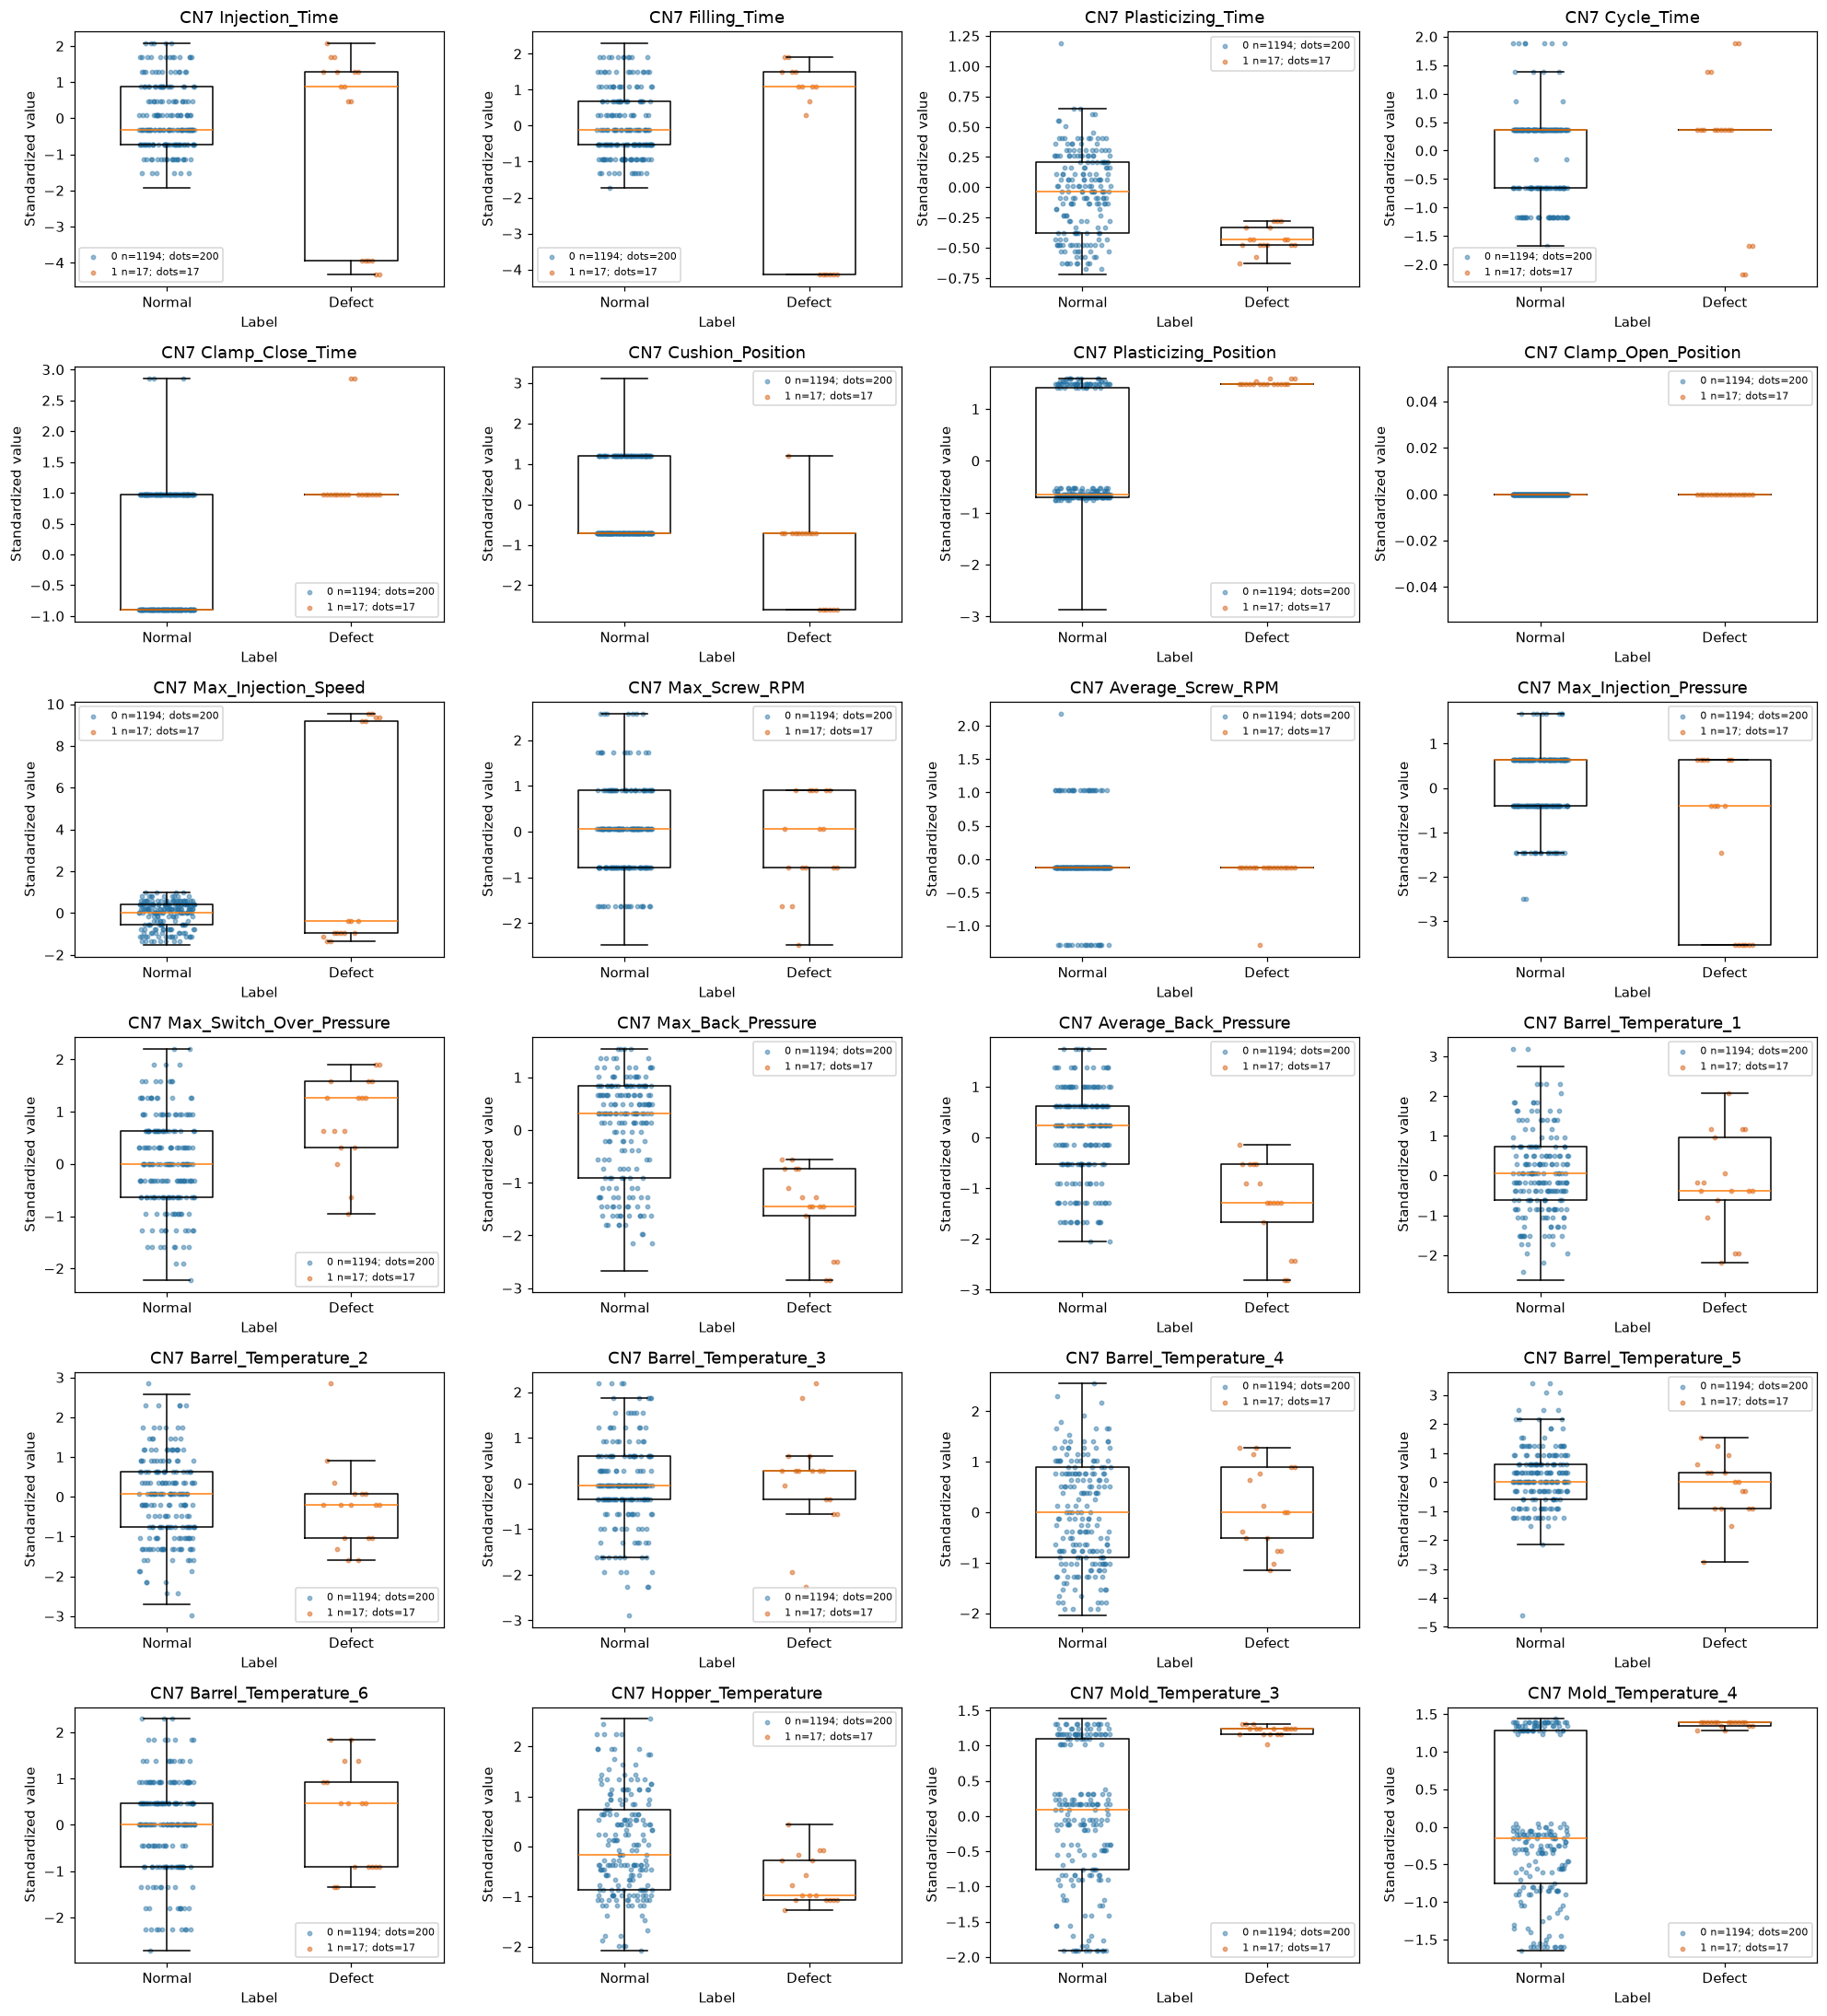

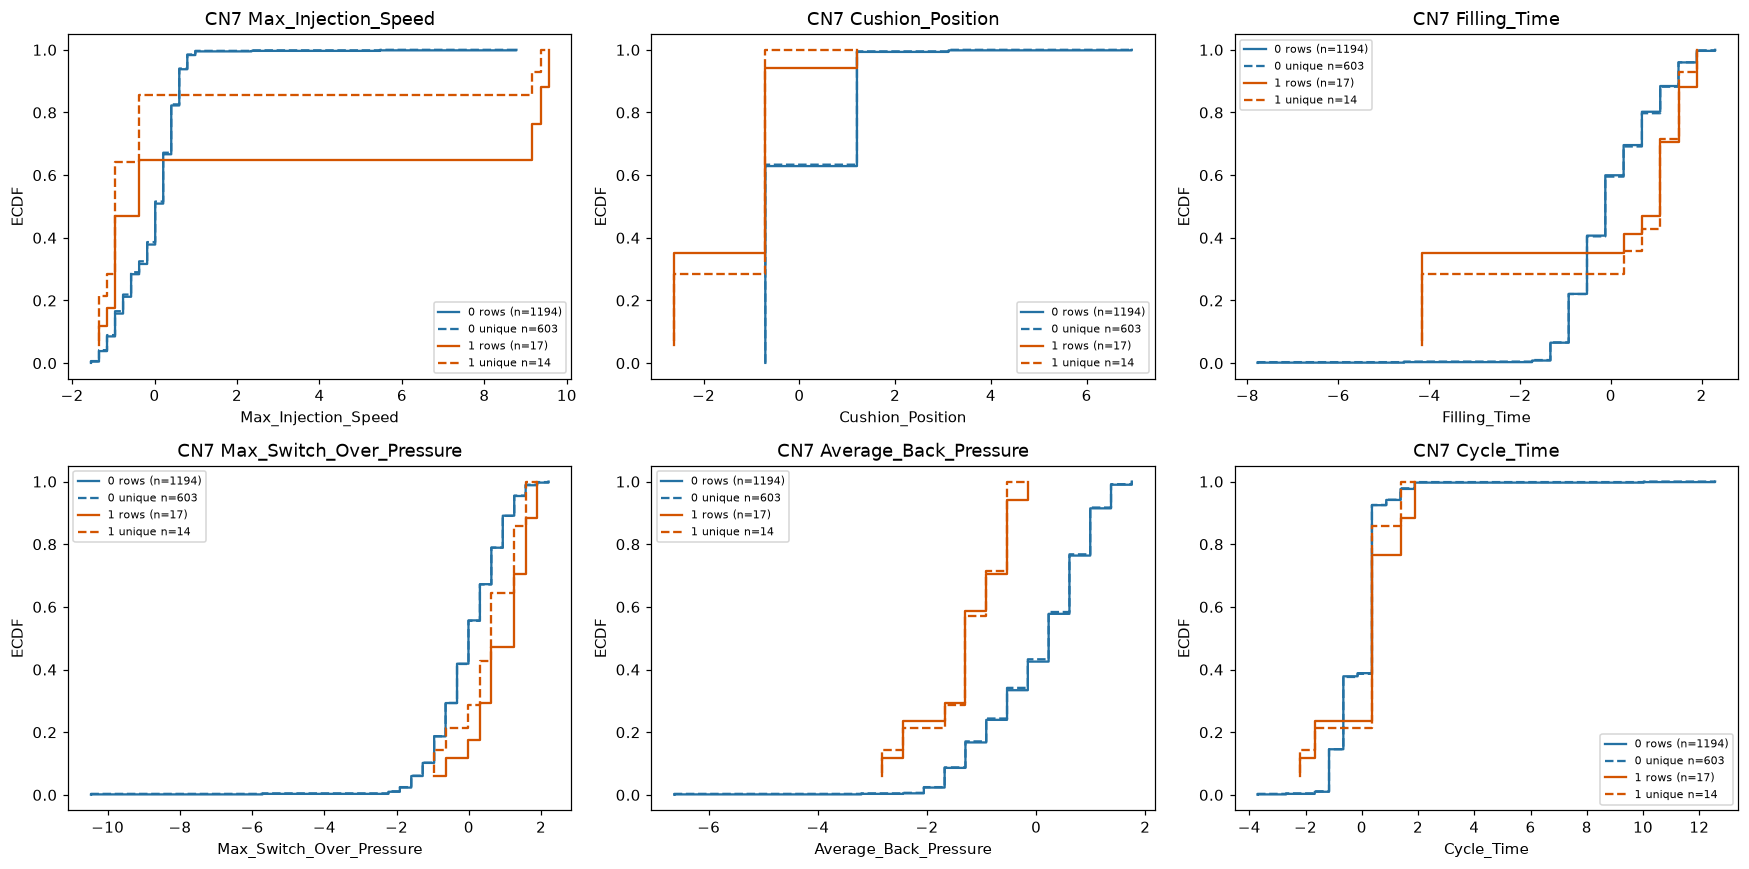

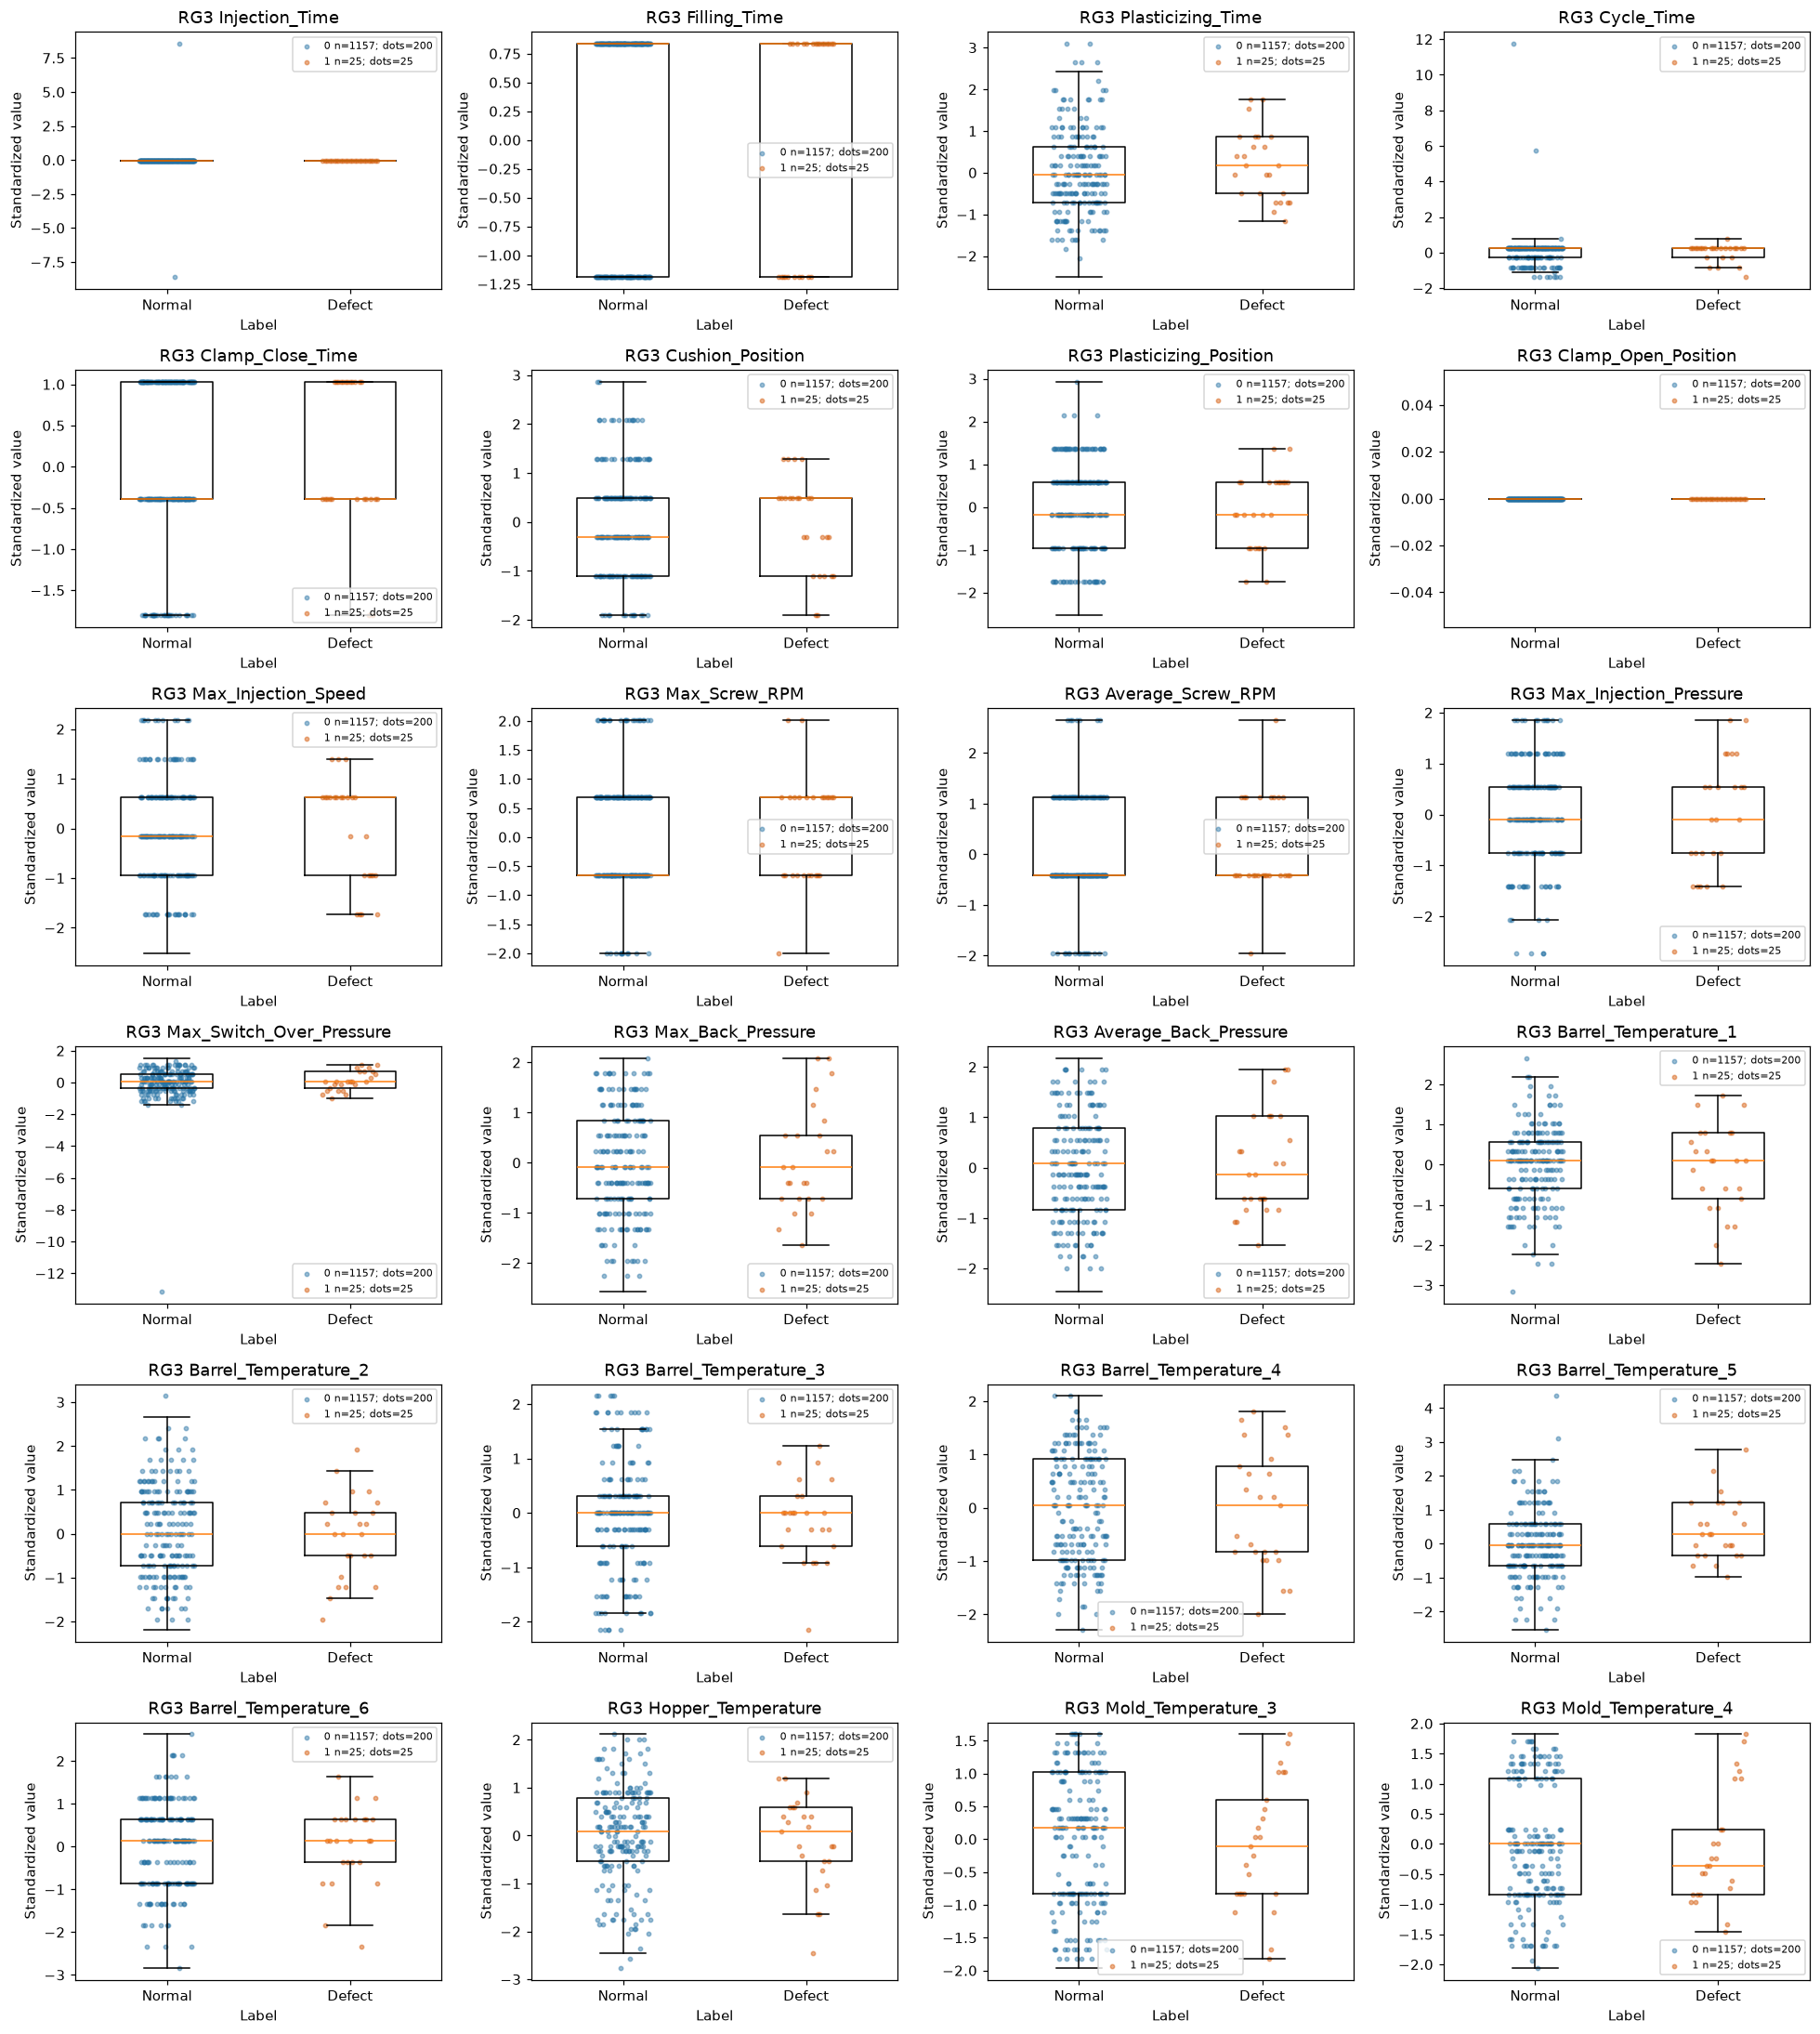

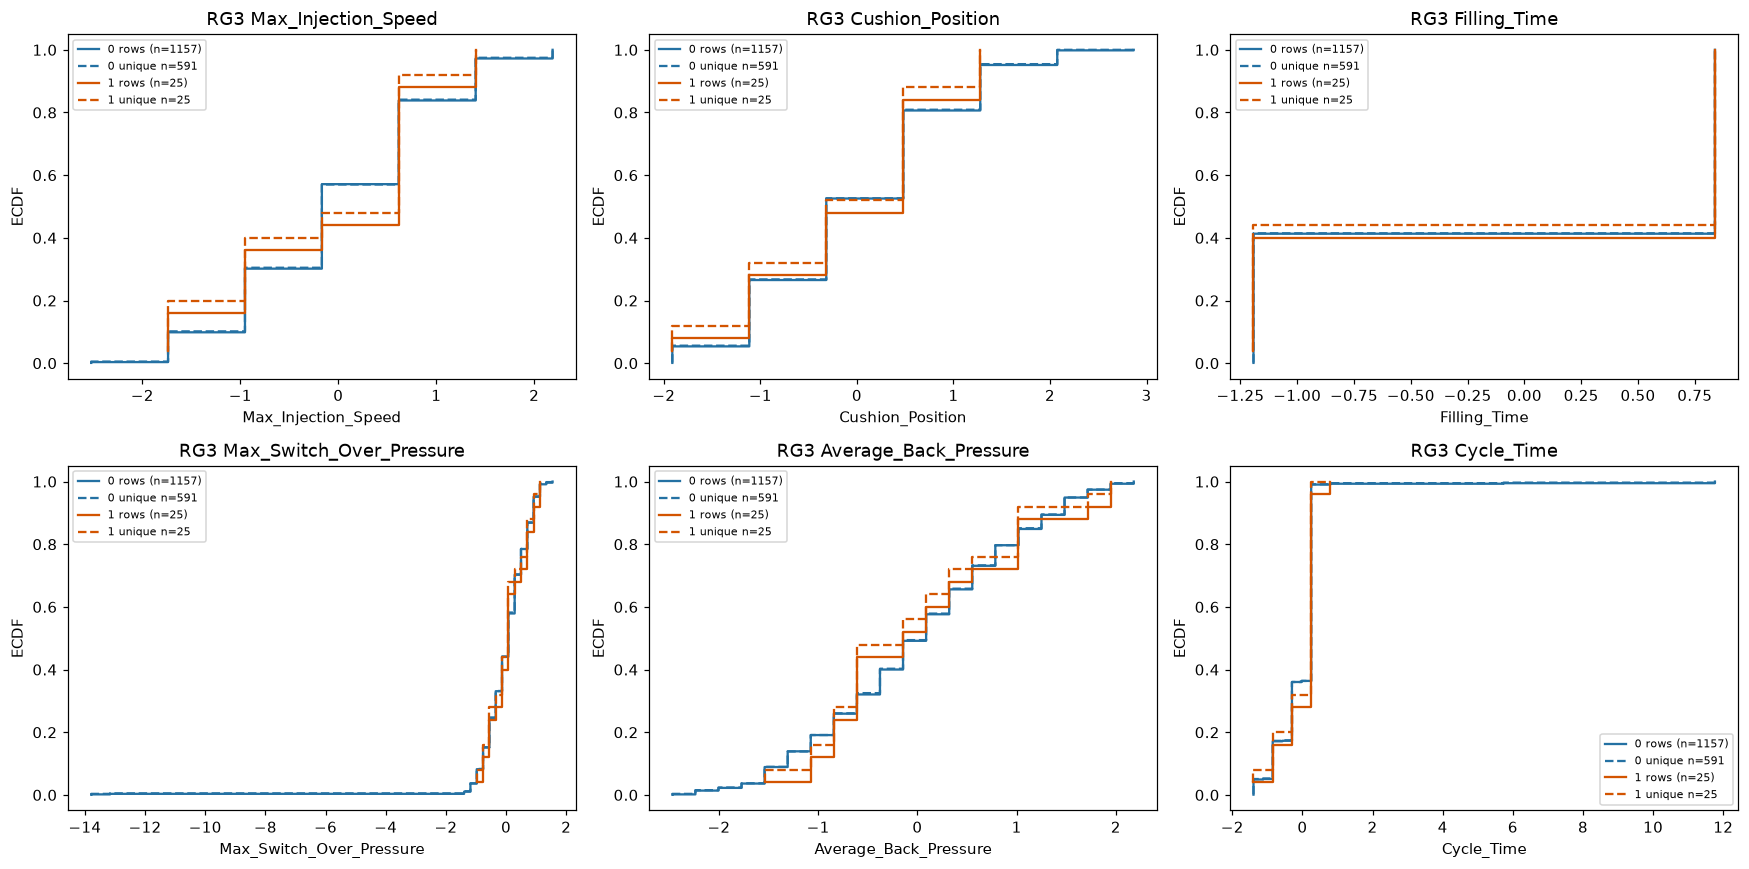

불량 표본은 적고 반복 기록이 있다. 박스플롯만으로 꼬리 사례를 숨기지 않도록 불량 점을 모두 표시했다. 정상 점 최대 200개는 렌더링 예산이며 통계 계산은 전체 행이다. IQR=0 열은 이 규칙의 표시에서 제외했지만 실제 값 분포와 정확 조합 분석에서 계속 확인한다. 관측 정상 최솟값·최댓값은 공정 허용 한계가 아니다.

In [8]:
distribution=[]; extreme=[]
for p,d in L.items():
    for view,t in [('rows',d),('unique within label',d.drop_duplicates(FEATURES+['PassOrFail']))]:
        for label,g in t.groupby('PassOrFail'):
            q=g[FEATURES].describe(percentiles=[.05,.25,.5,.75,.95]).T
            q['product']=p;q['view']=view;q['label']=label;distribution.append(q)
    ref=d[d.PassOrFail.eq(0)][FEATURES]; q1=ref.quantile(.25);q3=ref.quantile(.75);iq=q3-q1
    diag=pd.DataFrame({'nunique':ref.nunique(),'skew':ref.skew(),'IQR':iq,'constant':ref.nunique().eq(1),'IQR_zero_nonconstant':iq.eq(0)&ref.nunique().gt(1)})
    say(f'**{p} 정상 행 분포 진단**');display(diag)
    for coef in IQR_COEFFICIENTS:
        flag=((d[FEATURES]<q1-coef*iq)|(d[FEATURES]>q3+coef*iq)) & iq.gt(0)
        for label in [0,1]:
            mask=d.PassOrFail.eq(label); extreme.append([p,coef,label,int(mask.sum()),int(flag.loc[mask].any(axis=1).sum()),d.loc[mask&flag.any(axis=1),'source_id'].tolist()])
distribution_table=pd.concat(distribution);display(distribution_table)
extreme_table=pd.DataFrame(extreme,columns=['product','IQR coefficient','label','row denominator','flagged rows','source IDs']);display(extreme_table)
for p,d in L.items():
    fig,axs=plt.subplots(6,4,figsize=(18,20))
    for ax,c in zip(axs.flat,FEATURES):
        for label in [0,1]:
            g=d[d.PassOrFail.eq(label)][c];ax.boxplot(g,positions=[label],widths=.5,showfliers=False)
            vals=g if label else g.sample(min(200,len(g)),random_state=SEED)
            ax.scatter(np.full(len(vals),label)+np.linspace(-.15,.15,len(vals)),vals,s=8,color=COLORS[label],alpha=.45,label=f'{label} n={len(g)}; dots={len(vals)}')
        ax.set_xticks([0,1],['Normal','Defect']);finish(ax,p+' '+c,'Label','Standardized value')
    plt.tight_layout();plt.show()
    fig,axs=plt.subplots(2,3,figsize=(16,8))
    for ax,c in zip(axs.flat,['Max_Injection_Speed','Cushion_Position','Filling_Time','Max_Switch_Over_Pressure','Average_Back_Pressure','Cycle_Time']):
        for label in [0,1]:
            g=d[d.PassOrFail.eq(label)];ecdf(ax,g[c],f'{label} rows',COLORS[label])
            a=np.sort(g.drop_duplicates(FEATURES)[c]);ax.step(a,np.arange(1,len(a)+1)/len(a),ls='--',color=COLORS[label],label=f'{label} unique n={len(a)}')
        finish(ax,p+' '+c,c,'ECDF')
    plt.tight_layout();plt.show()
say('불량 표본은 적고 반복 기록이 있다. 박스플롯만으로 꼬리 사례를 숨기지 않도록 불량 점을 모두 표시했다. 정상 점 최대 200개는 렌더링 예산이며 통계 계산은 전체 행이다. IQR=0 열은 이 규칙의 표시에서 제외했지만 실제 값 분포와 정확 조합 분석에서 계속 확인한다. 관측 정상 최솟값·최댓값은 공정 허용 한계가 아니다.')


### 분포 모양에 따른 극단값 규칙의 한계
**질문 → 방법:** 이산 수준과 히스토그램 분할을 바꿔도 보이는 봉우리를 확인한다. FD는 IQR과 표본수, Sturges는 로그 표본수에 근거한 시각화 분할 규칙이며 정상/불량 임계값이 아니다. 자동 봉우리 수를 선택하지 않는다. 아래 수준별 집계의 분모는 행이며, 열별 고유값 수가 적어도 공정 전체 입력은 다를 수 있다.

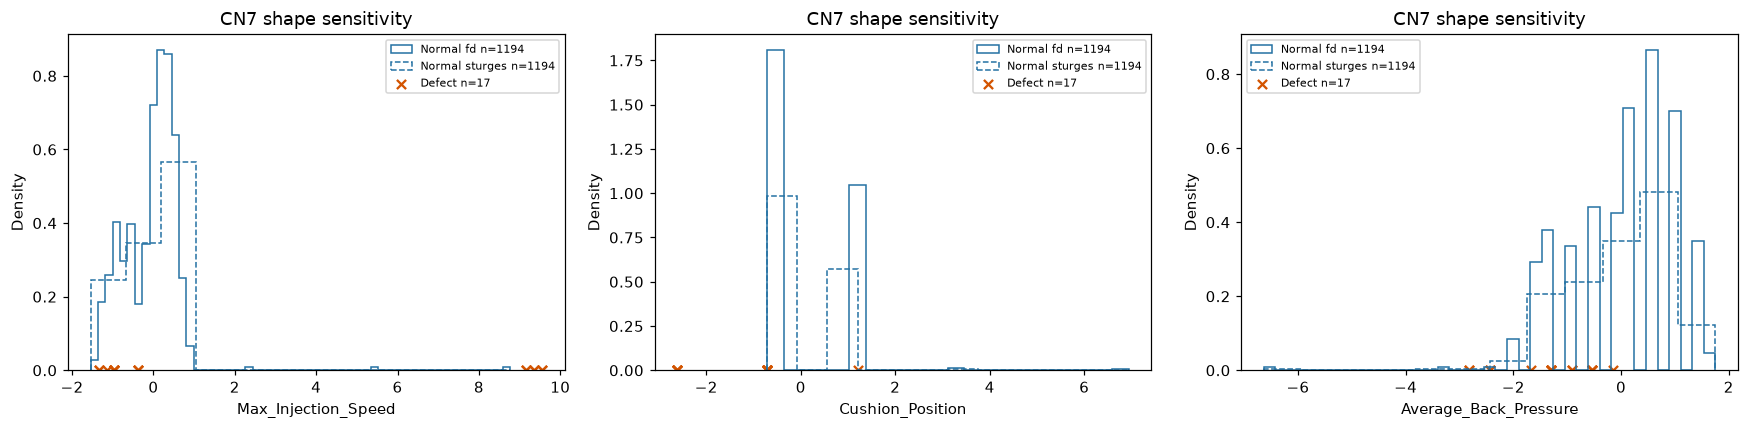

,row_denominator,bad_rows,bad_fraction
Cushion_Position,,,
-2.613163,6,6,1.000000
-0.711164,761,10,0.013141
1.202502,436,1,0.002294
3.116169,6,0,0.000000
6.943503,2,0,0.000000


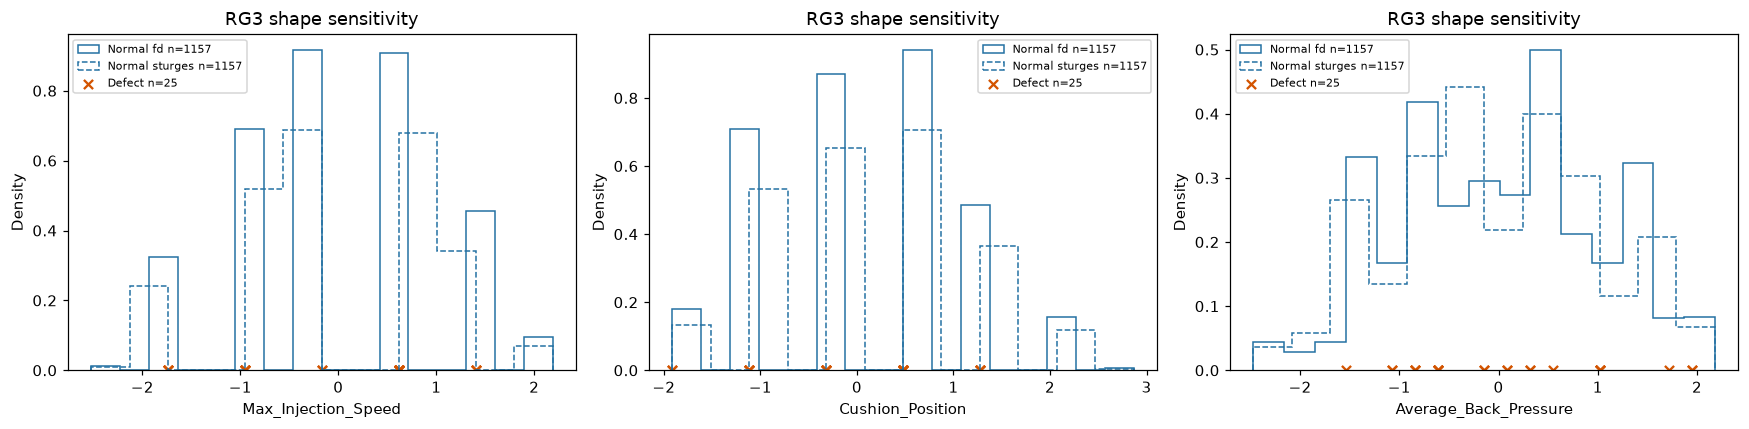

,row_denominator,bad_rows,bad_fraction
Cushion_Position,,,
-1.911818,64,2,0.031250
-1.114437,250,5,0.020000
-0.317055,306,5,0.016340
0.480326,334,9,0.026946
1.277707,172,4,0.023256
2.075089,54,0,0.000000
2.867608,2,0,0.000000


쿠션처럼 적은 수준에 관측이 집중된 변수는 히스토그램 모양을 연속 밀도로 과해석하지 않는다. 극단값의 삭제보다 정상·불량이 공유하는 실제 수준과 공정 조합을 확인하는 것이 우선이다.

In [9]:
for p,d in L.items():
    fig,axs=plt.subplots(1,3,figsize=(16,4))
    for ax,c in zip(axs,['Max_Injection_Speed','Cushion_Position','Average_Back_Pressure']):
        normal=d.loc[d.PassOrFail.eq(0),c]
        for rule,style in [('fd','-'),('sturges','--')]:
            ax.hist(normal,bins=rule,density=True,histtype='step',linestyle=style,color=COLORS[0],label=f'Normal {rule} n={len(normal)}')
        bad=d.loc[d.PassOrFail.eq(1),c];ax.scatter(bad,np.zeros(len(bad)),color=COLORS[1],marker='x',label=f'Defect n={len(bad)}')
        finish(ax,p+' shape sensitivity',c,'Density')
    plt.tight_layout();plt.show()
    display(d.groupby('Cushion_Position').PassOrFail.agg(row_denominator='size',bad_rows='sum',bad_fraction='mean'))
say('쿠션처럼 적은 수준에 관측이 집중된 변수는 히스토그램 모양을 연속 밀도로 과해석하지 않는다. 극단값의 삭제보다 정상·불량이 공유하는 실제 수준과 공정 조합을 확인하는 것이 우선이다.')

## 4. 라벨·비라벨 비교
**방법·근거:** 모집단 표준편차(ddof=0)는 StandardScaler 결과와 대조하기 위함이다. KS는 분포 차이의 크기만 요약한다. 반복·이산 관측 때문에 독립 연속표본 가정의 p값을 유의성 판정으로 사용하지 않는다. 평균 0/표준편차 1은 코드와 일치하는 정황이지 원시 공정의 동등함이 아니다.

,product,feature,L mean,L std0,L unique,U mean,U std0,U unique,KS,U outside L range
0,CN7,Injection_Time,-2.957172e-14,1.0,15,1.032373e-16,1.0,115,0.306817,0.000000
1,CN7,Filling_Time,-5.351073e-15,1.0,14,-8.129936e-16,1.0,124,0.207101,0.000000
2,CN7,Plasticizing_Time,6.477615e-15,1.0,34,-2.580932e-17,1.0,307,0.515083,0.515083
3,CN7,Cycle_Time,5.069438e-14,1.0,13,7.742797e-16,1.0,251,0.407267,0.000028
4,CN7,Clamp_Close_Time,-1.574811e-14,1.0,3,-7.742797e-17,1.0,69,0.431511,0.385227
5,CN7,Cushion_Position,4.630532e-12,1.0,5,-1.290466e-16,1.0,85,0.510128,0.000000
6,CN7,Plasticizing_Position,-3.628403e-14,1.0,13,-5.161864e-17,1.0,169,0.509583,0.000000
7,CN7,Clamp_Open_Position,0.000000e+00,0.0,1,1.496941e-15,1.0,47,0.552201,1.000000
8,CN7,Max_Injection_Speed,3.238808e-15,1.0,20,-1.290466e-16,1.0,242,0.390772,0.089588
9,CN7,Max_Screw_RPM,-6.688842e-15,1.0,8,3.097119e-16,1.0,21,0.430883,0.000000


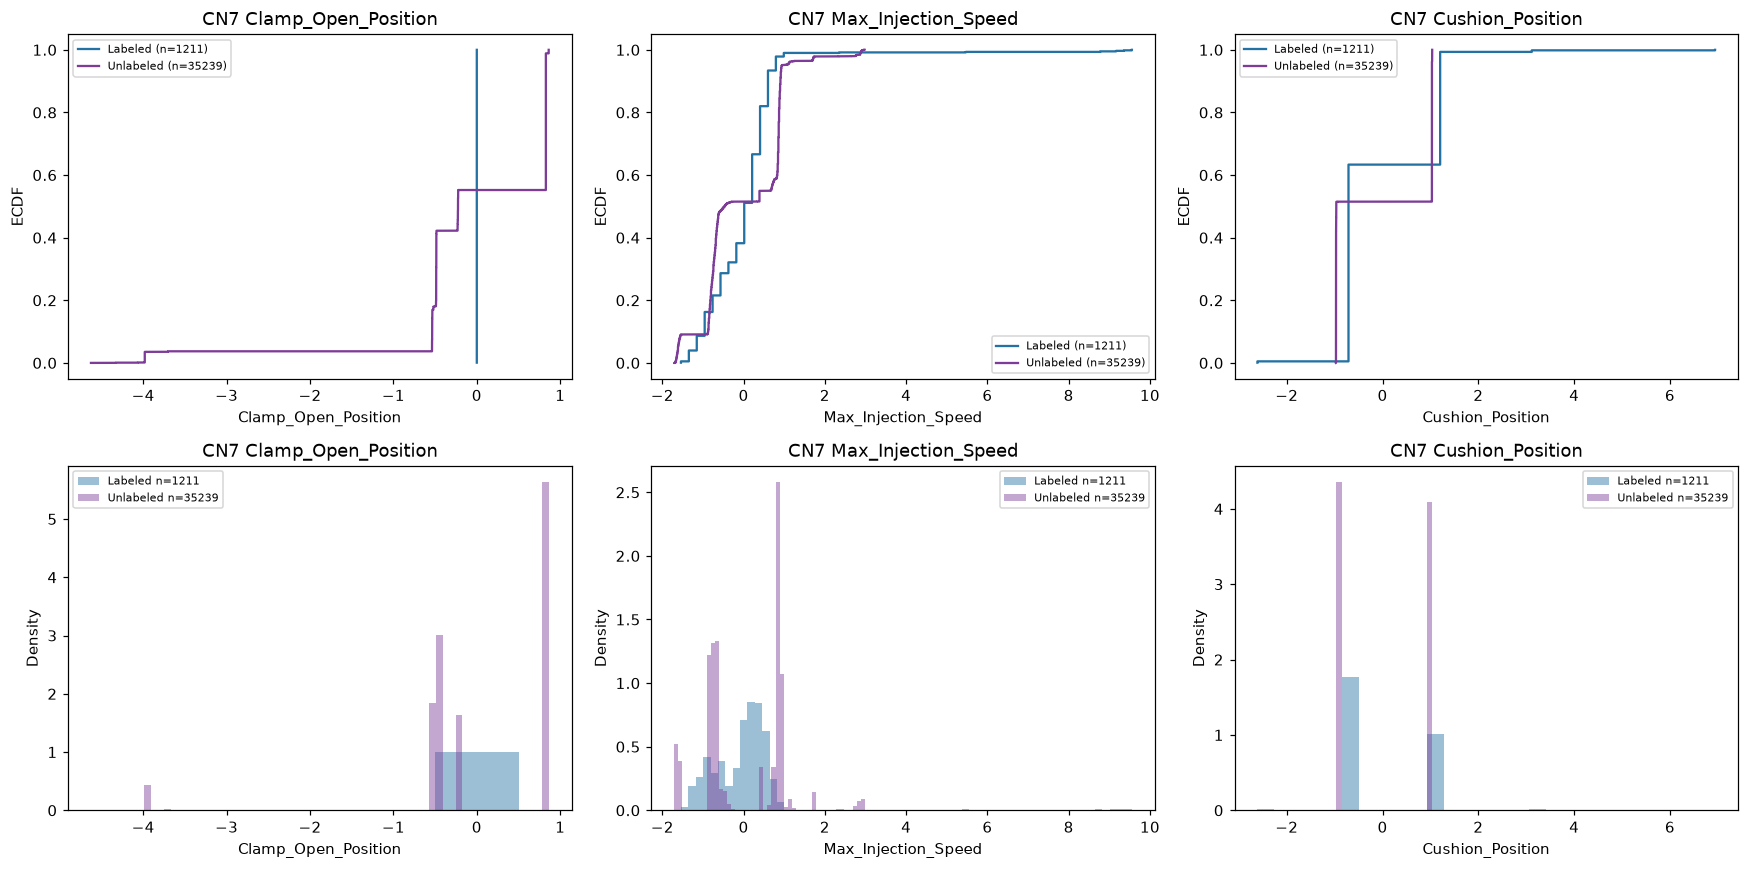

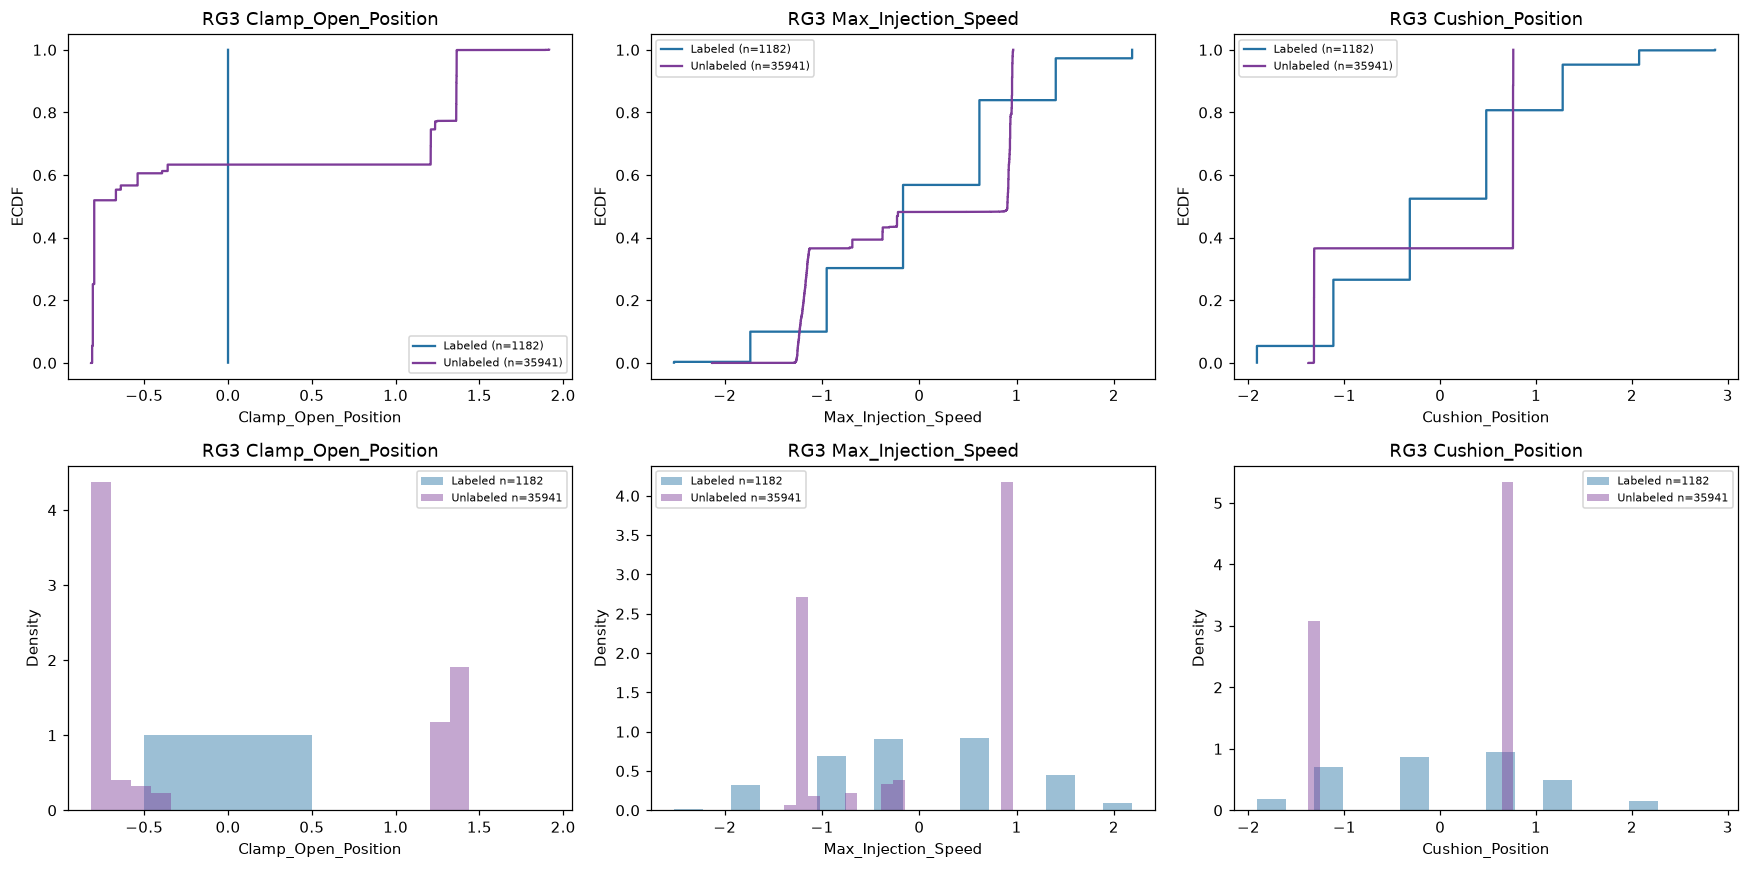

69쪽 코드에서 네 파일을 각각 표준화한다. 따라서 같은 표준화 숫자는 동일 원시 공정값을 뜻하지 않는다. Clamp_Open_Position은 라벨에서는 상수인데 비라벨에서는 변한다. 비라벨을 정상으로 취급하거나 이 차이를 공정 드리프트로 단정할 수 없다. 라벨 정상 참조로 만든 아래 변환을 비라벨에 직접 적용하지 않는다. 원시값과 파일별 평균·표준편차가 필요하다.

In [10]:
shift=[]
for p in L:
    for c in FEATURES:
        a=L[p][c];b=U[p][c]
        shift.append([p,c,a.mean(),a.std(ddof=0),a.nunique(),b.mean(),b.std(ddof=0),b.nunique(),ks_2samp(a,b).statistic,((b<a.min())|(b>a.max())).mean()])
shift_table=pd.DataFrame(shift,columns=['product','feature','L mean','L std0','L unique','U mean','U std0','U unique','KS','U outside L range']);display(shift_table)
for p in L:
    fig,axs=plt.subplots(2,3,figsize=(16,8))
    for j,c in enumerate(['Clamp_Open_Position','Max_Injection_Speed','Cushion_Position']):
        for name,d,color in [('Labeled',L[p],'#2471A3'),('Unlabeled',U[p],'#7D3C98')]:
            ecdf(axs[0,j],d[c],name,color)
            axs[1,j].hist(d[c],bins='auto',density=True,alpha=.45,color=color,label=f'{name} n={len(d)}')
        finish(axs[0,j],p+' '+c,c,'ECDF');finish(axs[1,j],p+' '+c,c,'Density')
    plt.tight_layout();plt.show()
say('69쪽 코드에서 네 파일을 각각 표준화한다. 따라서 같은 표준화 숫자는 동일 원시 공정값을 뜻하지 않는다. Clamp_Open_Position은 라벨에서는 상수인데 비라벨에서는 변한다. 비라벨을 정상으로 취급하거나 이 차이를 공정 드리프트로 단정할 수 없다. 라벨 정상 참조로 만든 아래 변환을 비라벨에 직접 적용하지 않는다. 원시값과 파일별 평균·표준편차가 필요하다.')


## 5. 공정별 직접 비교
**방법·근거:** 반올림 없는 정확 일치와 관측 정상 범위를 먼저 확인한다. 개별값 일치, 단계 조합 일치, 전체24변수 일치를 구분한다. 조건 추가에 따른 빈도 감소는 기계적으로 발생하며 그 자체는 이상 증거가 아니다.

,product,source_id,pattern_id,group,normal rows matched,normal unique matched,outside observed normal range
0,CN7,47,24,Filling,36,19,
1,CN7,47,24,Injection shared,69,36,
2,CN7,47,24,Switch,139,71,
3,CN7,47,24,Cushion,751,381,
4,CN7,47,24,Plasticizing,1,1,
...,...,...,...,...,...,...,...
331,RG3,2343,566,Cushion,245,125,
332,RG3,2343,566,Plasticizing,1,1,
333,RG3,2343,566,Full input,1,1,
334,RG3,2343,566,Filling + cushion,56,29,


,product,source_id,feature,normal rows equal,outside normal range
264,CN7,115,Injection_Time,0,False
265,CN7,115,Filling_Time,0,False
269,CN7,115,Cushion_Position,0,True
272,CN7,115,Max_Injection_Speed,0,True
275,CN7,115,Max_Injection_Pressure,0,False
288,CN7,116,Injection_Time,0,False
289,CN7,116,Filling_Time,0,False
293,CN7,116,Cushion_Position,0,True
296,CN7,116,Max_Injection_Speed,0,True
299,CN7,116,Max_Injection_Pressure,0,False


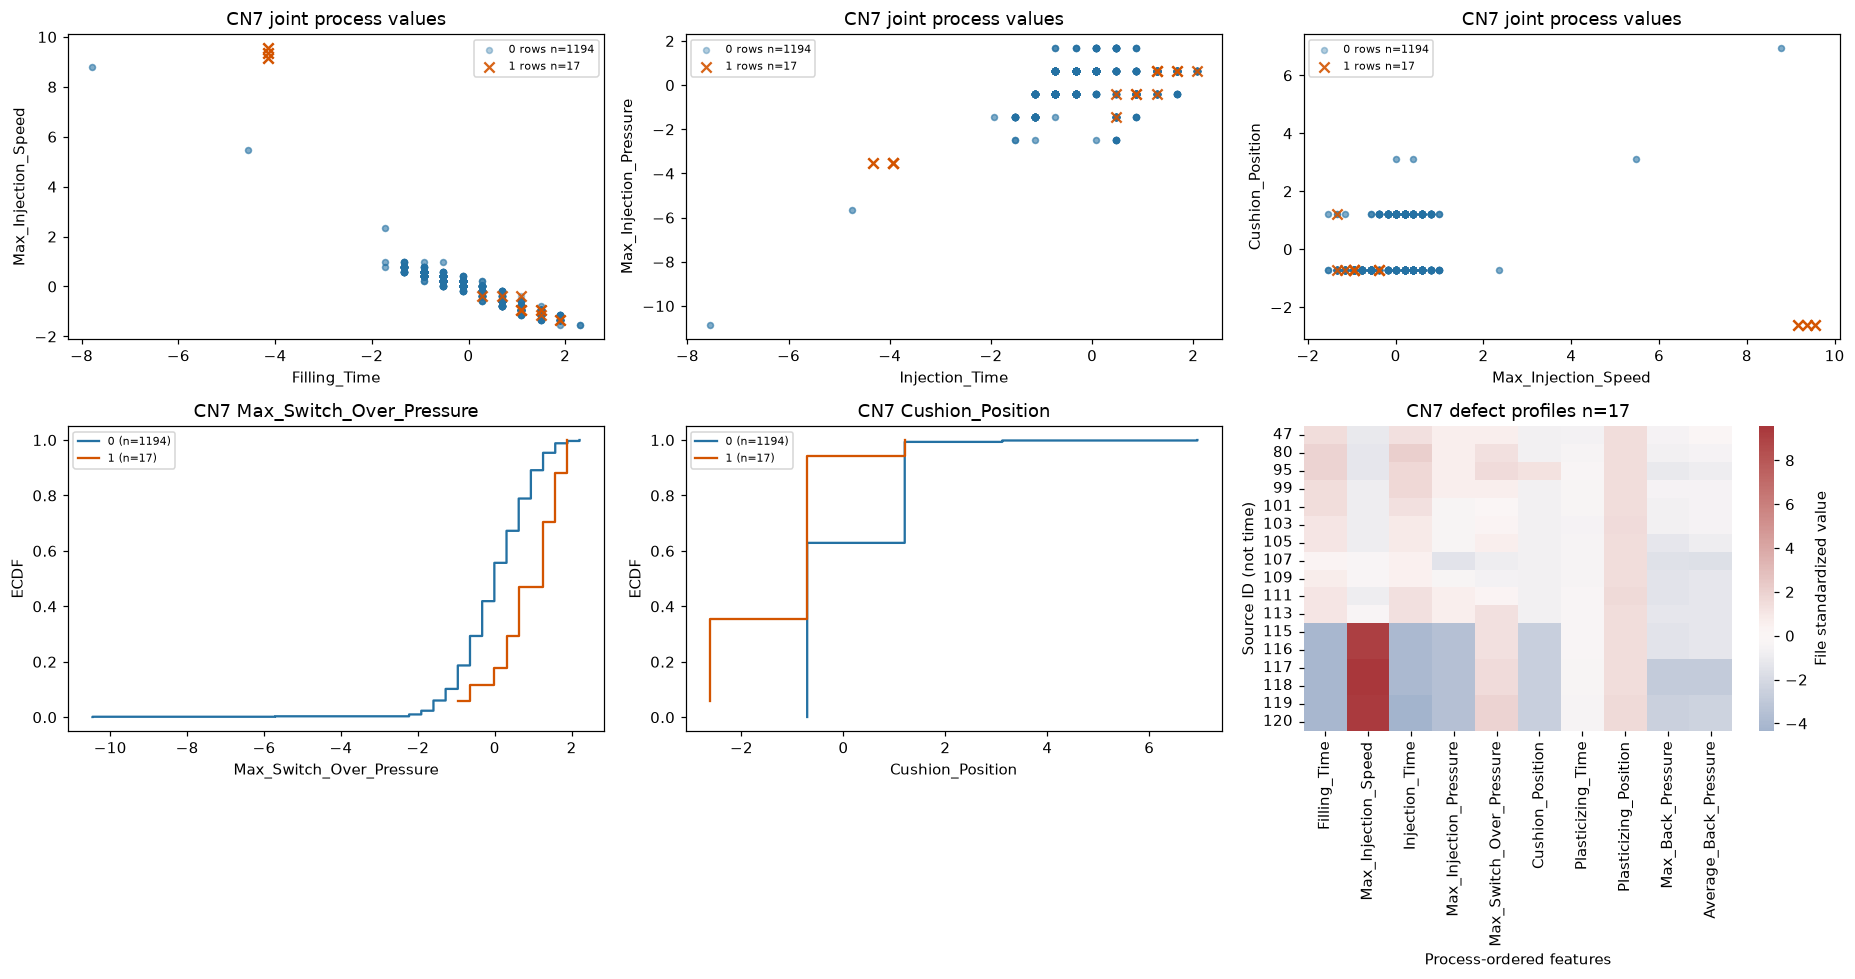

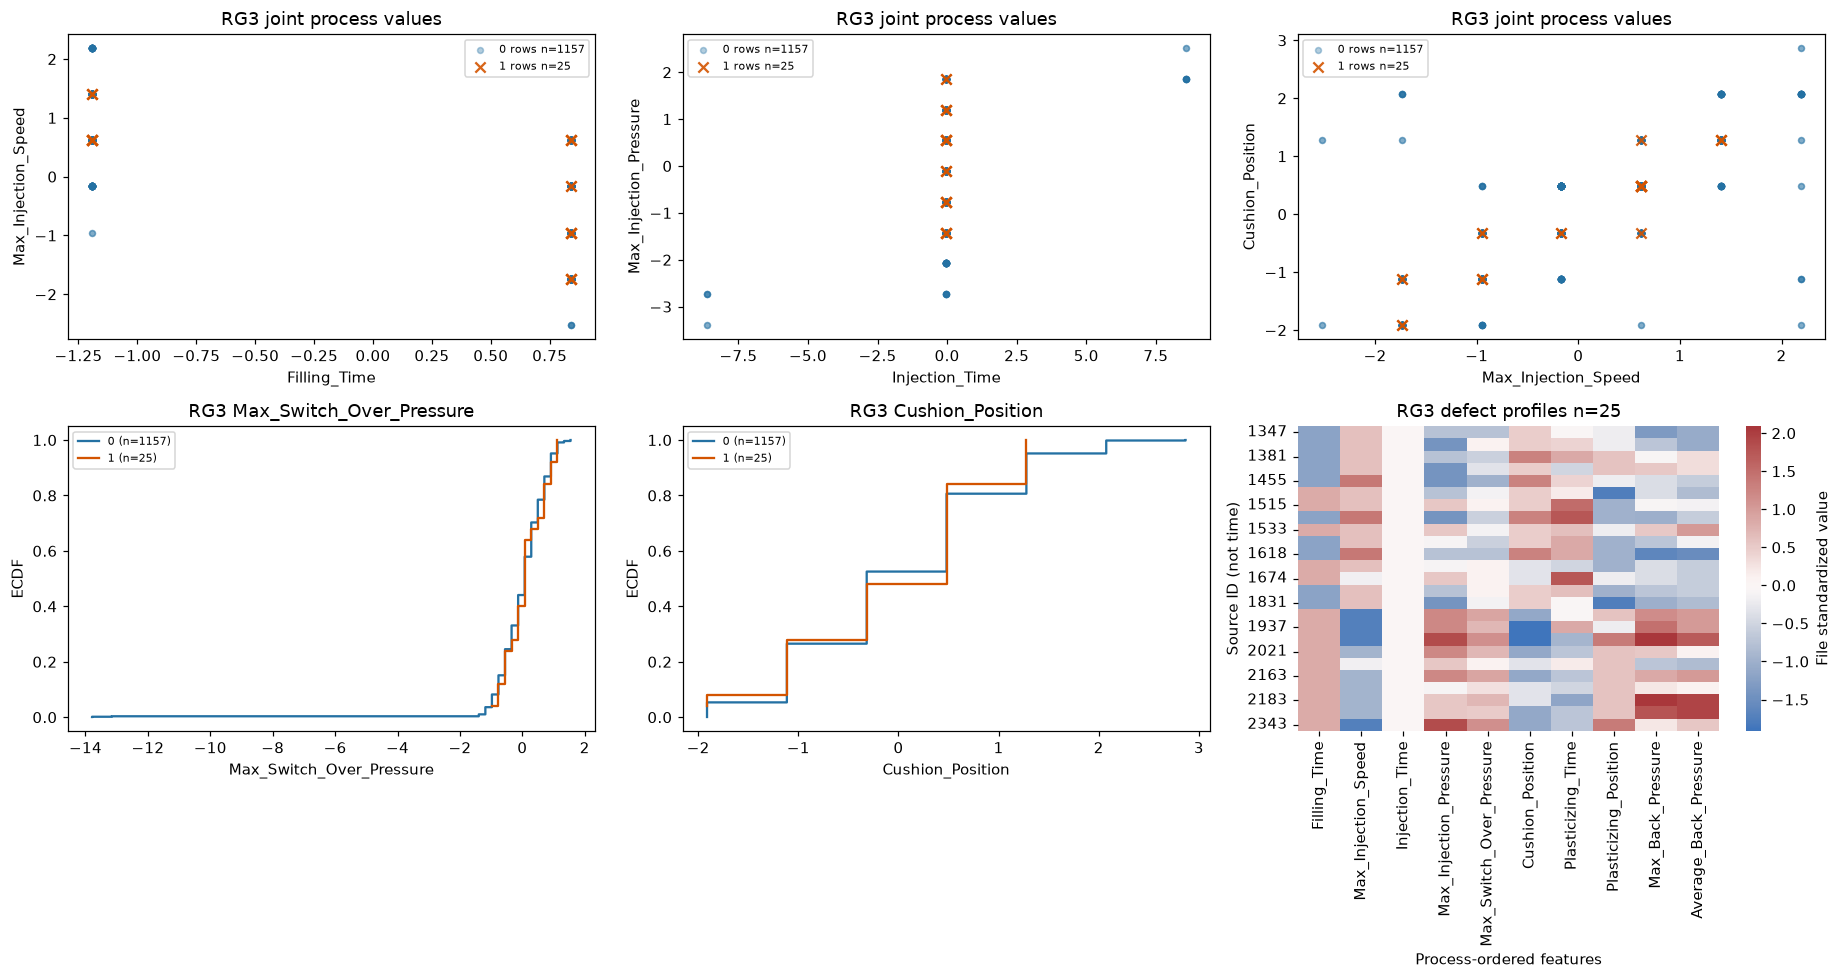

,patterns,with_match,minimum,maximum
group,,,,
Cushion,14,11,0,381
Filling,14,11,0,24
Filling + cushion,14,11,0,24
Full input,14,11,0,1
Injection shared,14,11,0,36
Plasticizing,14,12,0,5
Speed + cushion + back,14,11,0,16
Switch,14,14,5,83


,patterns,with_match,minimum,maximum
group,,,,
Cushion,25,25,32,167
Filling,25,25,35,134
Filling + cushion,25,25,15,96
Full input,25,25,1,1
Injection shared,25,25,22,149
Plasticizing,25,25,1,3
Speed + cushion + back,25,25,1,14
Switch,25,25,24,83


CN7에는 같은 전체 정상 입력이 없는 불량 패턴이 존재하지만 RG3 불량은 전체 입력이 같은 정상을 가진다. 보압 전환압력의 정상 일치는 쿠션·충전 조합의 일치와 별개다. 프로파일의 표준화 크기를 서로 다른 물리 단위의 효과 크기로 해석하지 않는다.

In [11]:
direct=[]; individual=[]
for p,d in L.items():
    normals=d[d.PassOrFail.eq(0)]; unique=NORMAL[p]
    for _,b in d[d.PassOrFail.eq(1)].iterrows():
        outside=[c for c in FEATURES if b[c]<normals[c].min() or b[c]>normals[c].max()]
        for c in FEATURES:
            individual.append([p,b.source_id,c,int(normals[c].eq(b[c]).sum()),c in outside])
        for group,cs in {**GROUPS,'Full input':FEATURES,'Filling + cushion':GROUPS['Filling']+['Cushion_Position'],'Speed + cushion + back':['Max_Injection_Speed','Cushion_Position','Average_Back_Pressure']}.items():
            direct.append([p,b.source_id,b.pattern_id,group,int(normals[cs].eq(b[cs]).all(axis=1).sum()),int(unique[cs].eq(b[cs]).all(axis=1).sum()),', '.join(outside)])
direct_table=pd.DataFrame(direct,columns=['product','source_id','pattern_id','group','normal rows matched','normal unique matched','outside observed normal range'])
individual_table=pd.DataFrame(individual,columns=['product','source_id','feature','normal rows equal','outside normal range'])
display(direct_table);display(individual_table[individual_table['normal rows equal'].eq(0)])
for p,d in L.items():
    fig,axs=plt.subplots(2,3,figsize=(17,9))
    for ax,(x,y) in zip(axs.flat,[('Filling_Time','Max_Injection_Speed'),('Injection_Time','Max_Injection_Pressure'),('Max_Injection_Speed','Cushion_Position')]):
        for label in [0,1]:
            g=d[d.PassOrFail.eq(label)];ax.scatter(g[x],g[y],c=COLORS[label],alpha=.35 if label==0 else .9,s=15 if label==0 else 45,marker='o' if label==0 else 'x',label=f'{label} rows n={len(g)}')
        finish(ax,p+' joint process values',x,y)
    for ax,c in zip(axs.flat[3:5],['Max_Switch_Over_Pressure','Cushion_Position']):
        for label in [0,1]:ecdf(ax,d[d.PassOrFail.eq(label)][c],str(label),COLORS[label])
        finish(ax,p+' '+c,c,'ECDF')
    ax=axs.flat[5];g=d[d.PassOrFail.eq(1)];cs=sum([GROUPS[x] for x in ['Filling','Injection shared','Switch','Cushion','Plasticizing']],[])
    sns.heatmap(g.set_index('source_id')[cs],ax=ax,cmap='vlag',center=0,cbar_kws={'label':'File standardized value'})
    ax.set(title=f'{p} defect profiles n={len(g)}',xlabel='Process-ordered features',ylabel='Source ID (not time)')
    plt.tight_layout();plt.show()
for p in L:
    t=direct_table[direct_table['product'].eq(p)].drop_duplicates(['pattern_id','group'])
    display(t.groupby('group')['normal unique matched'].agg(patterns='size',with_match=lambda x:int((x>0).sum()),minimum='min',maximum='max'))
say('CN7에는 같은 전체 정상 입력이 없는 불량 패턴이 존재하지만 RG3 불량은 전체 입력이 같은 정상을 가진다. 보압 전환압력의 정상 일치는 쿠션·충전 조합의 일치와 별개다. 프로파일의 표준화 크기를 서로 다른 물리 단위의 효과 크기로 해석하지 않는다.')


## 6. 거리 보조 분석: 설정의 안정성과 국소성
**목적·가정:** 정확 일치로 설명하기 어려운 2변수 충전·사출 공통 조합에만 적용한다. 단일 전환/쿠션에 독립 다변량 단계 점수를 만들지 않는다.

후보는 표준편차 스케일 Euclidean, IQR 스케일 Euclidean, IQR Manhattan이다. IQR=0은 참조 표준편차로 대체하며 상수는 스케일 1로 둔다. 상관계수가 큰 경우 유클리드 거리의 정보 중복 가능성을 보고한다. 정상 고유 입력 25%를 공통 점검용으로 고정하고 나머지의 80%를 반복 참조한다. 이 비율은 성능 최적화가 아닌 참조 변동 실험의 계산 설계다.

k=1은 가장 가까운 관측 패턴이라는 직접 의미가 있다. 2부터 √참조크기까지 로그 간격 후보는 단일 사례에서 더 넓은 국소범위로 확장하는 탐색 범위다. k 선택은 불량 분리가 아닌 정상 점검점의 점수 변동·순위 안정성·k번째 이웃 거리 확장으로 검토한다. 12회는 계산 예산이며 6회 요약과 비교한다. 최적 k나 정상/이상 임계값은 선언하지 않는다.

CN7 Filling: 정상 고유 603, 점검 150, 반복 참조 362, k=[1, 2, 4, 6, 11, 19]; 상관=-0.953

CN7 Injection shared: 정상 고유 603, 점검 150, 반복 참조 362, k=[1, 2, 4, 6, 11, 19]; 상관=0.440

RG3 Filling: 정상 고유 591, 점검 147, 반복 참조 355, k=[1, 2, 3, 6, 10, 18]; 상관=-0.750

RG3 Injection shared: 정상 고유 591, 점검 147, 반복 참조 355, k=[1, 2, 3, 6, 10, 18]; 상관=0.274

,product,group,geometry,k,rank stability 12,rank stability 6,score SD median,radius median,nearest tie rate,valid rank comparisons,total rank comparisons
0,CN7,Filling,std_euclidean,1,1.000000,1.000000,0.000000,0.000000,0.969444,66,66
1,CN7,Filling,std_euclidean,2,0.821988,0.716768,0.000000,0.000000,0.969444,66,66
2,CN7,Filling,std_euclidean,4,0.862904,0.866125,0.000000,0.000000,0.969444,66,66
3,CN7,Filling,std_euclidean,6,0.995543,0.981114,0.000000,0.000000,0.969444,66,66
4,CN7,Filling,std_euclidean,11,0.871849,0.871182,0.000000,0.000000,0.969444,66,66
5,CN7,Filling,std_euclidean,19,0.959127,0.969605,0.019831,0.247844,0.969444,66,66
6,CN7,Filling,iqr_euclidean,1,1.000000,1.000000,0.000000,0.000000,0.969444,66,66
7,CN7,Filling,iqr_euclidean,2,0.821988,0.716768,0.000000,0.000000,0.969444,66,66
8,CN7,Filling,iqr_euclidean,4,0.862812,0.866170,0.000000,0.000000,0.969444,66,66
9,CN7,Filling,iqr_euclidean,6,0.995533,0.981055,0.000000,0.000000,0.969444,66,66


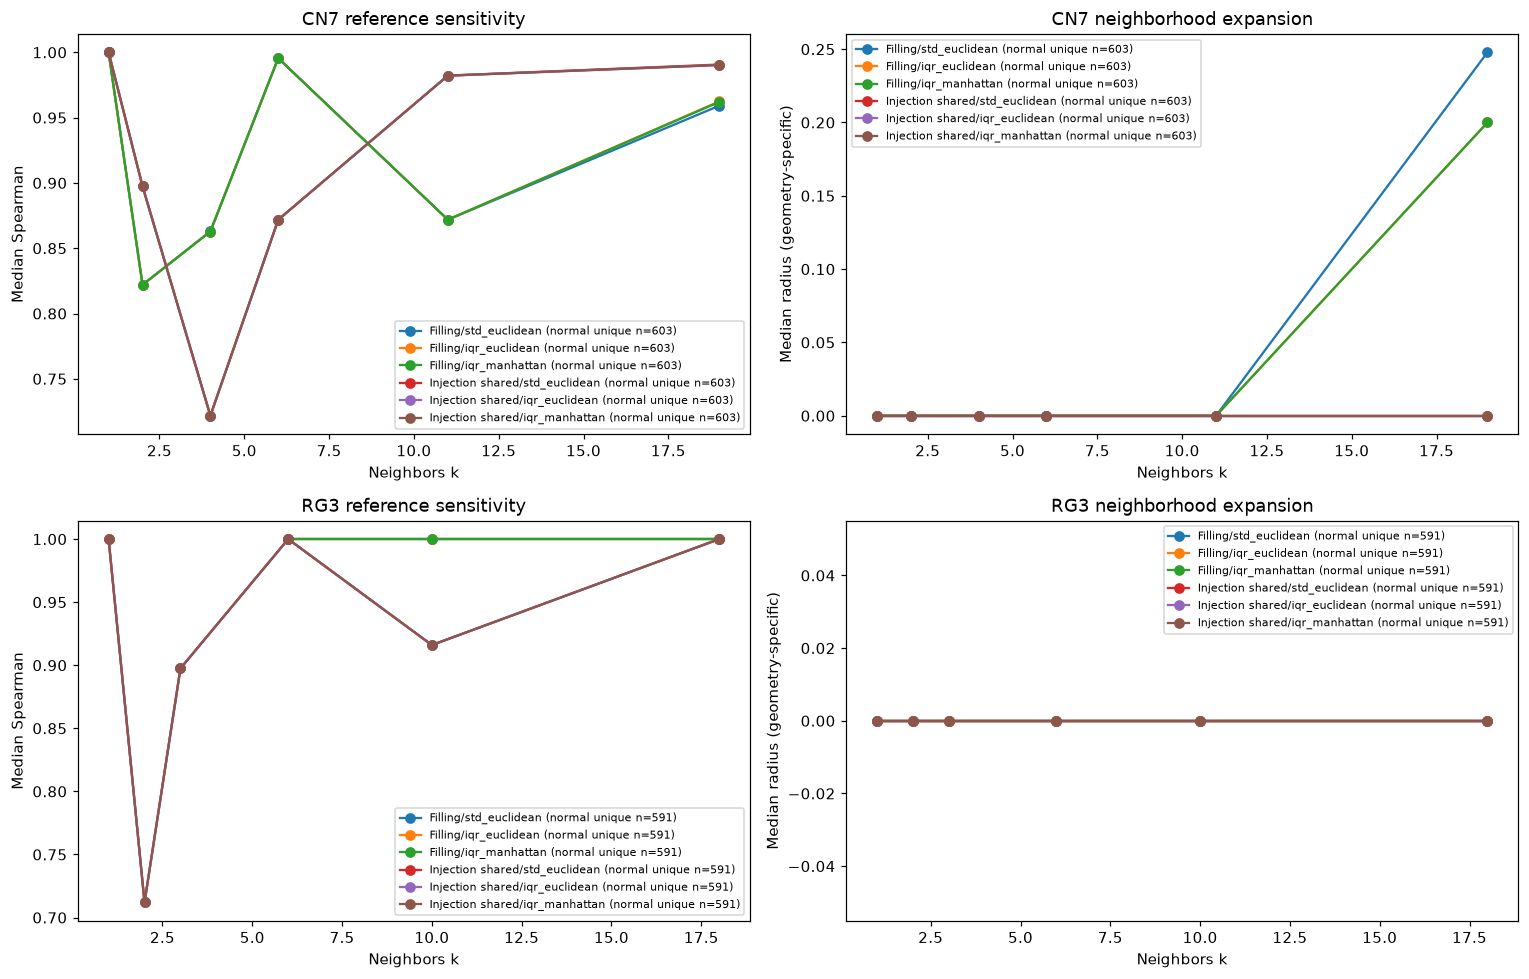

순위 안정성이 좋아져도 이웃 반경 확대는 국소성 감소를 뜻한다. 서로 다른 거리 척도의 반경 절댓값을 직접 비교하지 않는다. 위 정상 점검 실험은 설정 민감도 진단이며 결함 탐지 성능 검증이 아니다. 후속 파생변수는 해석이 명확한 최근접 거리(k=1)를 설명용으로 두고 k 변화는 계속 병기한다.

동일한 단계 조합이 반복되어 점수가 상수이면 순위 상관은 정의되지 않는다. valid rank comparisons가 적거나 0인 후보는 높은 유효 상관값만으로 안정적이라고 판단하지 않는다. 전체 입력 패턴은 분리했지만 단계 부분조합은 양쪽에 존재할 수 있다.

In [12]:
def distance_matrix(ref,query,cols,mode='iqr_euclidean'):
    r=ref[cols].to_numpy(float);q=query[cols].to_numpy(float)
    if mode=='std_euclidean': scale=np.std(r,axis=0)
    else: scale=np.quantile(r,.75,axis=0)-np.quantile(r,.25,axis=0)
    fallback=np.std(r,axis=0);scale=np.where(scale>0,scale,np.where(fallback>0,fallback,1.))
    return cdist(q/scale,r/scale,metric='cityblock' if 'manhattan' in mode else 'euclidean')
stability=[]; distance_runs={}
for p in L:
    normal=NORMAL[p]; perm=np.random.default_rng(SEED).permutation(len(normal)); nq=max(2,len(normal)//4)
    query=normal.iloc[perm[:nq]]; pool=normal.iloc[perm[nq:]];nr=int(.8*len(pool))
    ks=sorted(set([1]+np.geomspace(2,max(2,int(np.sqrt(nr))),5).round().astype(int).tolist()))
    for group in ['Filling','Injection shared']:
        cols=GROUPS[group];say(f'{p} {group}: 정상 고유 {len(normal)}, 점검 {nq}, 반복 참조 {nr}, k={ks}; 상관={normal[cols].corr().iloc[0,1]:.3f}')
        for mode in ['std_euclidean','iqr_euclidean','iqr_manhattan']:
            scores=[];radii=[];ties=[]
            for rep in range(REPEATS):
                ref=pool.sample(nr,random_state=SEED+rep)
                assert not set(query.pattern_id)&set(ref.pattern_id)
                ds=np.sort(distance_matrix(ref,query,cols,mode),axis=1)
                scores.append(np.column_stack([ds[:,:k].mean(axis=1) for k in ks]));radii.append(np.column_stack([ds[:,k-1] for k in ks]))
                ties.append(np.mean(np.isclose(ds[:,0],ds[:,1])))
            a=np.array(scores); rr=np.array(radii);distance_runs[p,group,mode]=(ks,a,rr)
            for j,k in enumerate(ks):
                corr=[safe_corr(a[x,:,j],a[y,:,j]) for x in range(REPEATS) for y in range(x)]
                corr6=[safe_corr(a[x,:,j],a[y,:,j]) for x in range(min(6,REPEATS)) for y in range(x)]
                stability.append([p,group,mode,k,finite_median(corr),finite_median(corr6),np.median(a[:,:,j].std(axis=0)),np.median(rr[:,:,j]),np.mean(ties),int(np.isfinite(corr).sum()),len(corr)])
stability_table=pd.DataFrame(stability,columns=['product','group','geometry','k','rank stability 12','rank stability 6','score SD median','radius median','nearest tie rate','valid rank comparisons','total rank comparisons']);display(stability_table)
fig,axs=plt.subplots(2,2,figsize=(14,9))
for i,p in enumerate(L):
    for group in ['Filling','Injection shared']:
        for mode in ['std_euclidean','iqr_euclidean','iqr_manhattan']:
            t=stability_table.query('product==@p and group==@group and geometry==@mode')
            label=f'{group}/{mode} (normal unique n={len(NORMAL[p])})'
            axs[i,0].plot(t.k,t['rank stability 12'],marker='o',label=label);axs[i,1].plot(t.k,t['radius median'],marker='o',label=label)
    finish(axs[i,0],p+' reference sensitivity','Neighbors k','Median Spearman');finish(axs[i,1],p+' neighborhood expansion','Neighbors k','Median radius (geometry-specific)')
plt.tight_layout();plt.show()
say('순위 안정성이 좋아져도 이웃 반경 확대는 국소성 감소를 뜻한다. 서로 다른 거리 척도의 반경 절댓값을 직접 비교하지 않는다. 위 정상 점검 실험은 설정 민감도 진단이며 결함 탐지 성능 검증이 아니다. 후속 파생변수는 해석이 명확한 최근접 거리(k=1)를 설명용으로 두고 k 변화는 계속 병기한다.')

say('동일한 단계 조합이 반복되어 점수가 상수이면 순위 상관은 정의되지 않는다. valid rank comparisons가 적거나 0인 후보는 높은 유효 상관값만으로 안정적이라고 판단하지 않는다. 전체 입력 패턴은 분리했지만 단계 부분조합은 양쪽에 존재할 수 있다.')


## 7. CN7 사례와 보조 조건
**방법:** 모든 불량을 계산한 뒤 요청한 ID를 표시한다. 온도 비교는 정의가 확인된 Barrel1–6·Hopper를 기준으로 하고 Mold3–4 포함 여부를 비교한다. m 후보는 정상 고유 수의 제곱근 전후(절반·1배·2배)로 국소 비교군 폭을 탐색한다. 정상의 leave-one-pattern-out 온도 m번째 거리 분포와 불량의 거리를 비교한다. 이는 정상 규격이 아니라 비교군 적합성의 상대 지표다. 사출/배압 차이가 커지는 m을 선택하지 않는다.

상충 불량에는 동일한 정상 전체입력이 온도 비교군에 포함될 수 있어 반경이 작아질 수 있다. 이 포함 결과를 우선 제시한 것이며, 정상의 자기제외 반경과 완전히 동일한 평가 조건은 아니다. 해당 상대위치를 독립적인 적합성 검증이나 불량확률로 사용하지 않는다.

,source_id,pattern_id,PassOrFail,Filling_Time,Max_Injection_Speed,Injection_Time,Max_Injection_Pressure,Max_Switch_Over_Pressure,Cushion_Position,Plasticizing_Time,Plasticizing_Position,Max_Back_Pressure,Average_Back_Pressure,Cycle_Time
95,95,48,1,1.894372,-1.347095,1.679123,0.635210,1.573231,1.202502,-0.330766,1.471608,-1.092607,-0.914898,0.361047
103,103,52,1,1.088442,-0.957708,0.876653,-0.409975,0.306281,-0.711164,-0.576184,1.532018,-0.740752,-0.533773,0.361047
107,107,54,1,0.282513,-0.373631,0.475456,-1.455001,-0.960670,-0.711164,-0.478017,1.471608,-1.620386,-1.677161,0.361047
113,113,57,1,1.088442,-0.373631,1.277888,0.635210,1.256518,-0.711164,-0.281692,1.471608,-1.268531,-1.296037,0.361047
115,115,58,1,-4.150108,9.166316,-3.938052,-3.545372,1.256518,-2.613163,-0.281692,1.471608,-1.444462,-1.296037,1.886261
116,116,58,1,-4.150108,9.166316,-3.938052,-3.545372,1.256518,-2.613163,-0.281692,1.471608,-1.444462,-1.296037,1.886261
117,117,59,1,-4.150108,9.555703,-3.938052,-3.545372,1.573231,-2.613163,-0.428933,1.471608,-2.851876,-2.820549,-2.180975
118,118,59,1,-4.150108,9.555703,-3.938052,-3.545372,1.573231,-2.613163,-0.428933,1.471608,-2.851876,-2.820549,-2.180975
119,119,60,1,-4.150108,9.361006,-4.339287,-3.545372,1.889993,-2.613163,-0.478017,1.592429,-2.500021,-2.439425,-1.672571
120,120,60,1,-4.150108,9.361006,-4.339287,-3.545372,1.889993,-2.613163,-0.478017,1.592429,-2.500021,-2.439425,-1.672571


,product,source_id,pattern_id,group,normal rows matched,normal unique matched,outside observed normal range
16,CN7,95,48,Filling,30,16,
17,CN7,95,48,Injection shared,55,29,
18,CN7,95,48,Switch,41,21,
19,CN7,95,48,Cushion,435,218,
20,CN7,95,48,Plasticizing,3,2,
21,CN7,95,48,Full input,1,1,
22,CN7,95,48,Filling + cushion,3,2,
23,CN7,95,48,Speed + cushion + back,1,1,
40,CN7,103,52,Filling,45,24,
41,CN7,103,52,Injection shared,68,35,


,product,source_id,include ambiguous mold,m,temperature radius,normal radius percentile,boundary tie count,speed median contrast,cushion median contrast,back median contrast
0,CN7,47,False,12,0.995871,0.041459,1,-1.362843,-0.956833,-0.762249
1,CN7,80,False,12,1.378704,0.567164,1,-0.778774,0.000000,0.571694
2,CN7,95,False,12,2.402185,0.993367,1,-1.460196,0.956833,-1.143388
3,CN7,99,False,12,1.373589,0.562189,1,-0.973464,-1.913667,-0.762264
4,CN7,101,False,12,1.366834,0.552239,1,-0.292038,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
229,RG3,2163,True,48,1.608112,0.072758,1,0.000000,-0.398691,0.116248
230,RG3,2177,True,48,2.079374,0.620981,1,-0.784909,0.000000,-0.232496
231,RG3,2183,True,48,1.744700,0.203046,1,0.000000,0.797381,0.813749
232,RG3,2331,True,48,2.047145,0.575296,1,-0.784909,-0.797381,1.162498


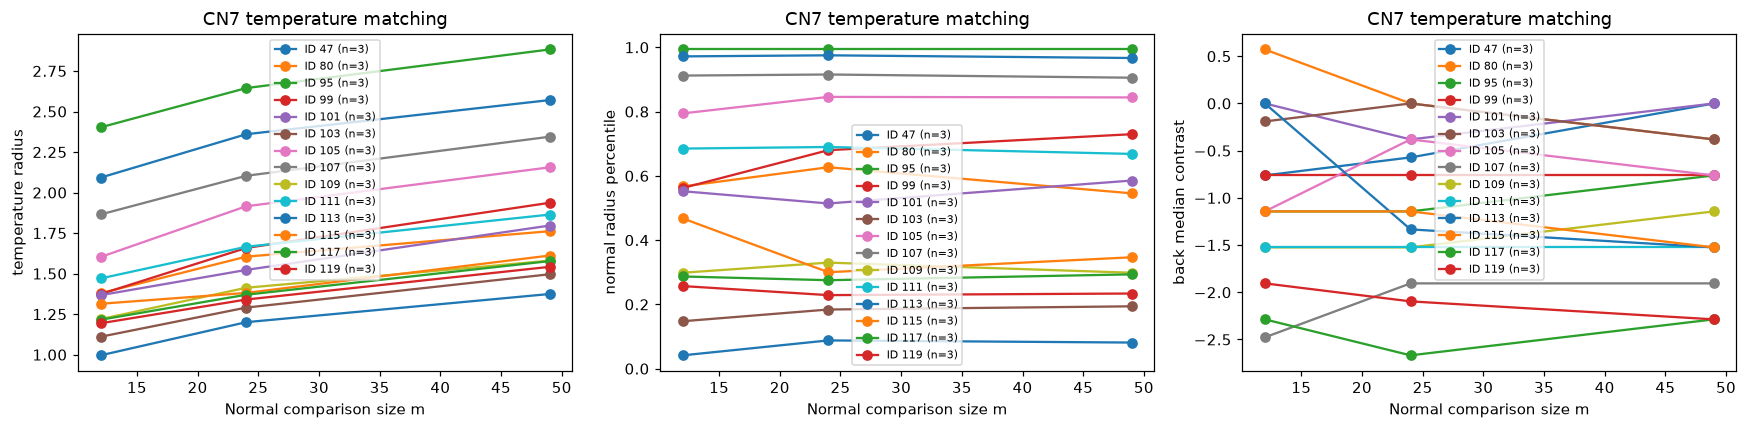

m 증가에 따른 온도 반경과 차이 변동을 함께 읽어야 한다. 정상 반경 분포 바깥이면 비교 가능한 정상 부족의 정황으로 기록하며, 안쪽이라고 공정 조건 동등성을 확정하지 않는다. 동률 경계에서는 안정 정렬 순서가 비교군 구성을 바꿀 수 있다. 따라서 조건부 지표는 이번 파생변수 입력 후보에서 보류한다. 속도·쿠션·배압의 동반 차이는 독립 영향이나 이상 전파를 증명하지 않는다.

In [13]:
ids=[95,103,107,113,115,116,117,118,119,120]
display(L['CN7'].loc[L['CN7'].source_id.isin(ids),['source_id','pattern_id','PassOrFail']+sum(GROUPS.values(),[])+['Cycle_Time']])
display(direct_table[(direct_table['product']=='CN7')&direct_table.source_id.isin(ids)])
conditional=[]
for p in L:
    ref=NORMAL[p];bad=BAD[p];ms=sorted(set(max(2,int(np.sqrt(len(ref))*f)) for f in [.5,1,2]))
    for include_mold in [False,True]:
        cs=THERMAL+(['Mold_Temperature_3','Mold_Temperature_4'] if include_mold else [])
        dd=distance_matrix(ref,bad,cs);nn=distance_matrix(ref,ref,cs);np.fill_diagonal(nn,np.inf)
        for m in ms:
            nr=np.sort(nn,axis=1)[:,m-1]
            for j,(_,b) in enumerate(bad.iterrows()):
                order=np.argsort(dd[j],kind='stable')[:m];g=ref.iloc[order];radius=dd[j,order[-1]]
                conditional.append([p,b.source_id,include_mold,m,radius,np.mean(nr<=radius),int(np.isclose(dd[j],radius).sum()),b.Max_Injection_Speed-g.Max_Injection_Speed.median(),b.Cushion_Position-g.Cushion_Position.median(),b.Average_Back_Pressure-g.Average_Back_Pressure.median()])
conditional_table=pd.DataFrame(conditional,columns=['product','source_id','include ambiguous mold','m','temperature radius','normal radius percentile','boundary tie count','speed median contrast','cushion median contrast','back median contrast']);display(conditional_table)
fig,axs=plt.subplots(1,3,figsize=(16,4))
t=conditional_table.query("product=='CN7' and `include ambiguous mold`==False")
for ax,c in zip(axs,['temperature radius','normal radius percentile','back median contrast']):
    for sid,g in t.groupby('source_id'): ax.plot(g.m,g[c],marker='o',label=f'ID {sid} (n={len(g)})')
    finish(ax,'CN7 temperature matching', 'Normal comparison size m',c)
plt.tight_layout();plt.show()
say('m 증가에 따른 온도 반경과 차이 변동을 함께 읽어야 한다. 정상 반경 분포 바깥이면 비교 가능한 정상 부족의 정황으로 기록하며, 안쪽이라고 공정 조건 동등성을 확정하지 않는다. 동률 경계에서는 안정 정렬 순서가 비교군 구성을 바꿀 수 있다. 따라서 조건부 지표는 이번 파생변수 입력 후보에서 보류한다. 속도·쿠션·배압의 동반 차이는 독립 영향이나 이상 전파를 증명하지 않는다.')


### 보조 조건 및 온도 비교군의 실제 점검 결과
**방법:** 계량·배압·사이클·금형 동작·불명확 RPM/금형온도를 불량 개별 점과 함께 비교한다. 모호한 측정값은 별도 열에 유지하고 충전·가압·보압 증거로 사용하지 않는다. 온도 비교군 적합성은 정상 자기제외 반경 분포를 기준으로 연속적으로 보고한다.

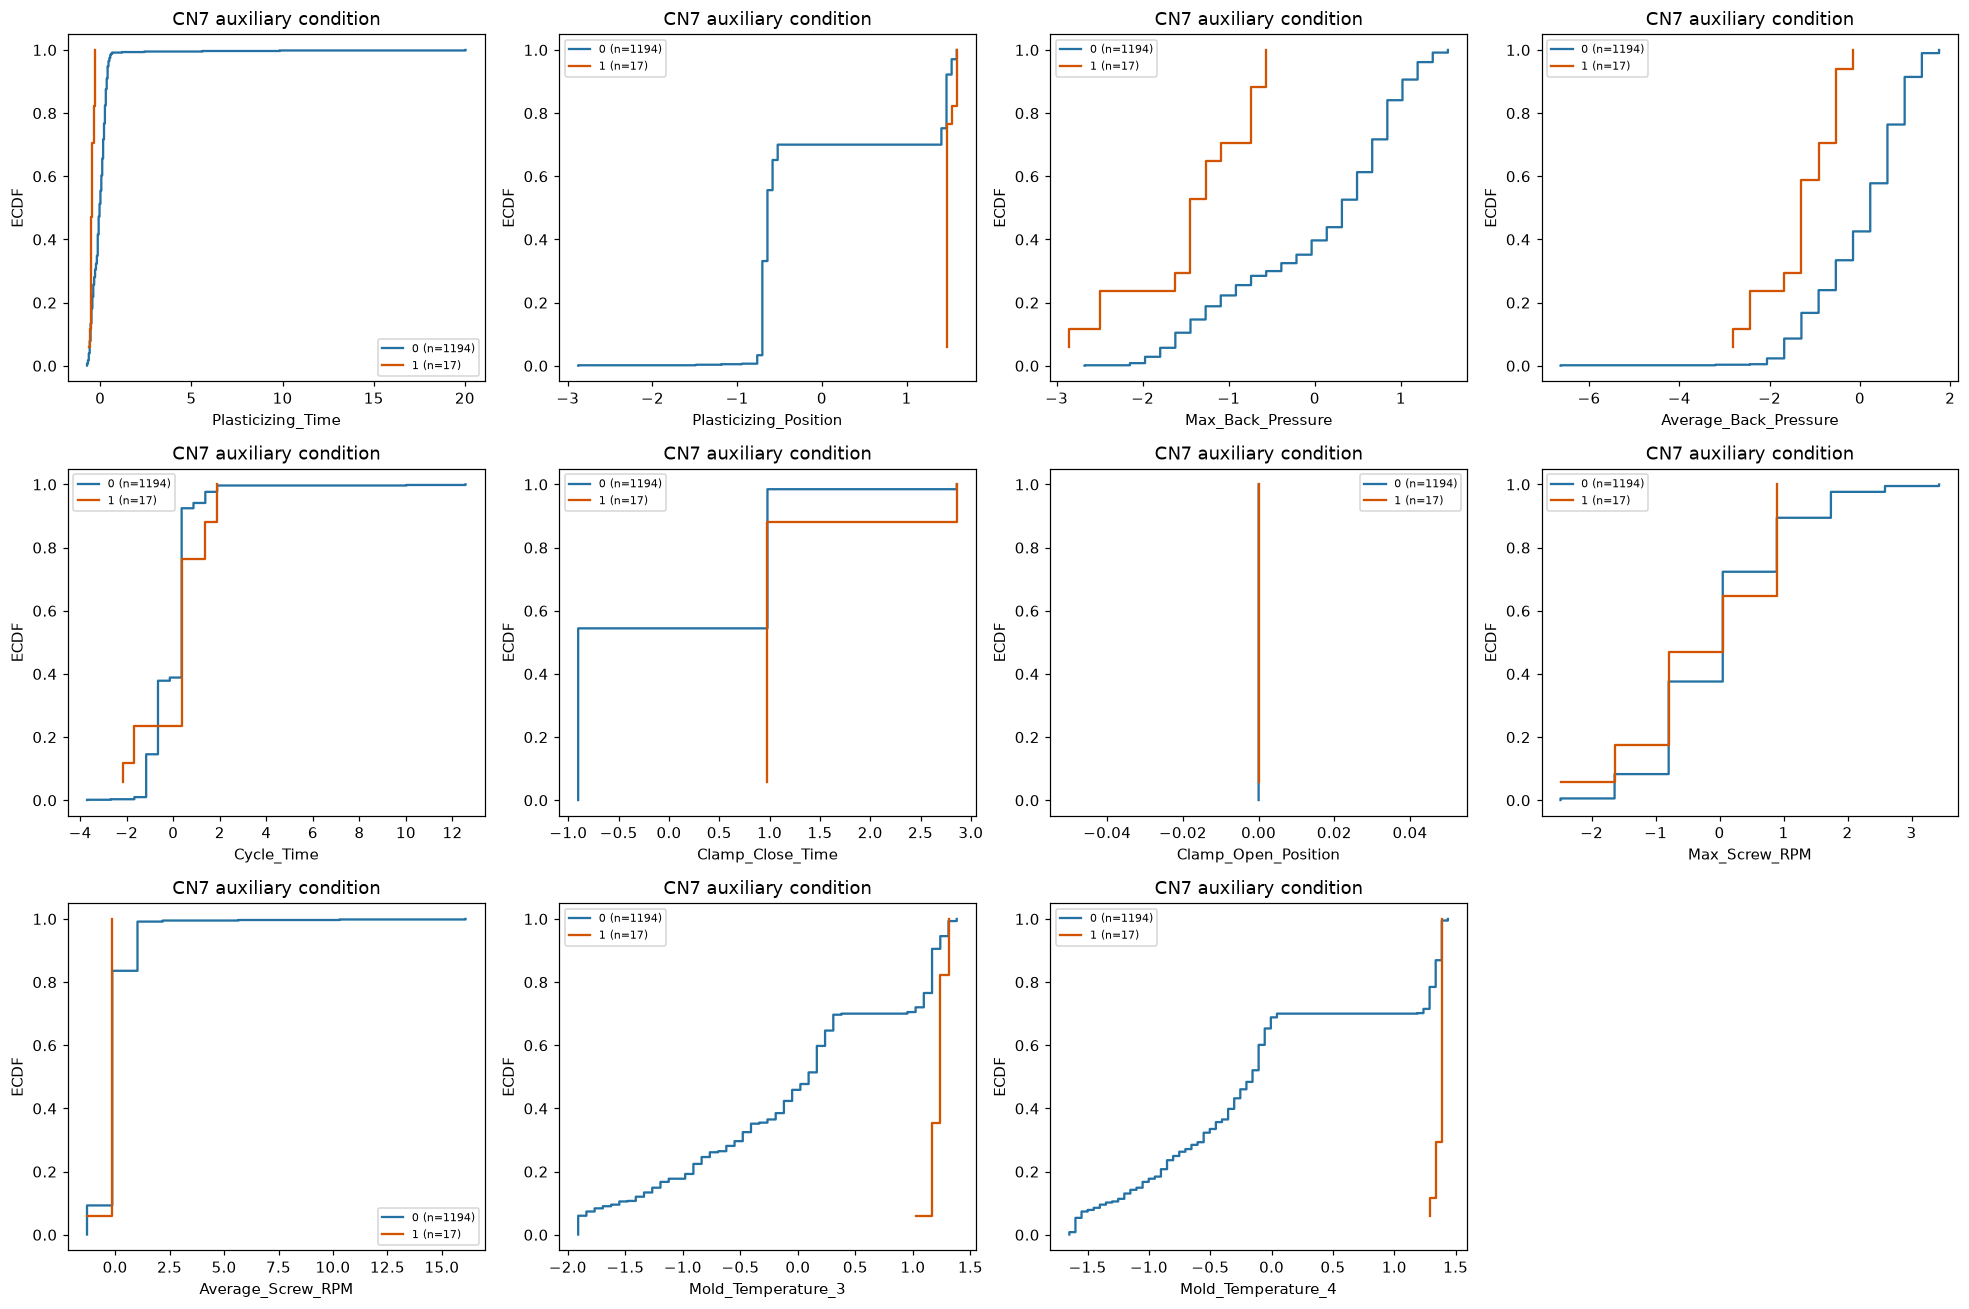

CN7, 모호한 금형온도 포함=False: 정상 반경 상대위치의 전체 범위 0.041–0.993. m 변경에 따른 사례별 상대위치 최대 변화 0.167.

정상 점검 반경의 최댓값 이상인 사례(하나 이상의 m): []. 이 경우 비교 가능한 정상 부족의 정황으로 보고하며 차이를 단정하지 않는다.

CN7, 모호한 금형온도 포함=True: 정상 반경 상대위치의 전체 범위 0.111–0.997. m 변경에 따른 사례별 상대위치 최대 변화 0.177.

정상 점검 반경의 최댓값 이상인 사례(하나 이상의 m): []. 이 경우 비교 가능한 정상 부족의 정황으로 보고하며 차이를 단정하지 않는다.

back median contrast           cushion median contrast  \
include ambiguous mold                False     True                    False   
source_id m                                                                     
47        12                      -0.762249  0.762264               -0.956833   
          24                      -0.571687  0.762264               -0.956833   
          49                       0.000000  0.762264                0.000000   
80        12                       0.571694  0.571694                0.000000   
          24                       0.000000  0.381124                0.000000   
          49                      -0.381139  0.762264                0.000000   
95        12                      -1.143388 -0.190562                0.956833   
          24                      -1.143388 -0.381124                1.913667   
          49                      -0.762264 -0.381124                1.913667   
99        12                      -0.762264  0.381124               -1.913667   
          24                      -0.762264  0.190562               -1.913667   
          49                      -0.762264  0.000000               -1.913667   
101       12                       0.000000  0.571694                0.000000   
          24                      -0.381132  0.381124                0.000000   
          49                       0.000000  0.381124                0.000000   
103       12                      -0.190570  0.762264                0.000000   
          24                       0.000000  0.381124                0.000000   
          49                      -0.381139  0.381124                0.000000   
105       12                      -1.143388  0.000000                0.000000   
          24                      -0.381124  0.000000                0.000000   
          49                      -0.762264  0.000000                0.000000   
107       12                      -2.477346 -0.571694               -0.956833   
          24                      -1.905652 -1.143388                0.000000   
          49                      -1.905652 -1.524527                0.000000   
109       12                      -1.524527  0.190562               -0.956833   
          24                      -1.524527  0.000000               -0.956833   
          49                      -1.143403 -0.381139                0.000000   
111       12                      -1.524527  0.000000                0.000000   
          24                      -1.524527 -0.190570               -0.956833   
          49                      -1.524527 -0.381139                0.000000   
113       12                       0.000000  0.000000                0.000000   
          24                      -1.333965  0.000000                0.000000   
          49                      -1.524527 -0.381139                0.000000   
115       12                      -1.143403 -0.190570               -3.815665   
          24                      -1.143403 -0.381139               -3.815665   
          49                      -1.524527 -0.762264               -1.901998   
117       12                      -2.286776 -1.905652               -1.901998   
          24                      -2.667908 -1.905652               -1.901998   
          49                      -2.286776 -1.905652               -1.901998   
119       12                      -1.905652 -1.715089               -1.901998   
          24                      -2.096221 -1.524527               -1.901998   
          49                      -2.286791 -1.524527               -1.901998   

                                 speed median contrast             \
include ambiguous mold     True                  False      True    
source_id m                                                         
47        12            0.000000             -1.362843  -0.292035   
          24            0.000000             -1.265498  -0.194690   
          49            0.000000

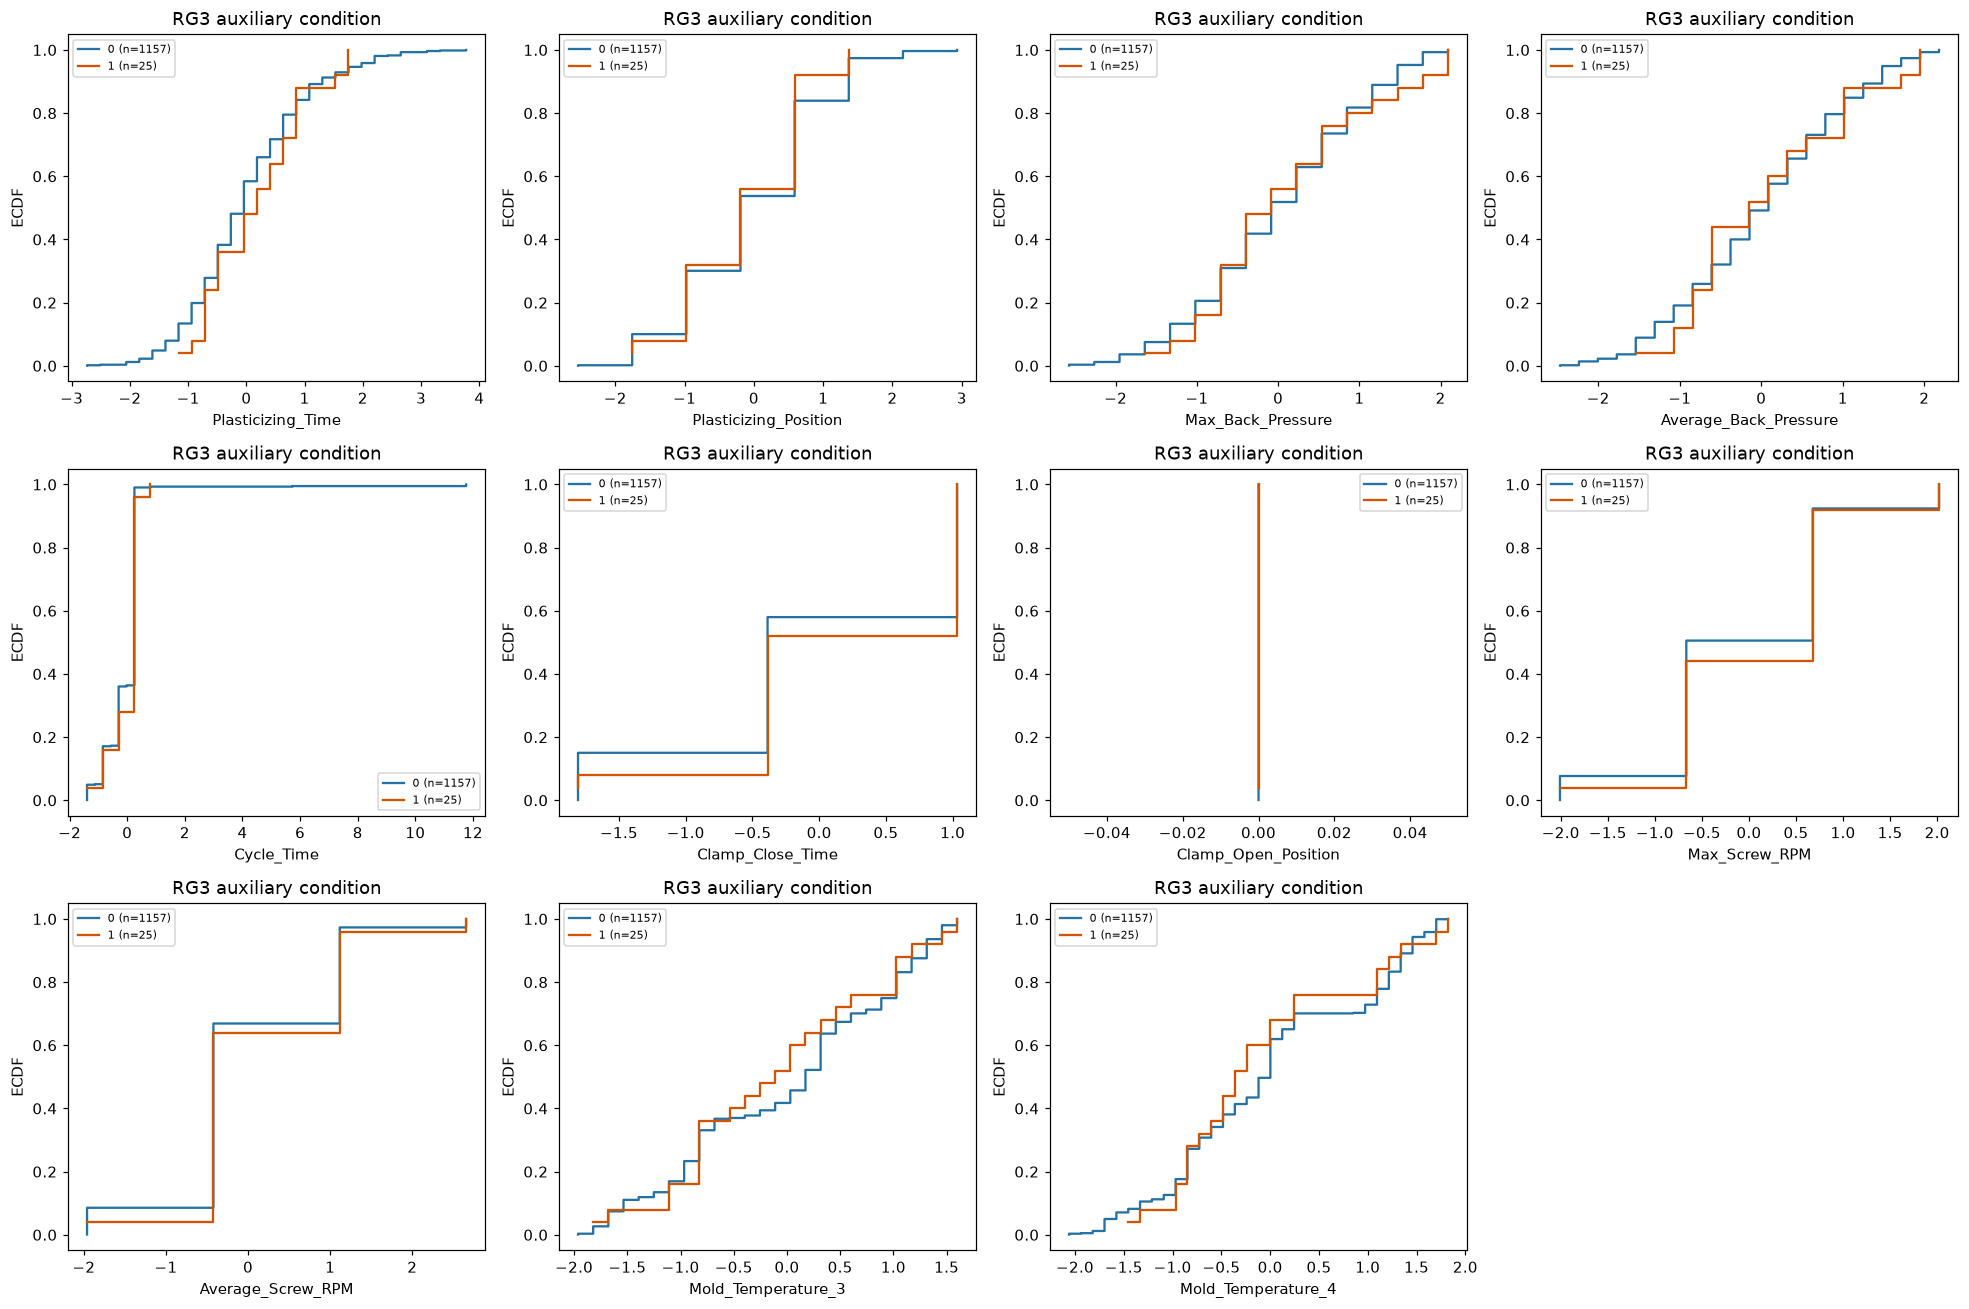

RG3, 모호한 금형온도 포함=False: 정상 반경 상대위치의 전체 범위 0.000–0.985. m 변경에 따른 사례별 상대위치 최대 변화 0.171.

정상 점검 반경의 최댓값 이상인 사례(하나 이상의 m): []. 이 경우 비교 가능한 정상 부족의 정황으로 보고하며 차이를 단정하지 않는다.

RG3, 모호한 금형온도 포함=True: 정상 반경 상대위치의 전체 범위 0.000–0.975. m 변경에 따른 사례별 상대위치 최대 변화 0.200.

정상 점검 반경의 최댓값 이상인 사례(하나 이상의 m): []. 이 경우 비교 가능한 정상 부족의 정황으로 보고하며 차이를 단정하지 않는다.

back median contrast           cushion median contrast  \
include ambiguous mold                False     True                    False   
source_id m                                                                     
1347      12                      -0.232496 -0.232496                0.000000   
          24                      -0.813745 -0.464992                0.000000   
          48                      -0.929993 -0.697497                0.000000   
1371      12                      -0.697497 -0.464996                0.000000   
          24                      -0.697497 -0.232496                0.000000   
          48                      -0.697497 -0.348744                0.797381   
1381      12                       0.581249  0.697497                0.797381   
          24                       0.465001  0.697497                0.797381   
          48                       0.000000  0.697497                1.196072   
1415      12                       0.000000  0.116248                0.797381   
          24                       0.000000  0.232496                0.797381   
          48                       0.000000  0.465001                0.000000   
1455      12                      -0.232505 -0.348753                0.797381   
          24                      -0.465001 -0.348753                0.797381   
          48                      -0.813754 -0.232505                0.797381   
1511      12                      -0.348748 -0.348748                0.000000   
          24                      -0.348748 -0.581249                0.000000   
          48                      -0.930002 -0.465001                0.000000   
1515      12                      -0.348753 -0.465001                0.797381   
          24                      -0.232505  0.000000                0.000000   
          48                      -0.232505  0.116248                0.000000   
1521      12                      -0.116252  0.348744                1.196072   
          24                      -0.348753  0.232496                1.196072   
          48                       0.000000  0.000000                0.797381   
1533      12                       0.929993  0.929993                0.000000   
          24                       0.813745  0.929993                0.000000   
          48                       0.697497  0.813745                0.000000   
1557      12                       0.116248  0.464996                0.797381   
          24                       0.000000  0.348748                0.797381   
          48                       0.000000  0.232496                0.398691   
1618      12                      -0.929993 -0.813745                0.797381   
          24                      -0.813745 -0.929993                0.797381   
          48                      -1.162498 -0.929993                0.797381   
1621      12                      -0.116252 -0.348753               -0.797381   
          24                      -0.116252  0.000000               -0.797381   
          48                      -0.232505 -0.232505               -0.797381   
1674      12                      -0.116252  0.000000               -0.797381   
          24                       0.000000  0.000000               -0.797381   
          48                       0.000000  0.000000               -0.797381   
1761      12                      -0.348753 -0.348753                0.000000   
          24                      -0.232505 -0.232505                0.000000   
          48                      -0.116252 -0.232505                0.000000   
1831      12                      -0.581249 -0.581249                0.000000   
          24                      -0.465001 -0.348748                0.000000   
          48                      -0.465001 -0.465001                0.000000   
1897      12                       0.348748  0.581249               -0.398691   
          24                       0.232496  0.465001 

비교군 크기에 따라 요약이 변하거나 모호한 금형온도 포함 여부로 비교군이 달라질 수 있다. 따라서 하나의 m을 최적으로 채택하지 않고 표 전체를 민감도 결과로 유지했다. 열적 거리의 크기는 표준화된 통계적 유사성일 뿐 물리적 온도 차이가 아니다.

In [14]:
aux=['Plasticizing_Time','Plasticizing_Position','Max_Back_Pressure','Average_Back_Pressure','Cycle_Time','Clamp_Close_Time','Clamp_Open_Position','Max_Screw_RPM','Average_Screw_RPM','Mold_Temperature_3','Mold_Temperature_4']
for p,d in L.items():
    fig,axs=plt.subplots(3,4,figsize=(18,12))
    for ax,c in zip(axs.flat,aux):
        for label in [0,1]:ecdf(ax,d.loc[d.PassOrFail.eq(label),c],str(label),COLORS[label])
        finish(ax,p+' auxiliary condition',c,'ECDF')
    axs.flat[-1].axis('off');plt.tight_layout();plt.show()
    t=conditional_table[conditional_table['product'].eq(p)]
    for mold,g in t.groupby('include ambiguous mold'):
        ranges=g.groupby('source_id')['normal radius percentile'].agg(['min','max'])
        say(f'{p}, 모호한 금형온도 포함={mold}: 정상 반경 상대위치의 전체 범위 {g["normal radius percentile"].min():.3f}–{g["normal radius percentile"].max():.3f}. m 변경에 따른 사례별 상대위치 최대 변화 {(ranges["max"]-ranges["min"]).max():.3f}.')
        lacking=g[g['normal radius percentile'].eq(1)].source_id.unique().tolist()
        say(f'정상 점검 반경의 최댓값 이상인 사례(하나 이상의 m): {lacking}. 이 경우 비교 가능한 정상 부족의 정황으로 보고하며 차이를 단정하지 않는다.')
    core=conditional_table.query('product==@p').pivot_table(index=['source_id','m'],columns='include ambiguous mold',values=['temperature radius','speed median contrast','cushion median contrast','back median contrast'])
    display(core)
say('비교군 크기에 따라 요약이 변하거나 모호한 금형온도 포함 여부로 비교군이 달라질 수 있다. 따라서 하나의 m을 최적으로 채택하지 않고 표 전체를 민감도 결과로 유지했다. 열적 거리의 크기는 표준화된 통계적 유사성일 뿐 물리적 온도 차이가 아니다.')

## 8. EDA 근거 파생변수 생성
**설계:** CN7의 속도·쿠션 동반 패턴을 설명하기 위해 정상 고유 입력의 중간순위 ECDF와 방향성 결합을 생성한다. 중간순위는 동률 양쪽 끝 대신 중간을 배정하는 대칭 처리다. `min(speed_pct, cushion_low_pct)`는 두 조건 중 약한 쪽으로 제한하는 통계적 AND이며 물리량·불량확률이 아니다. 곱과 평균도 민감도 비교한다. 분포 밖 값은 순위 0/1에 압축되므로 원본값을 함께 보존한다.

정상 참조를 고정하고 모든 행에 동일 변환을 적용한다. 포함 최근접 거리를 먼저 제시하고, 전체 입력이 같은 참조를 **라벨과 무관하게** 제외한 거리는 별도의 주변패턴 설명 지표다. 정상 자기 자신만 라벨별로 특별 처리하지 않는다. 같은 원본 입력은 같은 파생변수를 가져야 한다. 전체 정상 참조를 사용한 아래 값은 EDA 전용이다.

In [15]:
def midrank(ref,x):
    a=np.sort(np.asarray(ref));x=np.asarray(x)
    return (np.searchsorted(a,x,side='left')+np.searchsorted(a,x,side='right'))/(2*len(a))
def derive(ref,target):
    out=pd.DataFrame(index=target.index)
    out['speed_pct']=midrank(ref.Max_Injection_Speed,target.Max_Injection_Speed)
    out['cushion_low_pct']=1-midrank(ref.Cushion_Position,target.Cushion_Position)
    out['speed_cushion_min']=out[['speed_pct','cushion_low_pct']].min(axis=1)
    out['speed_cushion_product']=out.speed_pct*out.cushion_low_pct
    out['speed_cushion_mean']=(out.speed_pct+out.cushion_low_pct)/2
    dd=distance_matrix(ref,target,GROUPS['Filling'])
    out['filling_nearest_included']=dd.min(axis=1)
    same=np.ones(dd.shape,dtype=bool)
    for c in FEATURES:same &= target[c].to_numpy()[:,None]==ref[c].to_numpy()[None,:]
    excl=dd.copy();excl[same]=np.inf
    out['filling_nearest_excluded']=excl.min(axis=1)
    cs=['Max_Switch_Over_Pressure','Cushion_Position']
    freq=ref.groupby(cs).size()
    out['switch_cushion_frequency']=[freq.get(tuple(v),0)/len(ref) for v in target[cs].to_numpy()]
    return out
DERIVED={p:derive(NORMAL[p],d) for p,d in L.items()}
feature_specs=pd.DataFrame([
['speed_pct / cushion_low_pct','충전 속도와 쿠션 위치의 정상 대비 방향','정상 고유 입력 중간순위 / 1−중간순위','상대 위치','정상 참조, 동률 중간순위','후속 모델링 검증 후보','원본 크기·꼬리 정보 압축'],
['speed_cushion_min','속도 높음·쿠션 낮음 동반 관찰','min(speed_pct,cushion_low_pct)','통계적 결합','AND 의미; 곱·평균 비교','후속 모델링 검증 후보','서로 다른 입력이 동일 점수로 압축'],
['speed_cushion_product / mean','결합 연산 선택 민감도','곱 / 산술평균','통계적 결합','min과 순위·충돌 비교','설명용','평균은 한쪽 높음으로 상쇄 가능'],
['filling_nearest_included','정확 정상 조합 일치 보완','정상 참조 충전 2변수 최근접 거리','통계적 거리','IQR Euclidean; k=1은 가장 가까운 패턴','설명용','자기/동일 입력 포함 0거리'],
['filling_nearest_excluded','주변의 다른 전체 입력 설명','같은 전체 입력 제외 최근접 거리','통계적 거리','대상 라벨과 무관하게 동일 제외','보류','스케일·참조 희소성 영향'],
['switch_cushion_frequency','전환과 쿠션 이산 조합 지원','정상 고유 입력 중 조합 빈도','관측 빈도','반올림 없음; 행빈도와 구분','설명용','연속형 희소성은 이상이 아님'],
['conditional thermal contrasts','온도 유사 정상과 비교','후보 m별 중앙값 대비','통계적 비교','열적 반경·동률·m 안정성','보류','비교군 충분성 미확정'],
['physical time ratio / pressure or temperature difference','물리적 공정 관계','원시 시간비·압력차·온도차','물리량','원시값 또는 역변환 계수 필요','현재 생성 불가','서로 별도 표준화된 값으로 계산 불가']
],columns=['후보','관찰·가설','계산','의미','설정 근거','판정','한계'])
feature_specs['이용 가능성']='관련 센서값 수집 후·검사 전 제공 여부 확인 필요'
feature_specs['누수']='정상 참조·스케일·설정은 향후 학습 폴드 내부; 대상 라벨 사용 금지'
display(feature_specs)
for p,d in L.items():
    z=DERIVED[p]
    assert np.isfinite(z.to_numpy()).all()
    check=pd.concat([d[['pattern_id']],z],axis=1).groupby('pattern_id')[z.columns].nunique()
    assert check.le(1).all().all(),'같은 원본 입력의 변환 불일치'
    say(f'**{p}: 원본 피처 {len(FEATURES)}개 / 생성 후보 {len(z.columns)}개; 동일 입력 동일 변환 검증 통과**')
    display(z.agg(['count','nunique','min','max']).T.assign(missing=z.isna().sum(),infinite=np.isinf(z).sum(),constant=z.nunique().le(1)))
ORIGINAL_FEATURES=FEATURES.copy()
AUXILIARY_COLUMNS=['source_id','source_file','product','record_order','PassOrFail','pattern_id']
DERIVED_FEATURES=list(next(iter(DERIVED.values())).columns)
say('source_id, pattern_id, 상충 라벨 및 불량 빈도는 추론용 피처에 포함하지 않는다. 행 순서의 시간 의미가 확인되지 않아 이동평균·직전 차이·변화율은 생성하지 않는다.')


,후보,관찰·가설,계산,의미,설정 근거,판정,한계,이용 가능성,누수
0,speed_pct / cushion_low_pct,충전 속도와 쿠션 위치의 정상 대비 방향,정상 고유 입력 중간순위 / 1−중간순위,상대 위치,"정상 참조, 동률 중간순위",후속 모델링 검증 후보,원본 크기·꼬리 정보 압축,관련 센서값 수집 후·검사 전 제공 여부 확인 필요,정상 참조·스케일·설정은 향후 학습 폴드 내부; 대상 라벨 사용 금지
1,speed_cushion_min,속도 높음·쿠션 낮음 동반 관찰,"min(speed_pct,cushion_low_pct)",통계적 결합,AND 의미; 곱·평균 비교,후속 모델링 검증 후보,서로 다른 입력이 동일 점수로 압축,관련 센서값 수집 후·검사 전 제공 여부 확인 필요,정상 참조·스케일·설정은 향후 학습 폴드 내부; 대상 라벨 사용 금지
2,speed_cushion_product / mean,결합 연산 선택 민감도,곱 / 산술평균,통계적 결합,min과 순위·충돌 비교,설명용,평균은 한쪽 높음으로 상쇄 가능,관련 센서값 수집 후·검사 전 제공 여부 확인 필요,정상 참조·스케일·설정은 향후 학습 폴드 내부; 대상 라벨 사용 금지
3,filling_nearest_included,정확 정상 조합 일치 보완,정상 참조 충전 2변수 최근접 거리,통계적 거리,IQR Euclidean; k=1은 가장 가까운 패턴,설명용,자기/동일 입력 포함 0거리,관련 센서값 수집 후·검사 전 제공 여부 확인 필요,정상 참조·스케일·설정은 향후 학습 폴드 내부; 대상 라벨 사용 금지
4,filling_nearest_excluded,주변의 다른 전체 입력 설명,같은 전체 입력 제외 최근접 거리,통계적 거리,대상 라벨과 무관하게 동일 제외,보류,스케일·참조 희소성 영향,관련 센서값 수집 후·검사 전 제공 여부 확인 필요,정상 참조·스케일·설정은 향후 학습 폴드 내부; 대상 라벨 사용 금지
5,switch_cushion_frequency,전환과 쿠션 이산 조합 지원,정상 고유 입력 중 조합 빈도,관측 빈도,반올림 없음; 행빈도와 구분,설명용,연속형 희소성은 이상이 아님,관련 센서값 수집 후·검사 전 제공 여부 확인 필요,정상 참조·스케일·설정은 향후 학습 폴드 내부; 대상 라벨 사용 금지
6,conditional thermal contrasts,온도 유사 정상과 비교,후보 m별 중앙값 대비,통계적 비교,열적 반경·동률·m 안정성,보류,비교군 충분성 미확정,관련 센서값 수집 후·검사 전 제공 여부 확인 필요,정상 참조·스케일·설정은 향후 학습 폴드 내부; 대상 라벨 사용 금지
7,physical time ratio / pressure or temperature ...,물리적 공정 관계,원시 시간비·압력차·온도차,물리량,원시값 또는 역변환 계수 필요,현재 생성 불가,서로 별도 표준화된 값으로 계산 불가,관련 센서값 수집 후·검사 전 제공 여부 확인 필요,정상 참조·스케일·설정은 향후 학습 폴드 내부; 대상 라벨 사용 금지


**CN7: 원본 피처 24개 / 생성 후보 8개; 동일 입력 동일 변환 검증 통과**

,count,nunique,min,max,missing,infinite,constant
speed_pct,1211.0,18.0,0.002488,1.000000,0,0,False
cushion_low_pct,1211.0,5.0,0.000829,1.000000,0,0,False
speed_cushion_min,1211.0,15.0,0.000829,1.000000,0,0,False
speed_cushion_product,1211.0,32.0,0.000466,1.000000,0,0,False
speed_cushion_mean,1211.0,32.0,0.094942,1.000000,0,0,False
filling_nearest_included,1211.0,4.0,0.000000,3.104866,0,0,False
filling_nearest_excluded,1211.0,10.0,0.000000,4.321032,0,0,False
switch_cushion_frequency,1211.0,24.0,0.000000,0.096186,0,0,False


**RG3: 원본 피처 24개 / 생성 후보 8개; 동일 입력 동일 변환 검증 통과**

,count,nunique,min,max,missing,infinite,constant
speed_pct,1182.0,7.0,0.001692,0.986464,0,0,False
cushion_low_pct,1182.0,7.0,0.000846,0.972927,0,0,False
speed_cushion_min,1182.0,12.0,0.000846,0.972927,0,0,False
speed_cushion_product,1182.0,26.0,0.000203,0.959757,0,0,False
speed_cushion_mean,1182.0,26.0,0.038071,0.979695,0,0,False
filling_nearest_included,1182.0,1.0,0.000000,0.000000,0,0,True
filling_nearest_excluded,1182.0,2.0,0.000000,0.499962,0,0,False
switch_cushion_frequency,1182.0,23.0,0.001692,0.077834,0,0,False


source_id, pattern_id, 상충 라벨 및 불량 빈도는 추론용 피처에 포함하지 않는다. 행 순서의 시간 의미가 확인되지 않아 이동평균·직전 차이·변화율은 생성하지 않는다.

## 9. 파생변수의 탐색적 평가
**방법·설정:** 분포·원본 쌍·상관·압축 충돌·참조 민감도를 함께 확인한다. 상관은 Spearman으로 순서 중복을 본다. 80% 정상 참조 반복은 표본 의존성 점검이며 신뢰구간이나 독립 검증이 아니다. 불량 분리도를 최대화하여 설정을 고르지 않는다.

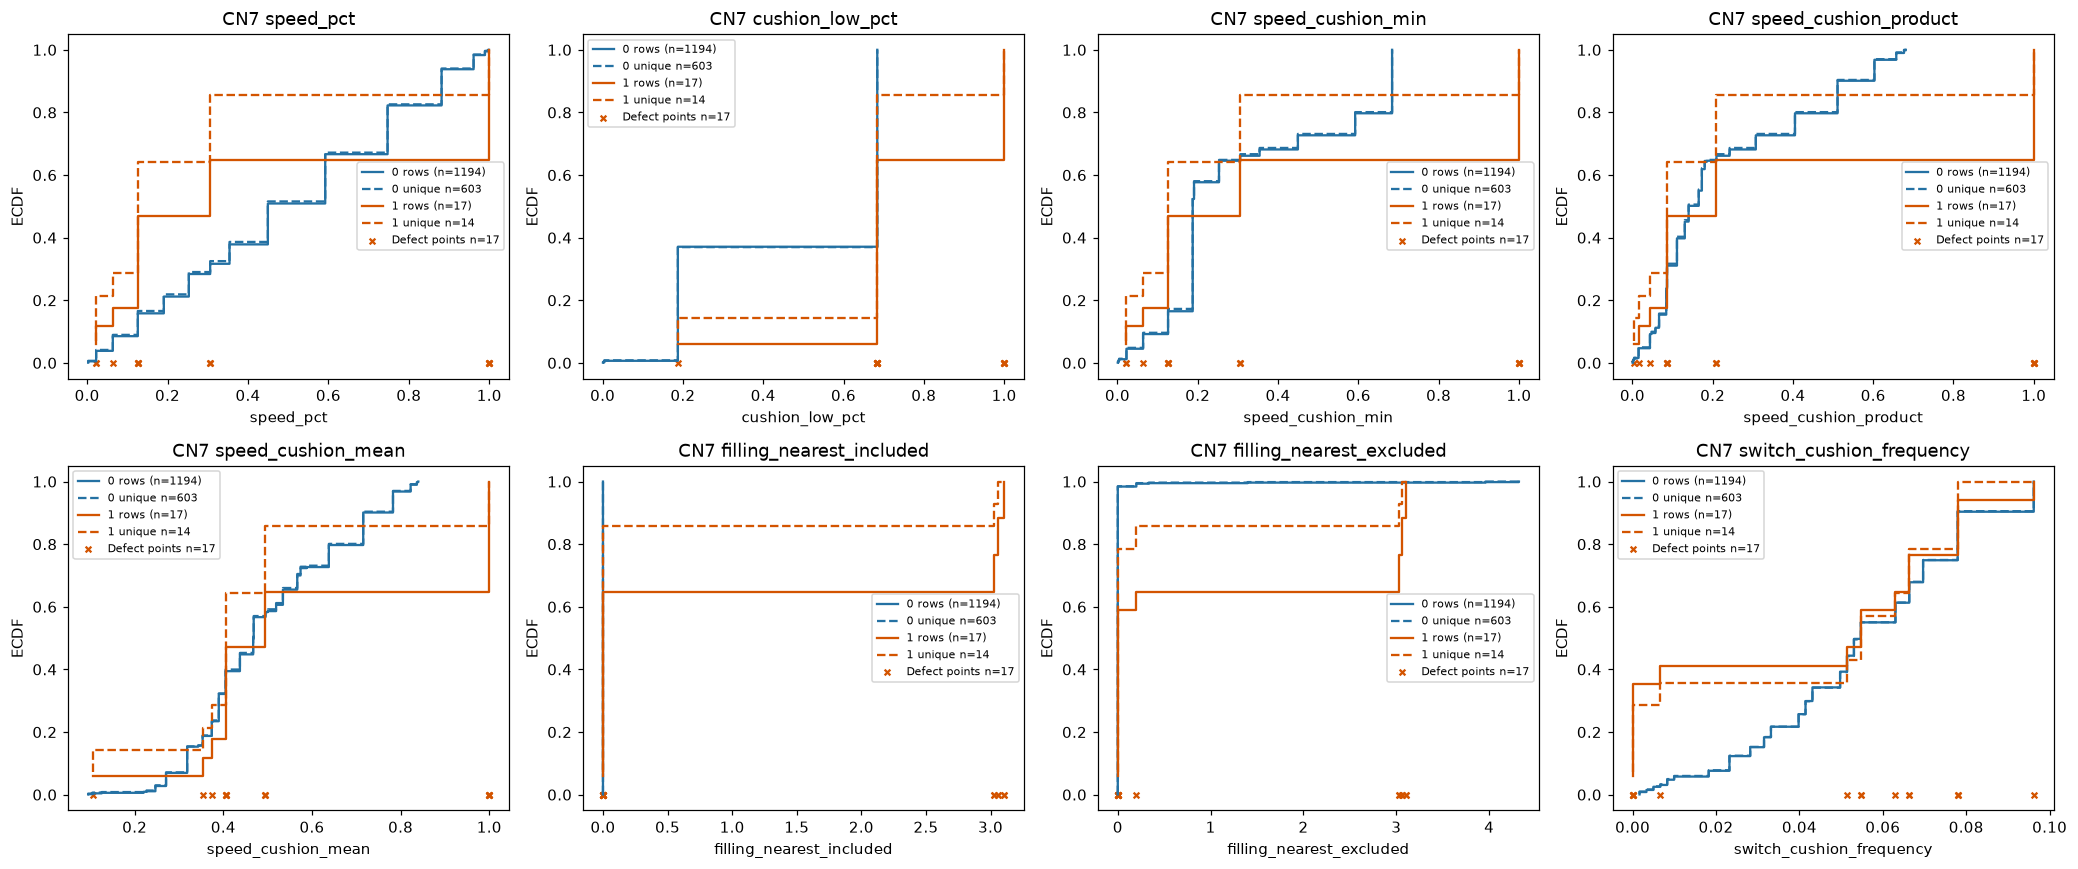

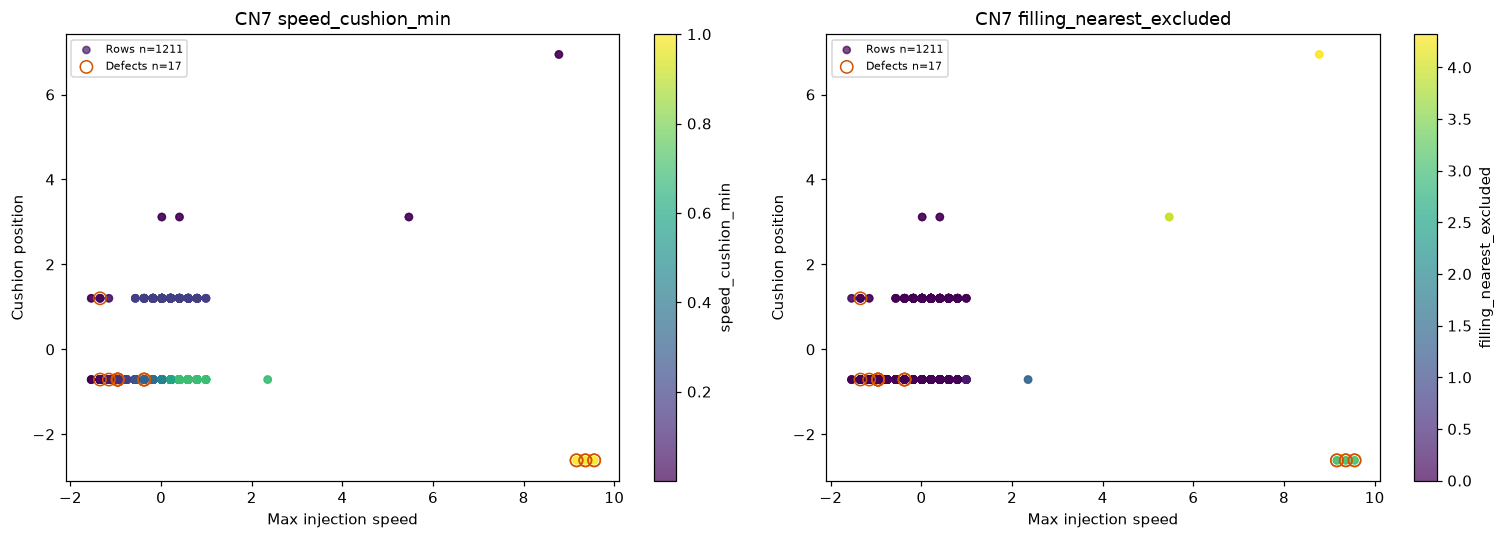

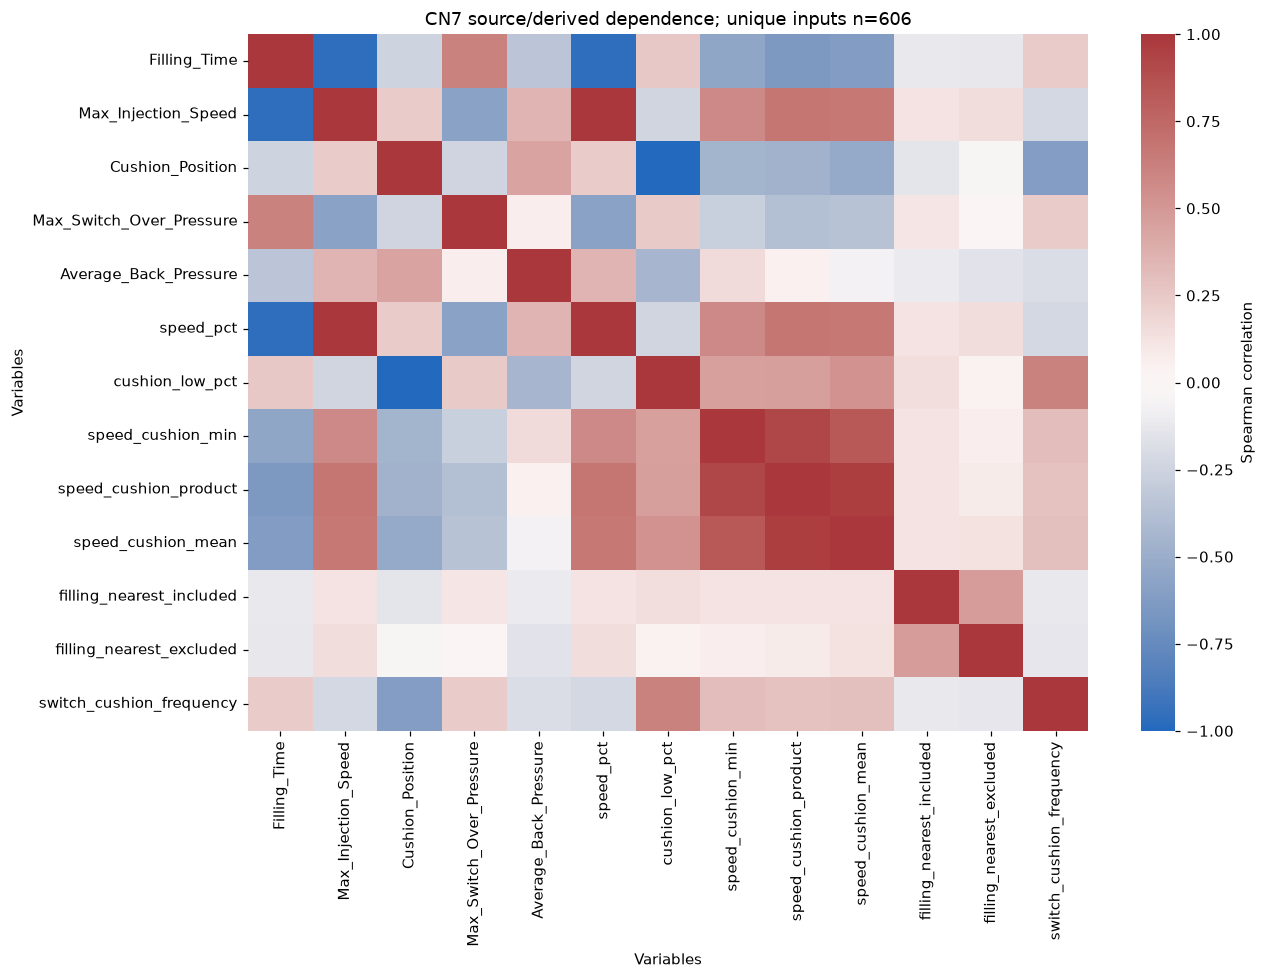

,source_id,pattern_id,Filling_Time,Max_Injection_Speed,Cushion_Position,Max_Switch_Over_Pressure,Average_Back_Pressure,speed_pct,cushion_low_pct,speed_cushion_min,speed_cushion_product,speed_cushion_mean,filling_nearest_included,filling_nearest_excluded,switch_cushion_frequency
47,47,24,1.491397,-1.152398,-0.711164,0.623042,-0.152634,0.063847,0.684080,0.063847,0.043677,0.373964,0.000000,0.000000,0.077944
80,80,40,1.894372,-1.347095,-0.711164,1.256518,-0.533773,0.022388,0.684080,0.022388,0.015315,0.353234,0.000000,0.000000,0.054726
95,95,48,1.894372,-1.347095,1.202502,1.573231,-0.914898,0.022388,0.187396,0.022388,0.004195,0.104892,0.000000,0.000000,0.006633
99,99,50,1.491397,-0.957708,-0.711164,0.623042,-0.533773,0.126036,0.684080,0.126036,0.086219,0.405058,0.000000,0.000000,0.077944
101,101,51,1.491397,-0.957708,-0.711164,-0.010481,-0.533773,0.126036,0.684080,0.126036,0.086219,0.405058,0.000000,0.000000,0.096186
103,103,52,1.088442,-0.957708,-0.711164,0.306281,-0.533773,0.126036,0.684080,0.126036,0.086219,0.405058,0.000000,0.000000,0.066335
105,105,53,1.088442,-0.957708,-0.711164,0.623042,-0.914898,0.126036,0.684080,0.126036,0.086219,0.405058,0.000000,0.000000,0.077944
107,107,54,0.282513,-0.373631,-0.711164,-0.960670,-1.677161,0.305970,0.684080,0.305970,0.209308,0.495025,0.000000,0.000000,0.051410
109,109,55,0.685468,-0.373631,-0.711164,-0.643957,-1.296037,0.305970,0.684080,0.305970,0.209308,0.495025,0.000000,0.000000,0.063018
111,111,56,1.088442,-0.957708,-0.711164,0.306281,-1.296037,0.126036,0.684080,0.126036,0.086219,0.405058,0.000000,0.000000,0.066335


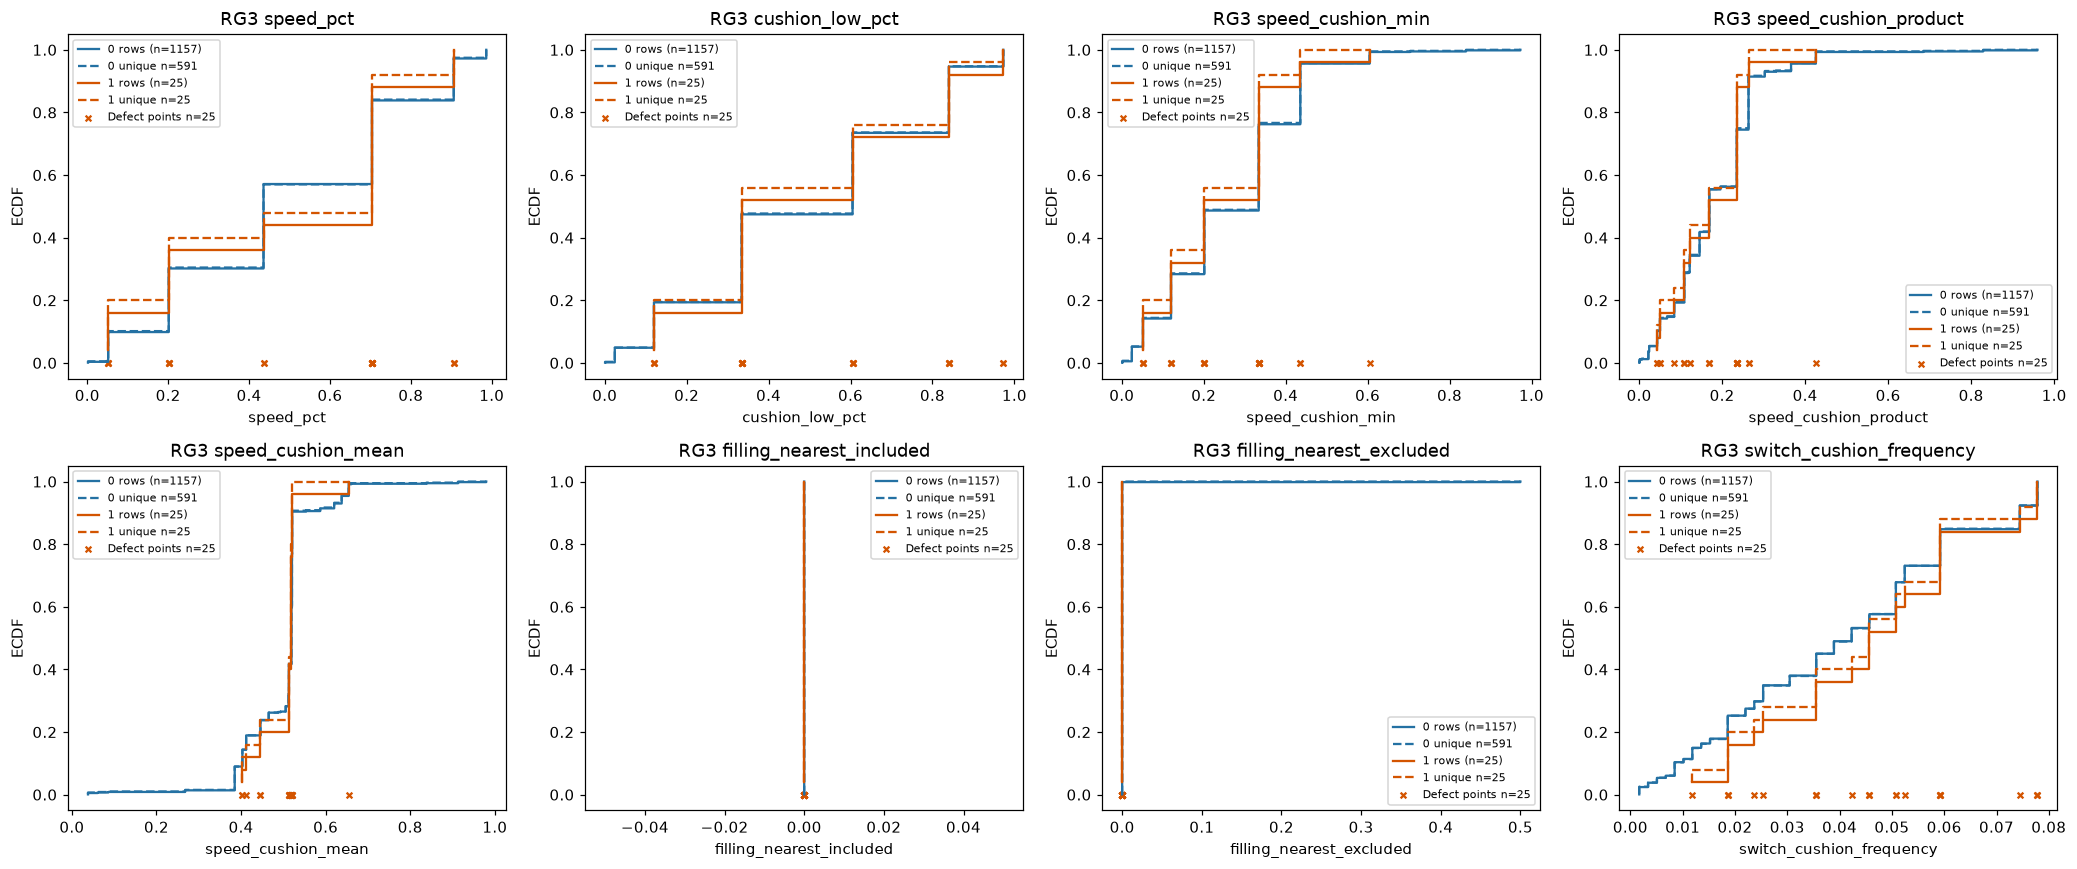

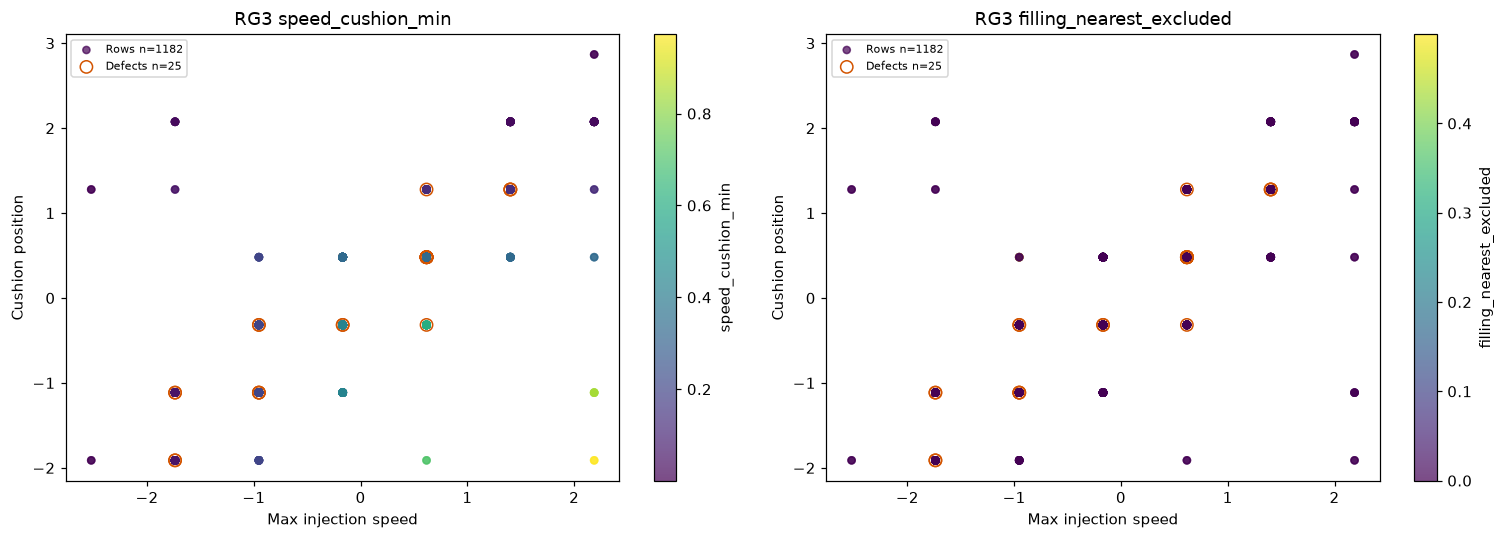

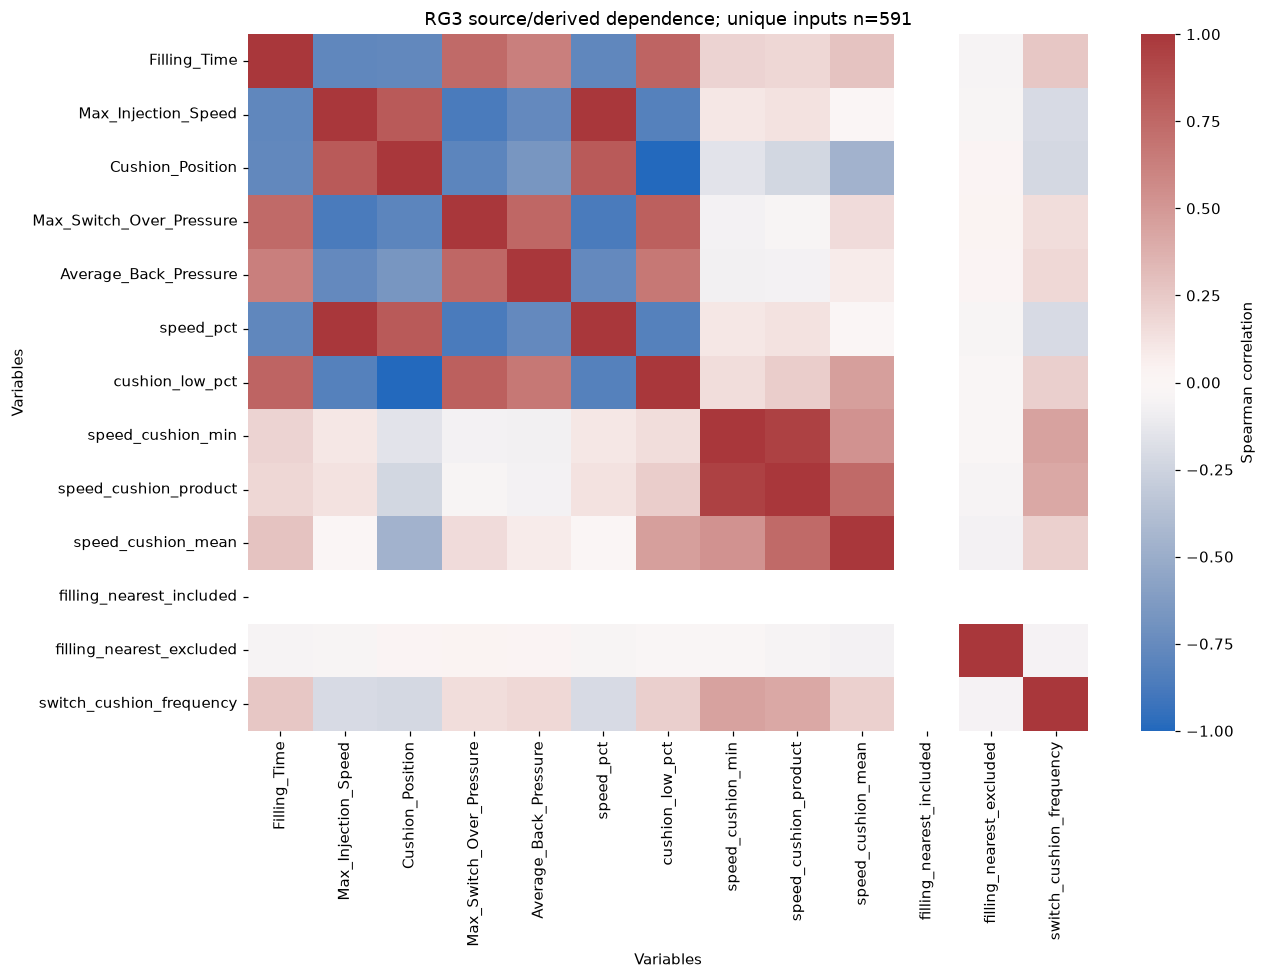

,source_id,pattern_id,Filling_Time,Max_Injection_Speed,Cushion_Position,Max_Switch_Over_Pressure,Average_Back_Pressure,speed_pct,cushion_low_pct,speed_cushion_min,speed_cushion_product,speed_cushion_mean,filling_nearest_included,filling_nearest_excluded,switch_cushion_frequency
136,1347,68,-1.192531,0.617645,0.480326,-0.764686,-1.074373,0.703892,0.334179,0.334179,0.235226,0.519036,0.0,0.0,0.025381
160,1371,80,-1.192531,0.617645,0.480326,0.075729,-1.074373,0.703892,0.334179,0.334179,0.235226,0.519036,0.0,0.0,0.045685
170,1381,85,-1.192531,0.617645,1.277707,-0.554587,0.320621,0.703892,0.120135,0.120135,0.084562,0.412014,0.0,0.0,0.035533
204,1415,102,-1.192531,0.617645,0.480326,-0.344487,0.320621,0.703892,0.334179,0.334179,0.235226,0.519036,0.0,0.0,0.052453
244,1455,122,-1.192531,1.402554,1.277707,-0.974786,-0.609381,0.906091,0.120135,0.120135,0.108854,0.513113,0.0,0.0,0.023689
300,1511,150,0.838552,0.617645,0.480326,-0.134387,-0.841877,0.703892,0.334179,0.334179,0.235226,0.519036,0.0,0.0,0.059222
304,1515,152,0.838552,0.617645,0.480326,0.075729,-0.144380,0.703892,0.334179,0.334179,0.235226,0.519036,0.0,0.0,0.045685
310,1521,155,-1.192531,1.402554,1.277707,-0.554587,-0.609381,0.906091,0.120135,0.120135,0.108854,0.513113,0.0,0.0,0.035533
322,1533,161,0.838552,0.617645,0.480326,-0.134387,1.018118,0.703892,0.334179,0.334179,0.235226,0.519036,0.0,0.0,0.059222
346,1557,173,-1.192531,0.617645,0.480326,-0.554587,-0.144380,0.703892,0.334179,0.334179,0.235226,0.519036,0.0,0.0,0.050761


,product,feature,unique input denominator,distinct scores,scores with collisions,maximum inputs per score
0,CN7,speed_pct,606,18,15,94
1,CN7,cushion_low_pct,606,5,4,381
2,CN7,speed_cushion_min,606,15,14,214
3,CN7,speed_cushion_product,606,32,25,62
4,CN7,speed_cushion_mean,606,32,25,62
5,CN7,filling_nearest_included,606,4,1,603
6,CN7,filling_nearest_excluded,606,10,2,593
7,CN7,switch_cushion_frequency,606,24,24,94
8,RG3,speed_pct,591,7,7,160
9,RG3,cushion_low_pct,591,7,6,167


rank correlation                      \
                                              min    median       max   
product feature                                                         
CN7     cushion_low_pct                  1.000000  1.000000  1.000000   
        filling_nearest_excluded         0.871989  0.962941  1.000000   
        filling_nearest_included         0.614916  0.775880  1.000000   
        speed_cushion_mean               0.997608  0.999979  1.000000   
        speed_cushion_min                0.951890  1.000000  1.000000   
        speed_cushion_product            0.991747  1.000000  1.000000   
        speed_pct                        1.000000  1.000000  1.000000   
        switch_cushion_frequency         0.970552  0.982737  0.996537   
RG3     cushion_low_pct                  1.000000  1.000000  1.000000   
        filling_nearest_excluded         0.574409  1.000000  1.000000   
        filling_nearest_included              NaN       NaN       NaN   
        speed_cushion_mean               0.790144  0.956561  1.000000   
        speed_cushion_min                1.000000  1.000000  1.000000   
        speed_cushion_product            0.999968  1.000000  1.000000   
        speed_pct                        1.000000  1.000000  1.000000   
        switch_cushion_frequency         0.965386  0.986422  0.993806   

                                 mean absolute change                      
                                                  min    median       max  
product feature                                                            
CN7     cushion_low_pct                      0.001145  0.003107  0.007019  
        filling_nearest_excluded             0.000000  0.000738  0.008061  
        filling_nearest_included             0.000000  0.000771  0.007201  
        speed_cushion_mean                   0.001328  0.002720  0.007175  
        speed_cushion_min                    0.002280  0.004062  0.007400  
        speed_cushion_product                0.002044  0.003263  0.006543  
        speed_pct                            0.002191  0.005245  0.015412  
        switch_cushion_frequency             0.002190  0.003525  0.004760  
RG3     cushion_low_pct                      0.002669  0.006037  0.008842  
        filling_nearest_excluded             0.000000  0.000000  0.001692  
        filling_nearest_included             0.000000  0.000000  0.001692  
        speed_cushion_mean                   0.001272  0.002410  0.003272  
        speed_cushion_min                    0.001922  0.005349  0.009243  
        speed_cushion_product                0.001636  0.003435  0.006003  
        speed_pct                            0.001662  0.005026  0.010213  
        switch_cushion_frequency             0.003128  0.003363  0.003595

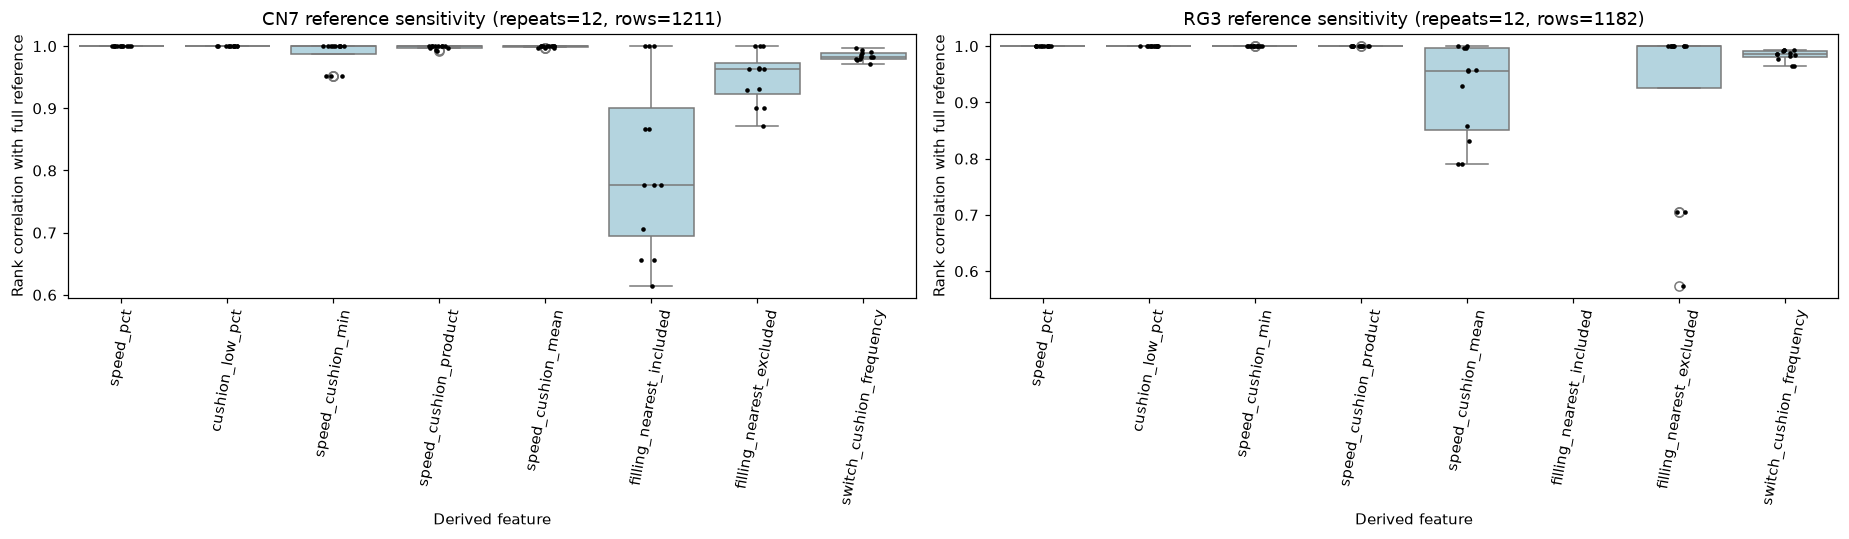

,speed_cushion_min,speed_cushion_product,speed_cushion_mean
speed_cushion_min,1.000000,0.923685,0.828743
speed_cushion_product,0.923685,1.000000,0.963945
speed_cushion_mean,0.828743,0.963945,1.000000


,speed_cushion_min,speed_cushion_product,speed_cushion_mean
speed_cushion_min,1.000000,0.945613,0.527047
speed_cushion_product,0.945613,1.000000,0.741404
speed_cushion_mean,0.527047,0.741404,1.000000


점수의 압축 충돌은 결합 변수가 원본을 대체하지 못함을 보여준다. 최근접 포함 거리는 정상 자기 일치로 0이 많아 상관계수가 정의되지 않을 수 있다. NaN 상관은 유용성 증거가 아니다. 순위 안정성과 실제 원본값을 함께 보고, 특정 불량 몇 행과 중복에 의존하는 차이는 탐색 가설로만 유지한다. 현재 후보 판정은 후속 검증 우선순위이며 성능 향상을 평가하지 않았다.

In [16]:
sensitivity=[];collisions=[]
for p,d in L.items():
    z=DERIVED[p]
    fig,axs=plt.subplots(2,4,figsize=(19,8))
    for ax,c in zip(axs.flat,z.columns):
        for label in [0,1]:
            mask=d.PassOrFail.eq(label);ecdf(ax,z.loc[mask,c],f'{label} rows',COLORS[label])
            unique_mask=mask&~d.duplicated(FEATURES+['PassOrFail'])
            vals=np.sort(z.loc[unique_mask,c]);ax.step(vals,np.arange(1,len(vals)+1)/len(vals),ls='--',color=COLORS[label],label=f'{label} unique n={len(vals)}')
        vals=z.loc[d.PassOrFail.eq(1),c];ax.scatter(vals,np.zeros(len(vals)),marker='x',s=14,color=COLORS[1],label=f'Defect points n={len(vals)}')
        finish(ax,p+' '+c,c,'ECDF')
    plt.tight_layout();plt.show()
    fig,axs=plt.subplots(1,2,figsize=(14,5))
    for ax,c in zip(axs,['speed_cushion_min','filling_nearest_excluded']):
        sc=ax.scatter(d.Max_Injection_Speed,d.Cushion_Position,c=z[c],cmap='viridis',s=22,alpha=.7,label=f'Rows n={len(d)}')
        bad=d.PassOrFail.eq(1);ax.scatter(d.loc[bad,'Max_Injection_Speed'],d.loc[bad,'Cushion_Position'],facecolors='none',edgecolors=COLORS[1],s=65,label=f'Defects n={bad.sum()}')
        fig.colorbar(sc,ax=ax,label=c);finish(ax,p+' '+c,'Max injection speed','Cushion position')
    plt.tight_layout();plt.show()
    source=['Filling_Time','Max_Injection_Speed','Cushion_Position','Max_Switch_Over_Pressure','Average_Back_Pressure']
    combined=pd.concat([d[source],z],axis=1);uniq=~d.duplicated(FEATURES)
    fig,ax=plt.subplots(figsize=(12,9));sns.heatmap(combined.loc[uniq].corr(method='spearman'),vmin=-1,vmax=1,cmap='vlag',ax=ax,cbar_kws={'label':'Spearman correlation'})
    ax.set(title=f'{p} source/derived dependence; unique inputs n={uniq.sum()}',xlabel='Variables',ylabel='Variables');plt.tight_layout();plt.show()
    for c in z:
        pairs=pd.concat([d[['pattern_id']],z[[c]]],axis=1).drop_duplicates('pattern_id').groupby(c).pattern_id.nunique()
        collisions.append([p,c,int(uniq.sum()),len(pairs),int((pairs>1).sum()),int(pairs.max())])
    for rep in range(REPEATS):
        ref=NORMAL[p].sample(frac=.8,random_state=SEED+rep);alt=derive(ref,d)
        for c in z:
            sensitivity.append([p,rep,c,safe_corr(z[c],alt[c]),np.mean(np.abs(z[c]-alt[c]))])
    bad=d.PassOrFail.eq(1)
    display(pd.concat([d.loc[bad,['source_id','pattern_id']+source],z.loc[bad]],axis=1))
collision_table=pd.DataFrame(collisions,columns=['product','feature','unique input denominator','distinct scores','scores with collisions','maximum inputs per score']);display(collision_table)
sensitivity_table=pd.DataFrame(sensitivity,columns=['product','repeat','feature','rank correlation','mean absolute change']);display(sensitivity_table.groupby(['product','feature']).agg({'rank correlation':['min','median','max'],'mean absolute change':['min','median','max']}))
fig,axs=plt.subplots(1,2,figsize=(17,5))
for ax,p in zip(axs,L):
    t=sensitivity_table[sensitivity_table['product'].eq(p)]
    sns.boxplot(data=t,x='feature',y='rank correlation',ax=ax,color='lightblue');sns.stripplot(data=t,x='feature',y='rank correlation',ax=ax,color='black',size=3)
    ax.tick_params(axis='x',rotation=80);ax.set(title=f'{p} reference sensitivity (repeats={REPEATS}, rows={len(L[p])})',xlabel='Derived feature',ylabel='Rank correlation with full reference')
plt.tight_layout();plt.show()
for p,z in DERIVED.items():
    display(z[['speed_cushion_min','speed_cushion_product','speed_cushion_mean']].corr(method='spearman'))
say('점수의 압축 충돌은 결합 변수가 원본을 대체하지 못함을 보여준다. 최근접 포함 거리는 정상 자기 일치로 0이 많아 상관계수가 정의되지 않을 수 있다. NaN 상관은 유용성 증거가 아니다. 순위 안정성과 실제 원본값을 함께 보고, 특정 불량 몇 행과 중복에 의존하는 차이는 탐색 가설로만 유지한다. 현재 후보 판정은 후속 검증 우선순위이며 성능 향상을 평가하지 않았다.')


### 실제 결과에 따른 설정 판단과 파생변수 프로파일
**질문 → 방법:** 정상 참조 실험의 수치를 요약하고, 불량 몇 패턴에 의존하는지 고유 불량과 반복 행을 구분한다. 거리에서는 포함 결과를 먼저, 동일 전체입력 제외 결과를 다음으로 보인다. k 변화는 IQR 유클리드 거리에서 동일 대상을 비교하며 선택은 하지 않는다.

CN7 Filling: 정상 점검 순위 안정성 중앙값의 후보 범위 0.822–1.000; 6회와12회 요약 최대차 0.105. 안정성만으로 최적 이웃 수를 정하지 않는다.

CN7 Injection shared: 정상 점검 순위 안정성 중앙값의 후보 범위 0.722–1.000; 6회와12회 요약 최대차 0.077. 안정성만으로 최적 이웃 수를 정하지 않는다.

CN7 불량 행: n=17, 충전 최근접 포함거리 0인 수=11, 전체입력 일치 제외 후 0인 수=10. 다른 전체입력이 같은 충전 조합을 가질 수 있어 제외 후에도 0이 가능하다.

CN7 고유 불량 패턴: n=14, 충전 최근접 포함거리 0인 수=11, 전체입력 일치 제외 후 0인 수=10. 다른 전체입력이 같은 충전 조합을 가질 수 있어 제외 후에도 0이 가능하다.

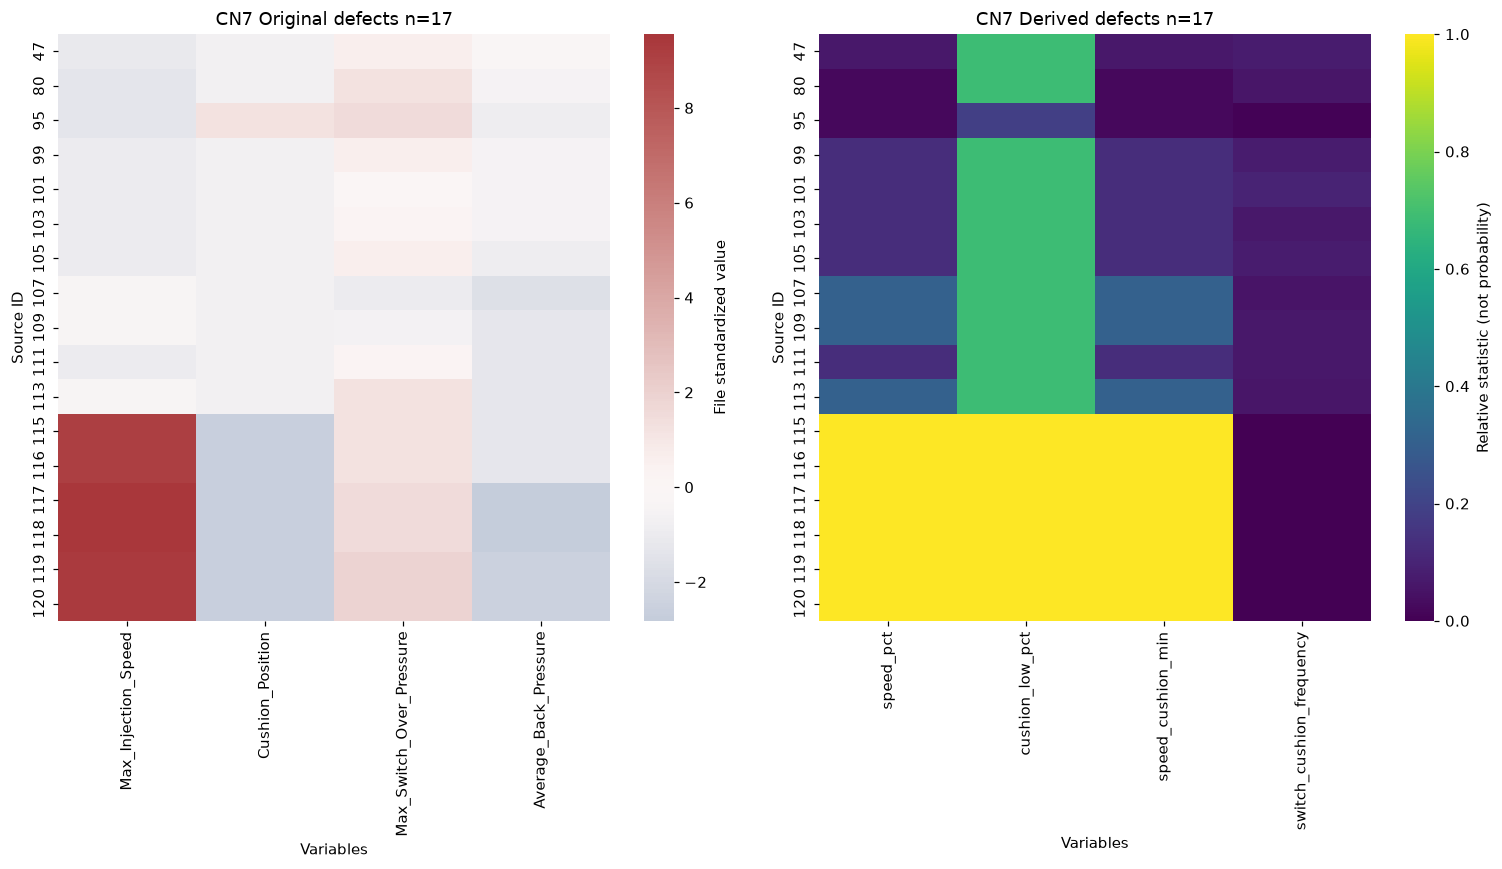

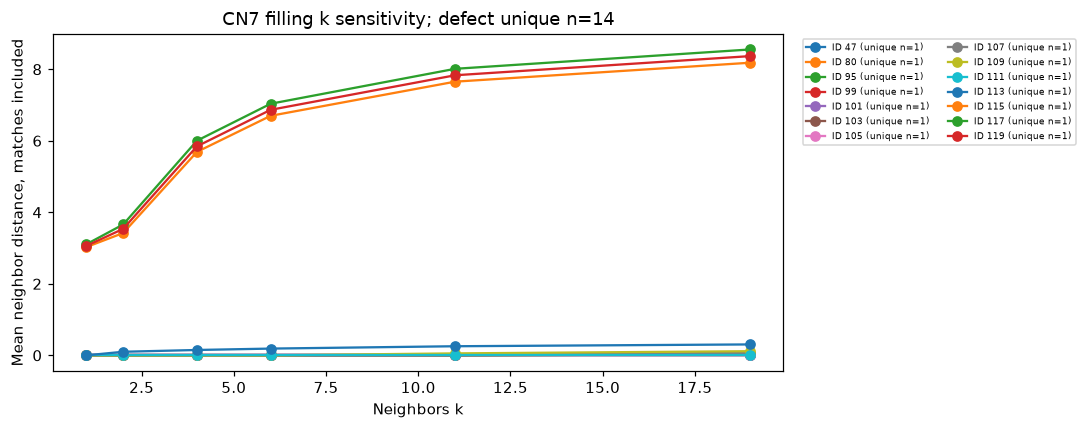

CN7, 라벨 0: 재현용 3IQR 표시 14/1194행. 계수 후보에서 표시 행 수 범위 10–200. 극단값 표시는 라벨과 동의어가 아니다.

CN7, 라벨 1: 재현용 3IQR 표시 6/17행. 계수 후보에서 표시 행 수 범위 6–10. 극단값 표시는 라벨과 동의어가 아니다.

RG3 Filling: 정상 점검 순위 안정성 중앙값의 후보 범위 1.000–1.000; 6회와12회 요약 최대차 0.000. 안정성만으로 최적 이웃 수를 정하지 않는다.

RG3 Injection shared: 정상 점검 순위 안정성 중앙값의 후보 범위 0.712–1.000; 6회와12회 요약 최대차 0.288. 안정성만으로 최적 이웃 수를 정하지 않는다.

RG3 불량 행: n=25, 충전 최근접 포함거리 0인 수=25, 전체입력 일치 제외 후 0인 수=25. 다른 전체입력이 같은 충전 조합을 가질 수 있어 제외 후에도 0이 가능하다.

RG3 고유 불량 패턴: n=25, 충전 최근접 포함거리 0인 수=25, 전체입력 일치 제외 후 0인 수=25. 다른 전체입력이 같은 충전 조합을 가질 수 있어 제외 후에도 0이 가능하다.

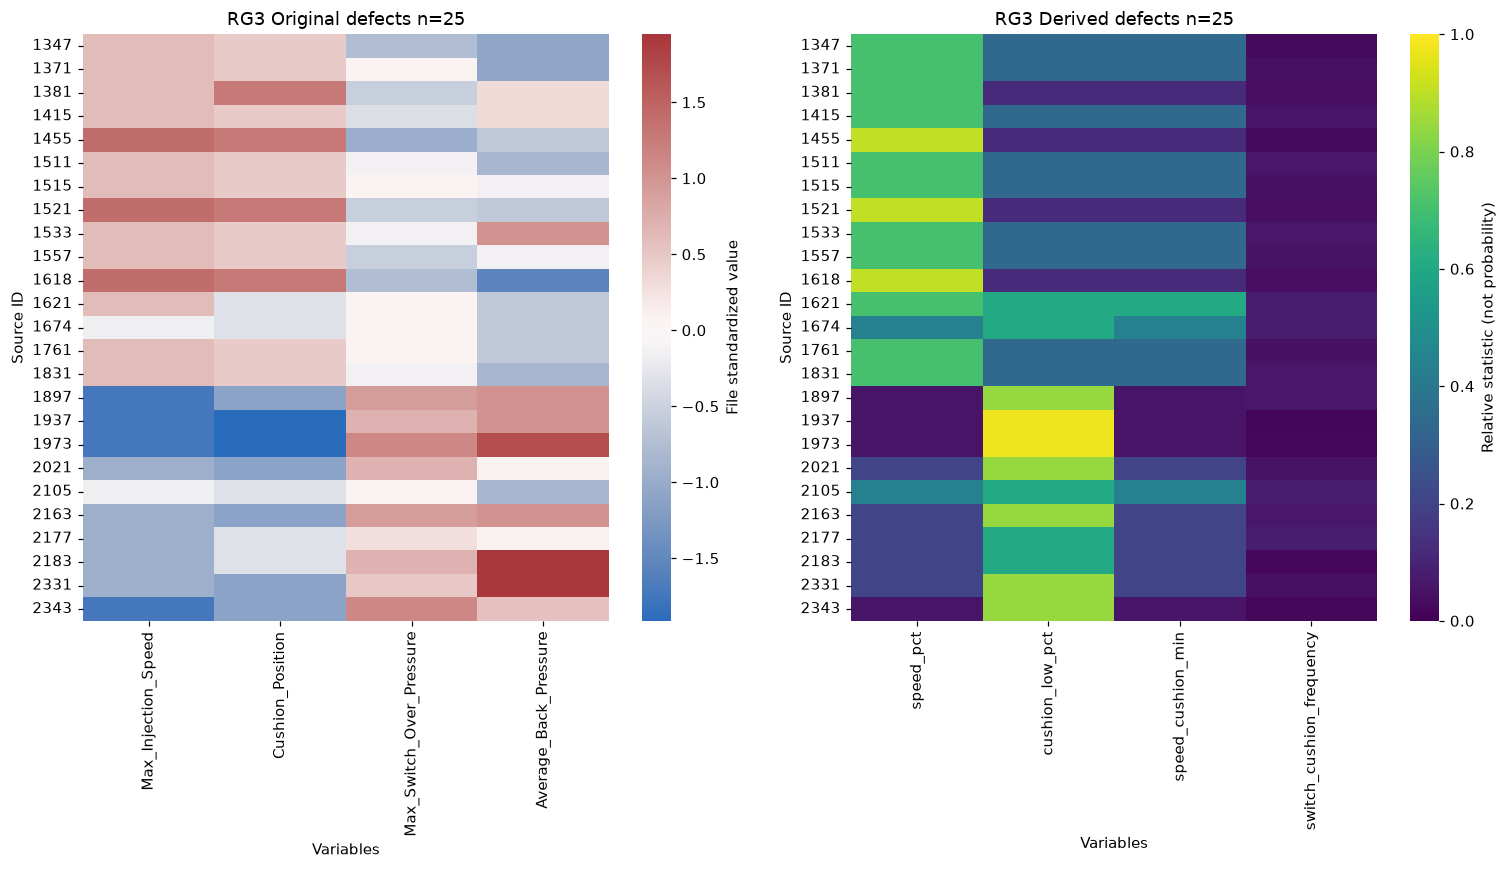

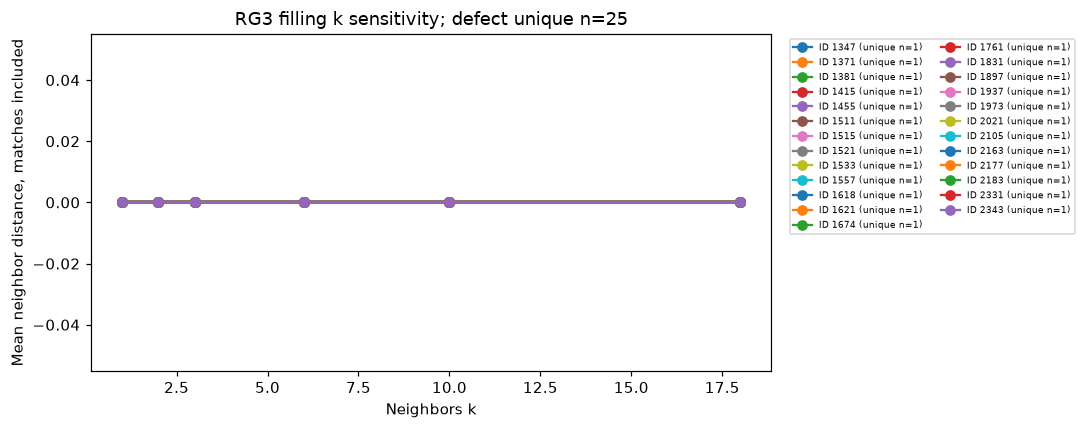

RG3, 라벨 0: 재현용 3IQR 표시 12/1157행. 계수 후보에서 표시 행 수 범위 12–262. 극단값 표시는 라벨과 동의어가 아니다.

RG3, 라벨 1: 재현용 3IQR 표시 0/25행. 계수 후보에서 표시 행 수 범위 0–2. 극단값 표시는 라벨과 동의어가 아니다.

파생 순위·결합은 원본에서 함께 관찰한 방향을 한 축으로 설명하지만 동일 점수로 압축되는 다른 패턴이 존재한다. RG3의 상충 입력 문제는 그대로 남는다. 참조 민감도 결과는 후보를 검증할 우선순위에 활용하되 이번 데이터에서 분리돼 보이는 정도를 독립 검증이라고 부르지 않는다.

In [17]:
for p,d in L.items():
    t=stability_table[stability_table['product'].eq(p)]
    for group,g in t.groupby('group'):
        say(f'{p} {group}: 정상 점검 순위 안정성 중앙값의 후보 범위 {g["rank stability 12"].min():.3f}–{g["rank stability 12"].max():.3f}; 6회와12회 요약 최대차 {(g["rank stability 12"]-g["rank stability 6"]).abs().max():.3f}. 안정성만으로 최적 이웃 수를 정하지 않는다.')
    z=DERIVED[p];mask=d.PassOrFail.eq(1)
    for name,idx in [('불량 행',mask),('고유 불량 패턴',mask&~d.duplicated(FEATURES+['PassOrFail']))]:
        say(f'{p} {name}: n={idx.sum()}, 충전 최근접 포함거리 0인 수={(z.loc[idx,"filling_nearest_included"]==0).sum()}, 전체입력 일치 제외 후 0인 수={(z.loc[idx,"filling_nearest_excluded"]==0).sum()}. 다른 전체입력이 같은 충전 조합을 가질 수 있어 제외 후에도 0이 가능하다.')
    profile_cols=['Max_Injection_Speed','Cushion_Position','Max_Switch_Over_Pressure','Average_Back_Pressure']
    # 서로 다른 척도를 한 색상 축에 혼합하지 않고 두 패널로 분리한다.
    fig,axs=plt.subplots(1,2,figsize=(14,8))
    sns.heatmap(d.loc[mask].set_index('source_id')[profile_cols],ax=axs[0],cmap='vlag',center=0,cbar_kws={'label':'File standardized value'})
    zz=z.loc[mask,['speed_pct','cushion_low_pct','speed_cushion_min','switch_cushion_frequency']].copy();zz.index=d.loc[mask,'source_id']
    sns.heatmap(zz,ax=axs[1],cmap='viridis',vmin=0,vmax=1,cbar_kws={'label':'Relative statistic (not probability)'})
    for ax,title in zip(axs,['Original','Derived']):ax.set(title=f'{p} {title} defects n={mask.sum()}',xlabel='Variables',ylabel='Source ID')
    plt.tight_layout();plt.show()
    ks=distance_runs[p,'Filling','iqr_euclidean'][0];ds=np.sort(distance_matrix(NORMAL[p],BAD[p],GROUPS['Filling']),axis=1)
    fig,ax=plt.subplots(figsize=(10,4))
    for j,(_,b) in enumerate(BAD[p].iterrows()):ax.plot(ks,[ds[j,:k].mean() for k in ks],marker='o',label=f'ID {b.source_id} (unique n=1)')
    finish(ax,f'{p} filling k sensitivity; defect unique n={len(BAD[p])}','Neighbors k','Mean neighbor distance, matches included')
    ax.legend(fontsize=6,ncol=2,loc='upper left',bbox_to_anchor=(1.02,1))
    plt.tight_layout();plt.show()
    # 3IQR 규칙의 실제 데이터 결과와 설정 변화 폭을 해설한다.
    for label in [0,1]:
        e=extreme_table.query('product==@p and label==@label');old=e[e['IQR coefficient'].eq(3)].iloc[0]
        say(f'{p}, 라벨 {label}: 재현용 3IQR 표시 {old["flagged rows"]}/{old["row denominator"]}행. 계수 후보에서 표시 행 수 범위 {e["flagged rows"].min()}–{e["flagged rows"].max()}. 극단값 표시는 라벨과 동의어가 아니다.')
say('파생 순위·결합은 원본에서 함께 관찰한 방향을 한 축으로 설명하지만 동일 점수로 압축되는 다른 패턴이 존재한다. RG3의 상충 입력 문제는 그대로 남는다. 참조 민감도 결과는 후보를 검증할 우선순위에 활용하되 이번 데이터에서 분리돼 보이는 정도를 독립 검증이라고 부르지 않는다.')

## 10. RG3 상충 생성 경위와 최종 해석
**증거 구분:**

- CSV 사실: 아래 재계산된 상충 비율·정확 일치·건수를 사용한다.
- 문서 처리: 43쪽에 CN7/RG3 LH·RH 제품명이 있고, 62쪽 코드는 LH/RH 제품코드를 통합한 뒤 PART_NO와 식별 컬럼을 제거한다. 69쪽은 파일별 표준화를 수행한다.
- 가설: 좌우 구분 제거 후 같은 공정 입력에 서로 다른 검사가 남았을 수 있다.
- 미확정: 각 행의 LH/RH, 실제 생산 사이클 대응, 중복이 생긴 시점은 현재 CSV로 복원할 수 없다. 원본 PART_NO, 시간, 설비, 시리얼, 좌우 제품별 검사 매핑이 필요하다.

43쪽 예시는 CN7 RH 3371/LH 3365, RG3 RH/LH 각 628이며 최종 분석 파일과 처리 단계가 다르다. 69쪽 예시 CN7 정상1398/불량27은 현재 CSV와 다르고 RG3 정상1157/불량25는 일치한다. 예시와 현재 버전이 같다고 전제하지 않는다.

In [18]:
summary=[]
for p,d in L.items():
    b=d[d.PassOrFail.eq(1)];shared=b.pattern_id.isin(NORMAL[p].pattern_id)
    summary.append([p,len(d),len(NORMAL[p]),len(BAD[p]),len(b),int(shared.sum()),shared.mean(),int((PAT[p]['type']=='conflicting').sum())])
display(pd.DataFrame(summary,columns=['product','total rows','normal unique','bad unique','bad rows','bad rows exact normal match','matched fraction / bad rows','conflicting patterns']))
for p in L:
    z=DERIVED[p];d=L[p]
    pid=PAT[p].index[PAT[p]['type'].eq('conflicting')][0]
    display(pd.concat([d.loc[d.pattern_id.eq(pid),['source_id','PassOrFail','pattern_id']],z.loc[d.pattern_id.eq(pid)]],axis=1))
cn=L['CN7'];pure=cn[cn.PassOrFail.eq(1)&~cn.pattern_id.isin(NORMAL['CN7'].pattern_id)]
say(f'**핵심 관찰:** CN7에서 동일 정상 전체 입력이 없는 불량 ID는 {pure.source_id.tolist()}이다. 이들의 높은 최대 사출속도·낮은 쿠션 위치가 함께 나타나는지 원본 표와 산점도로 확인했다. 전환압력은 정상에서도 관측되므로 보압 전체의 이상으로 확대 해석하지 않는다. RG3 불량은 모두 정확한 정상 입력 대응을 가지므로 동일 참조·변환을 적용한 파생변수로 해당 정상/불량을 구분할 수 없다.')
display(feature_specs[['후보','판정','설정 근거','한계']])
say('**설정 근거와 제한:** 정확 일치는 임계값 없는 구조 확인이다. IQR 계수는 민감도 실험이고, k·거리·온도 비교군 크기는 정상 참조 안정성과 국소성으로 비교했으며 최적값을 확정하지 않았다. 정상 상대순위와 방향성 결합은 관계 설명을 추가하지만 새 측정정보를 만들지 않는다. 독립 효과·인과·공정 간 이상 전파·예측 성능 향상은 이번 분석으로 입증하지 않았다. 전체 데이터를 활용하여 가설을 선택한 EDA다. 후속 모델링에서는 전체 입력 패턴 단위로 분할하고 참조·스케일·빈도·파생변수 설정을 학습 폴드 내부에서 다시 계산해야 한다. 원시값, 표준화 계수, 단위 정정, 품질검사 이전 센서 이용 시점, 생산·좌우 제품 대응 정보를 추가 확보해야 한다.')

ref=NORMAL['CN7']
say(f'CN7 동일 정상 입력이 없는 6행은 3개 고유 패턴이다. 최대 사출속도 범위는 {pure.Max_Injection_Speed.min():.3f}–{pure.Max_Injection_Speed.max():.3f}, 관측 정상 최댓값은 {ref.Max_Injection_Speed.max():.3f}이다. 쿠션 위치는 {pure.Cushion_Position.unique().tolist()}, 관측 정상 최솟값은 {ref.Cushion_Position.min():.3f}이다. 모두 파일별 표준화 척도이며 물리적 허용범위를 뜻하지 않는다.')
display(direct_table.query("product=='CN7' and source_id in [115,117,119] and group=='Switch'")[['source_id','normal rows matched','normal unique matched']])
say('전환압력과 같은 정상값이 존재해도 충전·쿠션의 전체 조합까지 같다는 뜻은 아니다. CN7 95·103·107·113 등은 전체 정상 일치 여부를 함께 보아야 하며, 눈에 띄는 일부 값만으로 독립적인 결함 입력으로 분류하지 않는다.')


,product,total rows,normal unique,bad unique,bad rows,bad rows exact normal match,matched fraction / bad rows,conflicting patterns
0,CN7,1211,603,14,17,11,0.647059,11
1,RG3,1182,591,25,25,25,1.000000,25


,source_id,PassOrFail,pattern_id,speed_pct,cushion_low_pct,speed_cushion_min,speed_cushion_product,speed_cushion_mean,filling_nearest_included,filling_nearest_excluded,switch_cushion_frequency
47,47,1,24,0.063847,0.68408,0.063847,0.043677,0.373964,0.0,0.0,0.077944
48,48,0,24,0.063847,0.68408,0.063847,0.043677,0.373964,0.0,0.0,0.077944


,source_id,PassOrFail,pattern_id,speed_pct,cushion_low_pct,speed_cushion_min,speed_cushion_product,speed_cushion_mean,filling_nearest_included,filling_nearest_excluded,switch_cushion_frequency
136,1347,1,68,0.703892,0.334179,0.334179,0.235226,0.519036,0.0,0.0,0.025381
137,1348,0,68,0.703892,0.334179,0.334179,0.235226,0.519036,0.0,0.0,0.025381


**핵심 관찰:** CN7에서 동일 정상 전체 입력이 없는 불량 ID는 [115, 116, 117, 118, 119, 120]이다. 이들의 높은 최대 사출속도·낮은 쿠션 위치가 함께 나타나는지 원본 표와 산점도로 확인했다. 전환압력은 정상에서도 관측되므로 보압 전체의 이상으로 확대 해석하지 않는다. RG3 불량은 모두 정확한 정상 입력 대응을 가지므로 동일 참조·변환을 적용한 파생변수로 해당 정상/불량을 구분할 수 없다.

,후보,판정,설정 근거,한계
0,speed_pct / cushion_low_pct,후속 모델링 검증 후보,"정상 참조, 동률 중간순위",원본 크기·꼬리 정보 압축
1,speed_cushion_min,후속 모델링 검증 후보,AND 의미; 곱·평균 비교,서로 다른 입력이 동일 점수로 압축
2,speed_cushion_product / mean,설명용,min과 순위·충돌 비교,평균은 한쪽 높음으로 상쇄 가능
3,filling_nearest_included,설명용,IQR Euclidean; k=1은 가장 가까운 패턴,자기/동일 입력 포함 0거리
4,filling_nearest_excluded,보류,대상 라벨과 무관하게 동일 제외,스케일·참조 희소성 영향
5,switch_cushion_frequency,설명용,반올림 없음; 행빈도와 구분,연속형 희소성은 이상이 아님
6,conditional thermal contrasts,보류,열적 반경·동률·m 안정성,비교군 충분성 미확정
7,physical time ratio / pressure or temperature ...,현재 생성 불가,원시값 또는 역변환 계수 필요,서로 별도 표준화된 값으로 계산 불가


**설정 근거와 제한:** 정확 일치는 임계값 없는 구조 확인이다. IQR 계수는 민감도 실험이고, k·거리·온도 비교군 크기는 정상 참조 안정성과 국소성으로 비교했으며 최적값을 확정하지 않았다. 정상 상대순위와 방향성 결합은 관계 설명을 추가하지만 새 측정정보를 만들지 않는다. 독립 효과·인과·공정 간 이상 전파·예측 성능 향상은 이번 분석으로 입증하지 않았다. 전체 데이터를 활용하여 가설을 선택한 EDA다. 후속 모델링에서는 전체 입력 패턴 단위로 분할하고 참조·스케일·빈도·파생변수 설정을 학습 폴드 내부에서 다시 계산해야 한다. 원시값, 표준화 계수, 단위 정정, 품질검사 이전 센서 이용 시점, 생산·좌우 제품 대응 정보를 추가 확보해야 한다.

CN7 동일 정상 입력이 없는 6행은 3개 고유 패턴이다. 최대 사출속도 범위는 9.166–9.556, 관측 정상 최댓값은 8.777이다. 쿠션 위치는 [-2.6131626139519994], 관측 정상 최솟값은 -0.711이다. 모두 파일별 표준화 척도이며 물리적 허용범위를 뜻하지 않는다.

,source_id,normal rows matched,normal unique matched
90,115,75,39
106,117,41,21
122,119,10,5


전환압력과 같은 정상값이 존재해도 충전·쿠션의 전체 조합까지 같다는 뜻은 아니다. CN7 95·103·107·113 등은 전체 정상 일치 여부를 함께 보아야 하며, 눈에 띄는 일부 값만으로 독립적인 결함 입력으로 분류하지 않는다.

## 11. 실행 검증
아래 검증은 파일 보존, 주요 표·파생값의 완결성과 동일입력 변환 일관성을 확인한다. 예측 성능 검증은 아니다. 생성된 그래프는 노트북 출력에 포함되며 별도 HTML 보고서를 생성하지 않는다.

**실행 방식:** 이 환경은 커널 소켓 통신을 허용하지 않아 일반 Jupyter Restart & Run All 실행은 불가능했다. 대신 새 Python 프로세스의 IPython 실행 환경에서 위에서 아래로 모든 코드 셀을 실행하여 표·PNG 그래프·한국어 출력과 실행 번호를 저장했다. 외부 Jupyter 환경에서의 커널 실행은 별도 확인이 필요하다.

In [19]:
for name,original in raw.items():
    assert len(original)==len(data[name])
    assert np.array_equal(original[FEATURES].to_numpy(),data[name][FEATURES].to_numpy())
assert len(variable_dictionary)==24
assert all(len(DERIVED[p])==len(L[p]) for p in L)
assert len(direct_table)>0 and len(stability_table)>0 and len(sensitivity_table)>0
print('전체 분석 셀 실행 완료: 원본 보존·출력 표·파생값·동일 입력 변환 확인. 모델 학습 없음.')


전체 분석 셀 실행 완료: 원본 보존·출력 표·파생값·동일 입력 변환 확인. 모델 학습 없음.
